# 🌡️ LST 2024 Prediction — Random Forest & SVR
**Target:** LST 2024  
**Metode:** Random Forest Regression · Support Vector Regression  

| # | Model | Fitur |
|---|-------|-------|

| M1 | Lag LST saja | lst_2009..2021 |
| M2 | **Cluster** + Lag LST | kmeans_cluster + lst_2009..2021 |
| M3 | Lag LST + Lag NDVI + Lag NDBI | lst + ndvi + ndbi 2009..2021 |
| M4 | **Cluster** + Lag LST + Lag NDVI + Lag NDBI | kmeans_cluster + lst + ndvi + ndbi 2009..2021 |

---

## 📦 Sel 1 — Install Library

In [ ]:
!pip install geopandas scikit-learn --quiet

## 📂 Sel 2 — Mount Google Drive & Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── SESUAIKAN PATH INI ─────────────────────────────────────────────────────
# File 1: GeoJSON NDVI & NDBI (semua tahun, wide format)
PATH_NDVI_NDBI = '/content/drive/MyDrive/Data Skripsi/NDVI_NDBI_SemuaTahun_Jakarta.geojson'

# File 2: GeoJSON hasil clustering (output dari notebook clustering sebelumnya)
PATH_CLUSTER   = '/content/drive/MyDrive/Data Skripsi/output/cluster_spatial_k4.geojson'

# File 3: CSV hasil clustering yang memuat nilai LST per tahun
PATH_LST_CSV   = '/content/drive/MyDrive/Data Skripsi/output/cluster_results_k4.csv'

# Direktori output
OUTPUT_DIR = '/content/drive/MyDrive/Data Skripsi/output/regression/'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output akan disimpan ke: {OUTPUT_DIR}')

Mounted at /content/drive
Output akan disimpan ke: /content/drive/MyDrive/Data Skripsi/output/regression/


## ⚙️ Sel 3 — Import & Konfigurasi

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import math
import re
from IPython.display import display

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  KONFIGURASI — SESUAIKAN JIKA PERLU
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LAG_YEARS    = [2009, 2012, 2015, 2018, 2021]   # tahun lag (fitur)
TARGET_YEAR  = 2024                              # tahun prediksi

NDVI_PREFIX  = 'ndvi'    # prefix kolom NDVI di GeoJSON
NDBI_PREFIX  = 'ndbi'     # prefix kolom NDBI di GeoJSON (cek screenshot: ndb2009)
LST_PREFIX   = 'lst'     # prefix kolom LST di CSV
LST_TARGET_COL = f'lst_{TARGET_YEAR}_EXCLUDED'  # nama kolom LST 2024 di CSV

CLUSTER_RAW  = 'k-means_cluster'   # nama kolom cluster di GeoJSON (ada tanda -)
CLUSTER_COL  = 'kmeans_cluster'    # nama setelah rename (aman untuk pandas)

TEST_SIZE    = 0.2
CV_FOLDS     = 5
SEED         = 42

# Hyperparameter RF
RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                 random_state=SEED, n_jobs=-1)

# Hyperparameter SVR
SVR_PARAMS = dict(kernel='rbf', C=10, gamma='scale', epsilon=0.1)

print('✅ Konfigurasi selesai')
print(f'   Lag years  : {LAG_YEARS}')
print(f'   Target     : LST {TARGET_YEAR}')
print(f'   Test size  : {TEST_SIZE*100:.0f}%   CV folds : {CV_FOLDS}')

✅ Konfigurasi selesai
   Lag years  : [2009, 2012, 2015, 2018, 2021]
   Target     : LST 2024
   Test size  : 20%   CV folds : 5


## 📥 Sel 4 — Load & Merge Data

In [ ]:
# ── (A) Load NDVI / NDBI GeoJSON ──────────────────────────────────────────
print('Membaca NDVI/NDBI GeoJSON ...')
gdf_ndvi = gpd.read_file(PATH_NDVI_NDBI)
print(f'  Fitur : {len(gdf_ndvi):,}   Kolom : {list(gdf_ndvi.columns)}')

# ── (B) Load Cluster GeoJSON ──────────────────────────────────────────────
print('Membaca cluster GeoJSON ...')
gdf_clust = gpd.read_file(PATH_CLUSTER)
print(f'  Fitur : {len(gdf_clust):,}   Kolom : {list(gdf_clust.columns)}')

# ── (C) Load LST CSV ──────────────────────────────────────────────────────
print('Membaca LST CSV ...')
df_lst = pd.read_csv(PATH_LST_CSV)
print(f'  Baris : {len(df_lst):,}   Kolom : {list(df_lst.columns)}')

Membaca NDVI/NDBI GeoJSON ...
  Fitur : 644   Kolom : ['id', 'ndbi2009', 'ndvi2009', 'first', 'grid_id', 'sensor', 'year', 'ndvi2012', 'ndbi2012', 'ndvi2015', 'ndbi2015', 'ndvi2018', 'ndbi2018', 'ndvi2021', 'ndbi2021', 'ndvi2024', 'ndbi2024', 'geometry']
Membaca cluster GeoJSON ...
  Fitur : 639   Kolom : ['grid_id', 'k-means_cluster', 'dtw_k-means_cluster', 'k-shape_cluster', 'geometry']
Membaca LST CSV ...
  Baris : 639   Kolom : ['grid_id', 'k-means_cluster', 'dtw_k-means_cluster', 'k-shape_cluster', 'lst_2009', 'lst_2012', 'lst_2015', 'lst_2018', 'lst_2021', 'lst_2024_EXCLUDED']


In [ ]:
# ── Standarisasi kolom grid_id ────────────────────────────────────────────
for obj in [gdf_ndvi, gdf_clust, df_lst]:
    obj['grid_id'] = obj['grid_id'].astype(str).str.strip()

# ── Definisi kolom per sumber ─────────────────────────────────────────────
# LST  : lag tahun sebelum target (prefix pakai underscore → lst_2009)
lst_cols = [f'{LST_PREFIX}_{y}' for y in LAG_YEARS]

# NDVI/NDBI : lag + tahun target semuanya tersedia di GeoJSON (tanpa underscore → ndvi2009)
ndvi_ndbi_years = LAG_YEARS + [TARGET_YEAR]                      # [2009,…,2021,2024]
ndvi_cols       = [f'{NDVI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndvi2009 … ndvi2024
ndbi_cols       = [f'{NDBI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndbi2009 … ndbi2024

# ── Ambil kolom yang relevan ──────────────────────────────────────────────
df_ndvi_sel  = gdf_ndvi[['grid_id'] + ndvi_cols + ndbi_cols].copy()

df_clust_sel = gdf_clust[['grid_id', CLUSTER_RAW]].copy()
df_clust_sel.rename(columns={CLUSTER_RAW: CLUSTER_COL}, inplace=True)

df_lst_sel   = df_lst[['grid_id'] + lst_cols + [LST_TARGET_COL]].copy()
df_lst_sel.rename(columns={LST_TARGET_COL: f'lst_{TARGET_YEAR}'}, inplace=True)

# ── Merge tiga sumber ─────────────────────────────────────────────────────
df = (
    df_ndvi_sel
    .merge(df_clust_sel, on='grid_id', how='inner')
    .merge(df_lst_sel,   on='grid_id', how='inner')
)

# ── Konversi numerik ──────────────────────────────────────────────────────
num_cols = ndvi_cols + ndbi_cols + lst_cols + [f'lst_{TARGET_YEAR}', CLUSTER_COL]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna().reset_index(drop=True)

print(f'\n✅ Merge selesai: {len(df):,} grid dengan data lengkap')
print(f'   LST lag years    : {LAG_YEARS}')
print(f'   NDVI/NDBI years  : {ndvi_ndbi_years}')
print(f'\n   Cluster distribution:')
print(df[CLUSTER_COL].value_counts().sort_index().to_string())
display(df.head())


✅ Merge selesai: 639 grid dengan data lengkap
   LST lag years    : [2009, 2012, 2015, 2018, 2021]
   NDVI/NDBI years  : [2009, 2012, 2015, 2018, 2021, 2024]

   Cluster distribution:
kmeans_cluster
1    129
2    140
3    200
4    170


,grid_id,ndvi2009,ndvi2012,ndvi2015,ndvi2018,ndvi2021,ndvi2024,ndbi2009,ndbi2012,ndbi2015,ndbi2018,ndbi2021,ndbi2024,kmeans_cluster,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021,lst_2024
0,93175000687,0.326384,0.175151,0.317791,0.339465,0.193050,0.207869,-0.040687,-0.004095,-0.005963,0.004914,0.063980,0.047478,4,39.375488,39.290195,39.345885,40.901641,41.527852,38.999557
1,93185000687,0.272749,0.127976,0.238079,0.302161,0.189143,0.202374,0.011989,0.035871,0.041063,0.020532,0.092638,0.090976,4,40.118294,39.534608,40.116941,40.834706,41.599216,39.148771
2,93195000687,0.250288,0.124559,0.224486,0.224696,0.193770,0.173134,0.025512,0.028684,0.033562,0.062228,0.062132,0.046912,4,40.704258,39.927500,40.910729,41.017604,41.551875,39.145990
3,93205000687,0.259503,0.090308,0.245857,0.106555,0.197504,0.163805,0.003311,0.030471,0.014075,-0.070522,0.049498,0.027620,4,40.703000,39.483235,41.339307,41.507020,40.809882,38.974471
4,93215000687,0.257733,0.001859,0.240748,0.100309,0.236530,0.191006,-0.007641,0.063464,0.003678,-0.074047,0.047440,0.021013,1,40.246098,38.891000,41.464954,41.627516,39.685529,38.760797


## 🔍 Sel 5 — Eksplorasi Data (EDA)

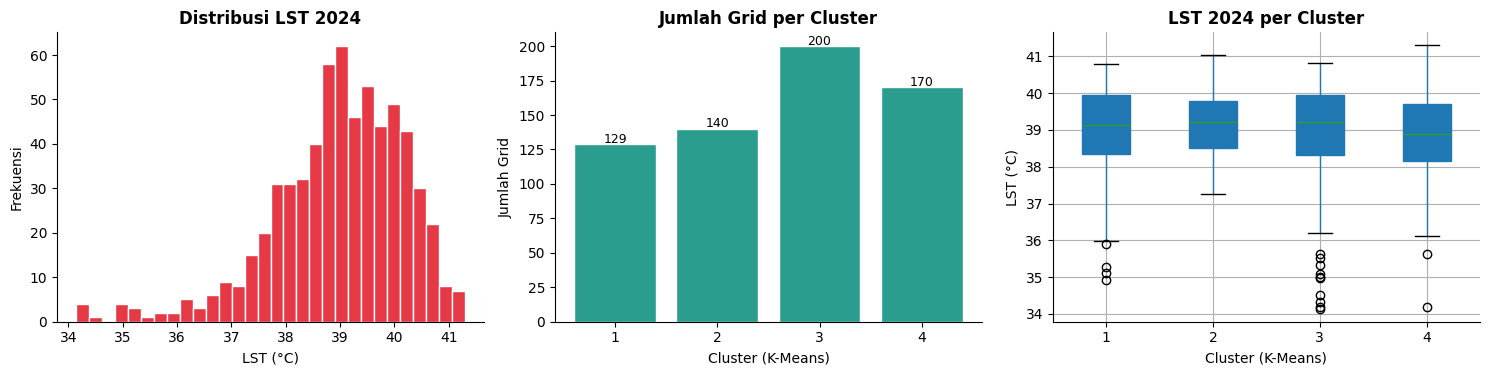


Statistik Deskriptif (target + lag LST):


,lst_2024,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021
count,639.000,639.000,639.000,639.000,639.000,639.000
mean,38.973,39.974,39.720,39.876,40.538,40.248
std,1.223,1.701,1.456,1.322,1.662,1.589
min,34.147,34.030,34.060,33.580,34.483,33.810
25%,38.317,39.143,39.132,39.335,39.611,39.566
50%,39.094,40.260,39.987,39.913,40.609,40.471
75%,39.851,41.218,40.745,40.665,41.424,41.358
max,41.296,43.267,42.207,42.791,45.660,43.357


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi target
axes[0].hist(df[f'lst_{TARGET_YEAR}'], bins=30, color='#E63946', edgecolor='white')
axes[0].set_title(f'Distribusi LST {TARGET_YEAR}', fontweight='bold')
axes[0].set_xlabel('LST (°C)')
axes[0].set_ylabel('Frekuensi')

# Distribusi cluster
vc = df[CLUSTER_COL].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='#2A9D8F', edgecolor='white')
axes[1].set_title('Jumlah Grid per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster (K-Means)')
axes[1].set_ylabel('Jumlah Grid')
for i, v in enumerate(vc.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

# Boxplot LST 2024 per cluster
df.boxplot(column=f'lst_{TARGET_YEAR}', by=CLUSTER_COL, ax=axes[2],
           patch_artist=True)
axes[2].set_title(f'LST {TARGET_YEAR} per Cluster', fontweight='bold')
axes[2].set_xlabel('Cluster (K-Means)')
axes[2].set_ylabel('LST (°C)')
plt.suptitle('')

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStatistik Deskriptif (target + lag LST):')
display(df[[f'lst_{TARGET_YEAR}'] + lst_cols].describe().round(3))

## 🔧 Sel 6 — Definisi Fitur & Fungsi Helper

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  DEFINISI FITUR UNTUK 4 KONFIGURASI MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TARGET_COL = f'lst_{TARGET_YEAR}'

MODEL_CONFIGS = {
    'M1_LagLST': {
        'label'           : 'M1: Lag LST saja',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}',
        'features'        : lst_cols,
        'split_by_cluster': False,
    },
    'M2_LagLST_byCluster': {
        'label'           : 'M2: Lag LST (per Cluster)',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}, model dilatih per cluster',
        'features'        : lst_cols,
        'split_by_cluster': True,
    },
    'M3_LagAll': {
        'label'           : 'M3: Lag LST + NDVI + NDBI',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}',
        'features'        : lst_cols + ndvi_cols + ndbi_cols,
        'split_by_cluster': False,
    },
    'M4_LagAll_byCluster': {
        'label'           : 'M4: Lag LST + NDVI + NDBI (per Cluster)',
        'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}, per cluster',
        'features'        : lst_cols + ndvi_cols + ndbi_cols,
        'split_by_cluster': True,
    },
}

print('✅ Konfigurasi model:')
print(f'   lst_cols  ({len(lst_cols)}): {lst_cols}')
print(f'   ndvi_cols ({len(ndvi_cols)}): {ndvi_cols}')
print(f'   ndbi_cols ({len(ndbi_cols)}): {ndbi_cols}')
print()
for key, cfg in MODEL_CONFIGS.items():
    split_info = f'split per {CLUSTER_COL}' if cfg['split_by_cluster'] else 'semua data'
    print(f'   {cfg["label"]}')
    print(f'      Fitur ({len(cfg["features"])}): {cfg["desc"]}')
    print(f'      Data : {split_info}')

✅ Konfigurasi model:
   lst_cols  (5): ['lst_2009', 'lst_2012', 'lst_2015', 'lst_2018', 'lst_2021']
   ndvi_cols (6): ['ndvi2009', 'ndvi2012', 'ndvi2015', 'ndvi2018', 'ndvi2021', 'ndvi2024']
   ndbi_cols (6): ['ndbi2009', 'ndbi2012', 'ndbi2015', 'ndbi2018', 'ndbi2021', 'ndbi2024']

   M1: Lag LST saja
      Fitur (5): lst 2009–2021
      Data : semua data
   M2: Lag LST (per Cluster)
      Fitur (5): lst 2009–2021, model dilatih per cluster
      Data : split per kmeans_cluster
   M3: Lag LST + NDVI + NDBI
      Fitur (17): lst 2009–2021 + ndvi/ndbi 2009–2024
      Data : semua data
   M4: Lag LST + NDVI + NDBI (per Cluster)
      Fitur (17): lst 2009–2021 + ndvi/ndbi 2009–2024, per cluster
      Data : split per kmeans_cluster


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  FUNGSI HELPER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def adj_r2(r2, n, p):
    """Adjusted R²."""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (skip nol)."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def get_metrics(y_true, y_pred, n_feat, prefix=''):
    n    = len(y_true)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    ar2  = adj_r2(r2, n, n_feat)
    mp   = mape(y_true, y_pred)
    return {
        f'{prefix}R2'     : round(r2,   4),
        f'{prefix}Adj_R2' : round(ar2,  4),
        f'{prefix}RMSE'   : round(rmse, 4),
        f'{prefix}MAE'    : round(mae,  4),
        f'{prefix}MAPE'   : round(mp,   4),
    }

def build_rf():
    return RandomForestRegressor(**RF_PARAMS)

def build_svr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr',    SVR(**SVR_PARAMS))
    ])

def run_single_model(model, X_tr, X_te, y_tr, y_te, feats):
    """Latih satu model, kembalikan dict hasil + artefak."""
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    kf        = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')

    n_feat = len(feats)
    result = {}
    result.update(get_metrics(y_tr, y_pred_tr, n_feat, 'Train_'))
    result.update(get_metrics(y_te, y_pred_te, n_feat, 'Test_'))
    result['CV_R2_Mean']  = round(cv_scores.mean(), 4)
    result['CV_R2_Std']   = round(cv_scores.std(),  4)
    result['y_pred_test'] = y_pred_te
    result['y_pred_train']= y_pred_tr
    result['model_obj']   = model
    result['features']    = feats
    result['X_test']      = X_te
    result['y_test']      = y_te
    result['X_train']     = X_tr
    result['y_train']     = y_tr
    return result

print('✅ Fungsi helper siap.')

✅ Fungsi helper siap.


## 🚀 Sel 7 — Training Semua Model (RF + SVR × 4 Konfigurasi)

In [ ]:
idx_all = np.arange(len(df))
idx_train_global, idx_test_global = train_test_split(
    idx_all, test_size=TEST_SIZE, random_state=SEED
)

all_results  = {}   # key: (config_key, algorithm)
summary_rows = []

clusters = sorted(df[CLUSTER_COL].unique())

for cfg_key, cfg in MODEL_CONFIGS.items():
    feats          = cfg['features']
    split_by_clust = cfg['split_by_cluster']

    # ── Siapkan data sesuai mode ──────────────────────────────────────────
    if not split_by_clust:
        # ── Mode normal: satu model untuk semua grid ──────────────────────
        X = df[feats].values
        y = df[TARGET_COL].values

        X_train = X[idx_train_global]
        X_test  = X[idx_test_global]
        y_train = y[idx_train_global]
        y_test  = y[idx_test_global]

        for algo_name, model in [('RF', build_rf()), ('SVR', build_svr())]:
            print(f'Training {cfg["label"]} — {algo_name} ...', end=' ')
            res = run_single_model(model, X_train, X_test, y_train, y_test, feats)
            all_results[(cfg_key, algo_name)] = res

            print(
                f'✓  Test R²={res["Test_R2"]:.4f}  '
                f'Adj R²={res["Test_Adj_R2"]:.4f}  '
                f'RMSE={res["Test_RMSE"]:.4f}  '
                f'MAPE={res["Test_MAPE"]:.2f}%'
            )
            summary_rows.append({
                'Config'       : cfg['label'],
                'Algorithm'    : algo_name,
                'N_Features'   : len(feats),
                'Split'        : 'Semua Grid',
                'Train_R2'     : res['Train_R2'],
                'Train_Adj_R2' : res['Train_Adj_R2'],
                'Test_R2'      : res['Test_R2'],
                'Test_Adj_R2'  : res['Test_Adj_R2'],
                'Test_RMSE'    : res['Test_RMSE'],
                'Test_MAE'     : res['Test_MAE'],
                'Test_MAPE'    : res['Test_MAPE'],
                'CV_R2_Mean'   : res['CV_R2_Mean'],
                'CV_R2_Std'    : res['CV_R2_Std'],
            })

    else:
        # ── Mode split per cluster: satu model per cluster ─────────────────
        # Prediksi dikumpulkan kembali ke array berukuran len(df)
        # sehingga evaluasi gabungan tetap bisa dihitung.

        y_pred_test_combined  = np.full(len(df), np.nan)
        y_pred_train_combined = np.full(len(df), np.nan)
        cluster_models        = {}   # {cluster_id: {'RF': model, 'SVR': model}}
        cluster_X_test        = {}   # {cluster_id: X_test}
        cluster_y_test        = {}
        cluster_X_train       = {}
        cluster_y_train       = {}

        for algo_name, _ in [('RF', None), ('SVR', None)]:
            print(f'\n--- {cfg["label"]} — {algo_name} (per cluster) ---')
            y_pred_test_combined  = np.full(len(df), np.nan)
            y_pred_train_combined = np.full(len(df), np.nan)

            per_cluster_rows = []

            for cl in clusters:
                idx_cl = df.index[df[CLUSTER_COL] == cl].tolist()

                # Pakai split GLOBAL yang sama untuk setiap konfigurasi,
                # supaya keempat model (M1–M4) dievaluasi pada grid uji yang
                # identik dan prediksinya bisa disandingkan langsung. Yang
                # berbeda hanya: di sini satu model dilatih terpisah per cluster.
                set_train_global = set(np.asarray(idx_train_global).tolist())
                set_test_global  = set(np.asarray(idx_test_global).tolist())
                idx_cl_train = [i for i in idx_cl if i in set_train_global]
                idx_cl_test  = [i for i in idx_cl if i in set_test_global]
                if len(idx_cl_train) == 0 or len(idx_cl_test) == 0:
                    continue

                X_cl = df.loc[idx_cl, feats].values
                y_cl = df.loc[idx_cl, TARGET_COL].values

                X_cl_train = df.loc[idx_cl_train, feats].values
                X_cl_test  = df.loc[idx_cl_test,  feats].values
                y_cl_train = df.loc[idx_cl_train, TARGET_COL].values
                y_cl_test  = df.loc[idx_cl_test,  TARGET_COL].values

                model = build_rf() if algo_name == 'RF' else build_svr()
                model.fit(X_cl_train, y_cl_train)

                y_pred_cl_test  = model.predict(X_cl_test)
                y_pred_cl_train = model.predict(X_cl_train)

                # Isi array gabungan
                y_pred_test_combined[idx_cl_test]   = y_pred_cl_test
                y_pred_train_combined[idx_cl_train]  = y_pred_cl_train

                # Simpan model per cluster
                if cl not in cluster_models:
                    cluster_models[cl] = {}
                cluster_models[cl][algo_name]  = model
                cluster_X_test[cl]  = X_cl_test
                cluster_y_test[cl]  = y_cl_test
                cluster_X_train[cl] = X_cl_train
                cluster_y_train[cl] = y_cl_train

                # Metrik per cluster
                r2_cl   = r2_score(y_cl_test, y_pred_cl_test)
                rmse_cl = np.sqrt(mean_squared_error(y_cl_test, y_pred_cl_test))
                print(f'   Cluster {cl:2.0f}  n={len(idx_cl):4d} '
                      f'(train={len(idx_cl_train)}, test={len(idx_cl_test)})  '
                      f'R²={r2_cl:.4f}  RMSE={rmse_cl:.4f}')

            # ── Evaluasi gabungan (hanya indeks yang punya prediksi) ──────
            valid_mask       = ~np.isnan(y_pred_test_combined)
            y_all            = df[TARGET_COL].values
            y_true_combined  = y_all[valid_mask]
            y_pred_combined  = y_pred_test_combined[valid_mask]

            # indeks test gabungan (union semua cluster_test)
            idx_test_union   = np.where(valid_mask)[0]

            valid_train_mask    = ~np.isnan(y_pred_train_combined)
            y_true_train_comb   = y_all[valid_train_mask]
            y_pred_train_comb   = y_pred_train_combined[valid_train_mask]

            n_feat = len(feats)
            m_test  = get_metrics(y_true_combined,   y_pred_combined,   n_feat, 'Test_')
            m_train = get_metrics(y_true_train_comb, y_pred_train_comb, n_feat, 'Train_')

            # CV gabungan (gabungkan semua data cluster, latih ulang 1 model global
            # sebagai proxy CV — karena split per cluster tidak bisa fold-CV biasa)
            X_all_cl = df[feats].values
            y_all_cl = df[TARGET_COL].values
            model_cv = build_rf() if algo_name == 'RF' else build_svr()
            kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
            cv_scores = cross_val_score(model_cv, X_all_cl, y_all_cl,
                                        cv=kf, scoring='r2')

            print(f'   ➤ Gabungan  Test R²={m_test["Test_R2"]:.4f}  '
                  f'Adj R²={m_test["Test_Adj_R2"]:.4f}  '
                  f'RMSE={m_test["Test_RMSE"]:.4f}  '
                  f'MAPE={m_test["Test_MAPE"]:.2f}%')

            # Simpan ke all_results (pakai cluster 0 sebagai proxy model_obj untuk SHAP/FI)
            # Model per cluster tersedia di cluster_models
            representative_cl = clusters[0]
            all_results[(cfg_key, algo_name)] = {
                **m_train,
                **m_test,
                'CV_R2_Mean'       : round(cv_scores.mean(), 4),
                'CV_R2_Std'        : round(cv_scores.std(),  4),
                'y_pred_test'      : y_pred_combined,
                'y_pred_train'     : y_pred_train_comb,
                'y_test'           : y_true_combined,
                'y_train'          : y_true_train_comb,
                'X_test'           : df.loc[idx_test_union, feats].values,
                'X_train'          : df.loc[~valid_mask == False, feats].values,
                'model_obj'        : cluster_models[representative_cl][algo_name],
                'cluster_models'   : cluster_models,
                'cluster_X_test'   : cluster_X_test,
                'cluster_y_test'   : cluster_y_test,
                'cluster_X_train'  : cluster_X_train,
                'cluster_y_train'  : cluster_y_train,
                'features'         : feats,
                'split_by_cluster' : True,
                'idx_test_union'   : idx_test_union,
            }

            summary_rows.append({
                'Config'       : cfg['label'],
                'Algorithm'    : algo_name,
                'N_Features'   : len(feats),
                'Split'        : 'Per Cluster',
                'Train_R2'     : m_train['Train_R2'],
                'Train_Adj_R2' : m_train['Train_Adj_R2'],
                'Test_R2'      : m_test['Test_R2'],
                'Test_Adj_R2'  : m_test['Test_Adj_R2'],
                'Test_RMSE'    : m_test['Test_RMSE'],
                'Test_MAE'     : m_test['Test_MAE'],
                'Test_MAPE'    : m_test['Test_MAPE'],
                'CV_R2_Mean'   : round(cv_scores.mean(), 4),
                'CV_R2_Std'    : round(cv_scores.std(),  4),
            })

df_summary = pd.DataFrame(summary_rows)
print('\n✅ Semua model selesai dilatih.')

Training M1: Lag LST saja — RF ... ✓  Test R²=0.7392  Adj R²=0.7285  RMSE=0.6217  MAPE=1.28%
Training M1: Lag LST saja — SVR ... ✓  Test R²=0.7566  Adj R²=0.7466  RMSE=0.6006  MAPE=1.20%

--- M2: Lag LST (per Cluster) — RF (per cluster) ---
   Cluster  1  n= 129 (train=103, test=26)  R²=0.8570  RMSE=0.5056
   Cluster  2  n= 140 (train=112, test=28)  R²=0.5900  RMSE=0.5790
   Cluster  3  n= 200 (train=160, test=40)  R²=0.8550  RMSE=0.4977
   Cluster  4  n= 170 (train=136, test=34)  R²=0.7247  RMSE=0.6895
   ➤ Gabungan  Test R²=0.7893  Adj R²=0.7807  RMSE=0.5735  MAPE=1.12%

--- M2: Lag LST (per Cluster) — SVR (per cluster) ---
   Cluster  1  n= 129 (train=103, test=26)  R²=0.8945  RMSE=0.4342
   Cluster  2  n= 140 (train=112, test=28)  R²=0.5794  RMSE=0.5864
   Cluster  3  n= 200 (train=160, test=40)  R²=0.8457  RMSE=0.5134
   Cluster  4  n= 170 (train=136, test=34)  R²=0.6320  RMSE=0.7971
   ➤ Gabungan  Test R²=0.7664  Adj R²=0.7569  RMSE=0.6039  MAPE=1.12%
Training M3: Lag LST + NDVI 

## 📋 Sel 8 — Tabel Hasil Evaluasi

In [ ]:
print(f'\n{"="*75}')
print(f'  HASIL EVALUASI — Prediksi LST {TARGET_YEAR}')
print(f'{"="*75}')

styled = (
    df_summary.style
    .highlight_max(
        subset=['Train_R2','Train_Adj_R2','Test_R2','Test_Adj_R2','CV_R2_Mean'],
        color='#d4edda'
    )
    .highlight_min(
        subset=['Test_RMSE','Test_MAE','Test_MAPE','CV_R2_Std'],
        color='#d4edda'
    )
    .highlight_max(
        subset=['Test_RMSE','Test_MAE','Test_MAPE'],
        color='#f8d7da'
    )
    .format({
        'Train_R2'     : '{:.4f}',
        'Train_Adj_R2' : '{:.4f}',
        'Test_R2'      : '{:.4f}',
        'Test_Adj_R2'  : '{:.4f}',
        'Test_RMSE'    : '{:.4f}',
        'Test_MAE'     : '{:.4f}',
        'Test_MAPE'    : '{:.2f}%',
        'CV_R2_Mean'   : '{:.4f}',
        'CV_R2_Std'    : '{:.4f}',
    })
)
display(styled)

df_summary.to_csv(OUTPUT_DIR + 'summary_evaluation.csv', index=False)
print(f'\n💾 Disimpan: {OUTPUT_DIR}summary_evaluation.csv')

# Tabel per-cluster khusus model byCluster
print('\n📊 Detail metrik per cluster (model split_by_cluster):')
for cfg_key, cfg in MODEL_CONFIGS.items():
    if not cfg['split_by_cluster']:
        continue
    print(f'\n  ── {cfg["label"]} ──')
    for algo_name in ['RF', 'SVR']:
        res = all_results[(cfg_key, algo_name)]
        cl_models = res['cluster_models']
        print(f'  {algo_name}:')
        rows_cl = []
        for cl in clusters:
            X_te = res['cluster_X_test'][cl]
            y_te = res['cluster_y_test'][cl]
            X_tr = res['cluster_X_train'][cl]   # ← diperlukan untuk Adj R² & CV
            y_tr = res['cluster_y_train'][cl]   # ← diperlukan untuk Adj R² & CV
            m    = cl_models[cl][algo_name]
            yp   = m.predict(X_te)

            # Metrik dasar
            r2_   = r2_score(y_te, yp)
            rmse_ = np.sqrt(mean_squared_error(y_te, yp))
            mae_  = mean_absolute_error(y_te, yp)

            # MAPE (hindari div/0)
            mask      = y_te != 0
            mape_     = np.mean(np.abs((y_te[mask] - yp[mask]) / y_te[mask])) * 100 if mask.any() else np.nan

            # Adjusted R²  →  1 - (1-R²)*(n-1)/(n-p-1)
            n_te  = len(y_te)
            p_    = X_te.shape[1]
            adj_r2_ = 1 - (1 - r2_) * (n_te - 1) / (n_te - p_ - 1) if (n_te - p_ - 1) > 0 else np.nan

            # CV R² (cross-validate pada data TRAIN cluster tersebut)
            cv_scores_ = cross_val_score(m, X_tr, y_tr, cv=5, scoring='r2')
            cv_r2_mean_ = cv_scores_.mean()
            cv_r2_std_  = cv_scores_.std()

            rows_cl.append({
                'Cluster'    : int(cl),
                'n_test'     : n_te,
                'R²'         : round(r2_,    4),
                'Adj_R²'     : round(adj_r2_,4) if not np.isnan(adj_r2_) else np.nan,
                'RMSE'       : round(rmse_,  4),
                'MAE'        : round(mae_,   4),
                'MAPE (%)'   : round(mape_,  2) if not np.isnan(mape_) else np.nan,
                'CV_R²_Mean' : round(cv_r2_mean_, 4),
                'CV_R²_Std'  : round(cv_r2_std_,  4),
            })

        df_cl = pd.DataFrame(rows_cl)

        # Styling per-cluster
        styled_cl = (
            df_cl.style
            .highlight_max(subset=['R²', 'Adj_R²', 'CV_R²_Mean'], color='#d4edda')
            .highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)', 'CV_R²_Std'], color='#d4edda')
            .highlight_max(subset=['RMSE', 'MAE', 'MAPE (%)'], color='#f8d7da')
            .format({
                'R²'        : '{:.4f}',
                'Adj_R²'    : '{:.4f}',
                'RMSE'      : '{:.4f}',
                'MAE'       : '{:.4f}',
                'MAPE (%)' : '{:.2f}%',
                'CV_R²_Mean': '{:.4f}',
                'CV_R²_Std' : '{:.4f}',
            })
        )
        display(styled_cl)

        # Simpan CSV per algo per config
        df_cl.to_csv(
            OUTPUT_DIR + f'cluster_eval_{cfg_key}_{algo_name}.csv',
            index=False
        )
        print(f'  💾 Disimpan: {OUTPUT_DIR}cluster_eval_{cfg_key}_{algo_name}.csv')

# Model terbaik per algoritma
print('\n🏆 Model terbaik per algoritma (Test R²):')
best = df_summary.loc[df_summary.groupby('Algorithm')['Test_R2'].idxmax()]
display(best[['Config','Algorithm','Split','Test_R2','Test_Adj_R2',
              'Test_RMSE','Test_MAE','Test_MAPE']])


  HASIL EVALUASI — Prediksi LST 2024


,Config,Algorithm,N_Features,Split,Train_R2,Train_Adj_R2,Test_R2,Test_Adj_R2,Test_RMSE,Test_MAE,Test_MAPE,CV_R2_Mean,CV_R2_Std
0,M1: Lag LST saja,RF,5,Semua Grid,0.9757,0.9754,0.7392,0.7285,0.6217,0.4963,1.28%,0.8170,0.0305
1,M1: Lag LST saja,SVR,5,Semua Grid,0.8659,0.8646,0.7566,0.7466,0.6006,0.4663,1.20%,0.8170,0.0401
2,M2: Lag LST (per Cluster),RF,5,Per Cluster,0.9729,0.9726,0.7893,0.7807,0.5735,0.4344,1.12%,0.8028,0.0594
3,M2: Lag LST (per Cluster),SVR,5,Per Cluster,0.8929,0.8918,0.7664,0.7569,0.6039,0.4332,1.12%,0.7995,0.0528
4,M3: Lag LST + NDVI + NDBI,RF,17,Semua Grid,0.9801,0.9794,0.7921,0.7600,0.5550,0.4285,1.11%,0.8431,0.0282
5,M3: Lag LST + NDVI + NDBI,SVR,17,Semua Grid,0.9618,0.9604,0.8250,0.7979,0.5093,0.3749,0.97%,0.8518,0.0312
6,M4: Lag LST + NDVI + NDBI (per Cluster),RF,17,Per Cluster,0.9765,0.9757,0.8340,0.8083,0.5092,0.3840,0.99%,0.8439,0.0389
7,M4: Lag LST + NDVI + NDBI (per Cluster),SVR,17,Per Cluster,0.9768,0.9760,0.8014,0.7707,0.5569,0.3547,0.92%,0.8604,0.0286



💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/summary_evaluation.csv

📊 Detail metrik per cluster (model split_by_cluster):

  ── M2: Lag LST (per Cluster) ──
  RF:


,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,26,0.8570,0.8213,0.5056,0.4276,1.10%,0.8734,0.0402
1,2,28,0.5900,0.4968,0.5790,0.4140,1.04%,0.6074,0.1271
2,3,40,0.8550,0.8337,0.4977,0.3817,0.98%,0.8548,0.0298
3,4,34,0.7247,0.6755,0.6895,0.5185,1.36%,0.6771,0.0268


  💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/cluster_eval_M2_LagLST_byCluster_RF.csv
  SVR:


,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,26,0.8945,0.8682,0.4342,0.3555,0.92%,0.8797,0.0274
1,2,28,0.5794,0.4838,0.5864,0.4114,1.03%,0.5439,0.2135
2,3,40,0.8457,0.8230,0.5134,0.3912,1.01%,0.8397,0.0384
3,4,34,0.6320,0.5662,0.7971,0.5599,1.48%,0.5492,0.0789


  💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/cluster_eval_M2_LagLST_byCluster_SVR.csv

  ── M4: Lag LST + NDVI + NDBI (per Cluster) ──
  RF:


,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,26,0.8993,0.6852,0.4244,0.3508,0.90%,0.8760,0.0408
1,2,28,0.6334,0.0103,0.5474,0.3984,1.01%,0.7168,0.0488
2,3,40,0.9091,0.8389,0.3940,0.3268,0.84%,0.8577,0.0417
3,4,34,0.7632,0.5117,0.6394,0.4649,1.23%,0.7026,0.0253


  💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/cluster_eval_M4_LagAll_byCluster_RF.csv
  SVR:


,Cluster,n_test,R²,Adj_R²,RMSE,MAE,MAPE (%),CV_R²_Mean,CV_R²_Std
0,1,26,0.9615,0.8797,0.2623,0.2027,0.52%,0.8245,0.0871
1,2,28,0.7509,0.3273,0.4513,0.3378,0.86%,0.8511,0.0470
2,3,40,0.8540,0.7412,0.4994,0.3867,1.00%,0.8501,0.0301
3,4,34,0.6213,0.2190,0.8086,0.4472,1.20%,0.6664,0.0722


  💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/cluster_eval_M4_LagAll_byCluster_SVR.csv

🏆 Model terbaik per algoritma (Test R²):


,Config,Algorithm,Split,Test_R2,Test_Adj_R2,Test_RMSE,Test_MAE,Test_MAPE
6,M4: Lag LST + NDVI + NDBI (per Cluster),RF,Per Cluster,0.834,0.8083,0.5092,0.3840,0.9910
5,M3: Lag LST + NDVI + NDBI,SVR,Semua Grid,0.825,0.7979,0.5093,0.3749,0.9728


## 📊 Sel 9 — Plot Perbandingan Metrik

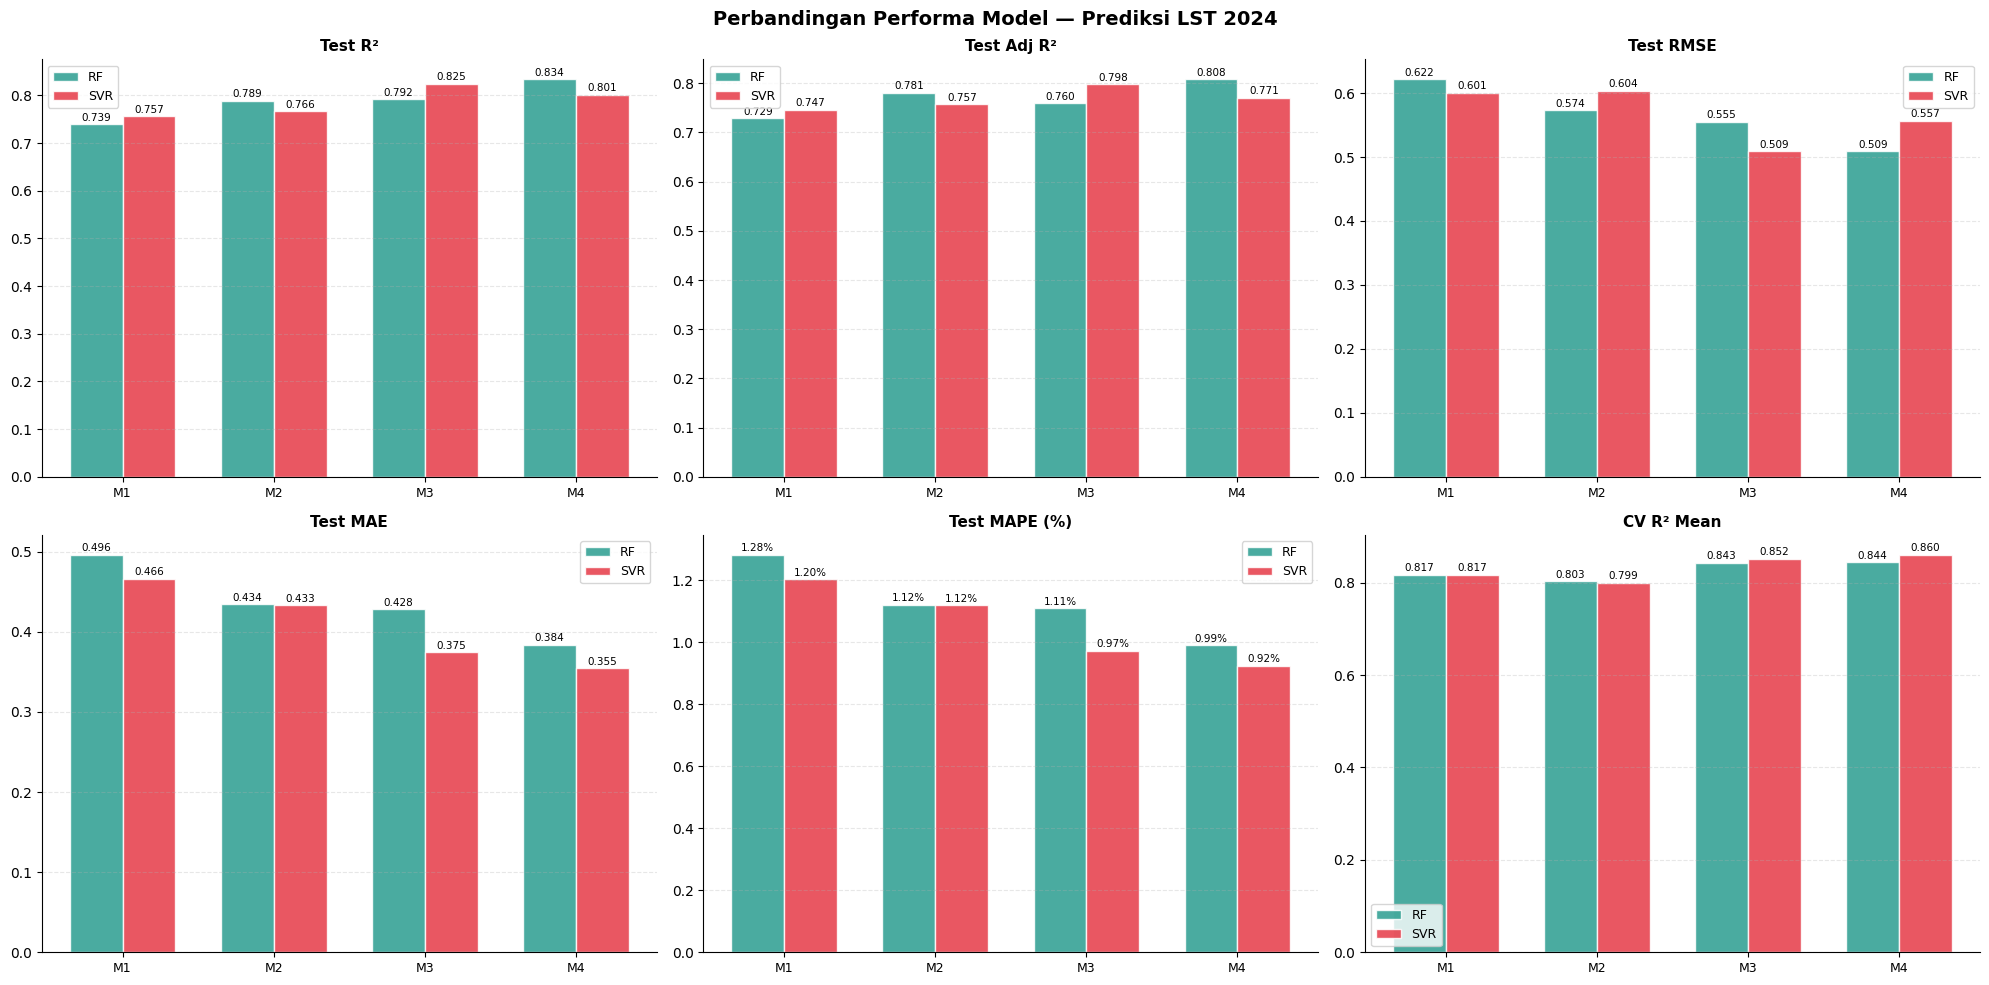

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/plot_metrics_comparison.png


In [ ]:
metrics     = ['Test_R2', 'Test_Adj_R2', 'Test_RMSE', 'Test_MAE', 'Test_MAPE', 'CV_R2_Mean']
m_titles    = ['Test R²', 'Test Adj R²', 'Test RMSE', 'Test MAE', 'Test MAPE (%)', 'CV R² Mean']
algos       = ['RF', 'SVR']
configs     = [cfg['label'] for cfg in MODEL_CONFIGS.values()]
x           = np.arange(len(configs))
width       = 0.35
algo_colors = ['#2A9D8F', '#E63946']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle(f'Perbandingan Performa Model — Prediksi LST {TARGET_YEAR}',
             fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes.flatten(), metrics, m_titles):
    for i, algo in enumerate(algos):
        vals = df_summary[df_summary['Algorithm'] == algo][metric].values
        bars = ax.bar(x + i * width - width/2, vals, width,
                      label=algo, color=algo_colors[i], alpha=0.85,
                      edgecolor='white')
        fmt = '%.2f%%' if metric == 'Test_MAPE' else '%.3f'
        ax.bar_label(bars, fmt=fmt, fontsize=7.5, padding=1)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([c.split(':')[0] for c in configs], fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_metrics_comparison.png')

## 🎯 Sel 10 — Plot Prediksi vs Aktual (Scatter)

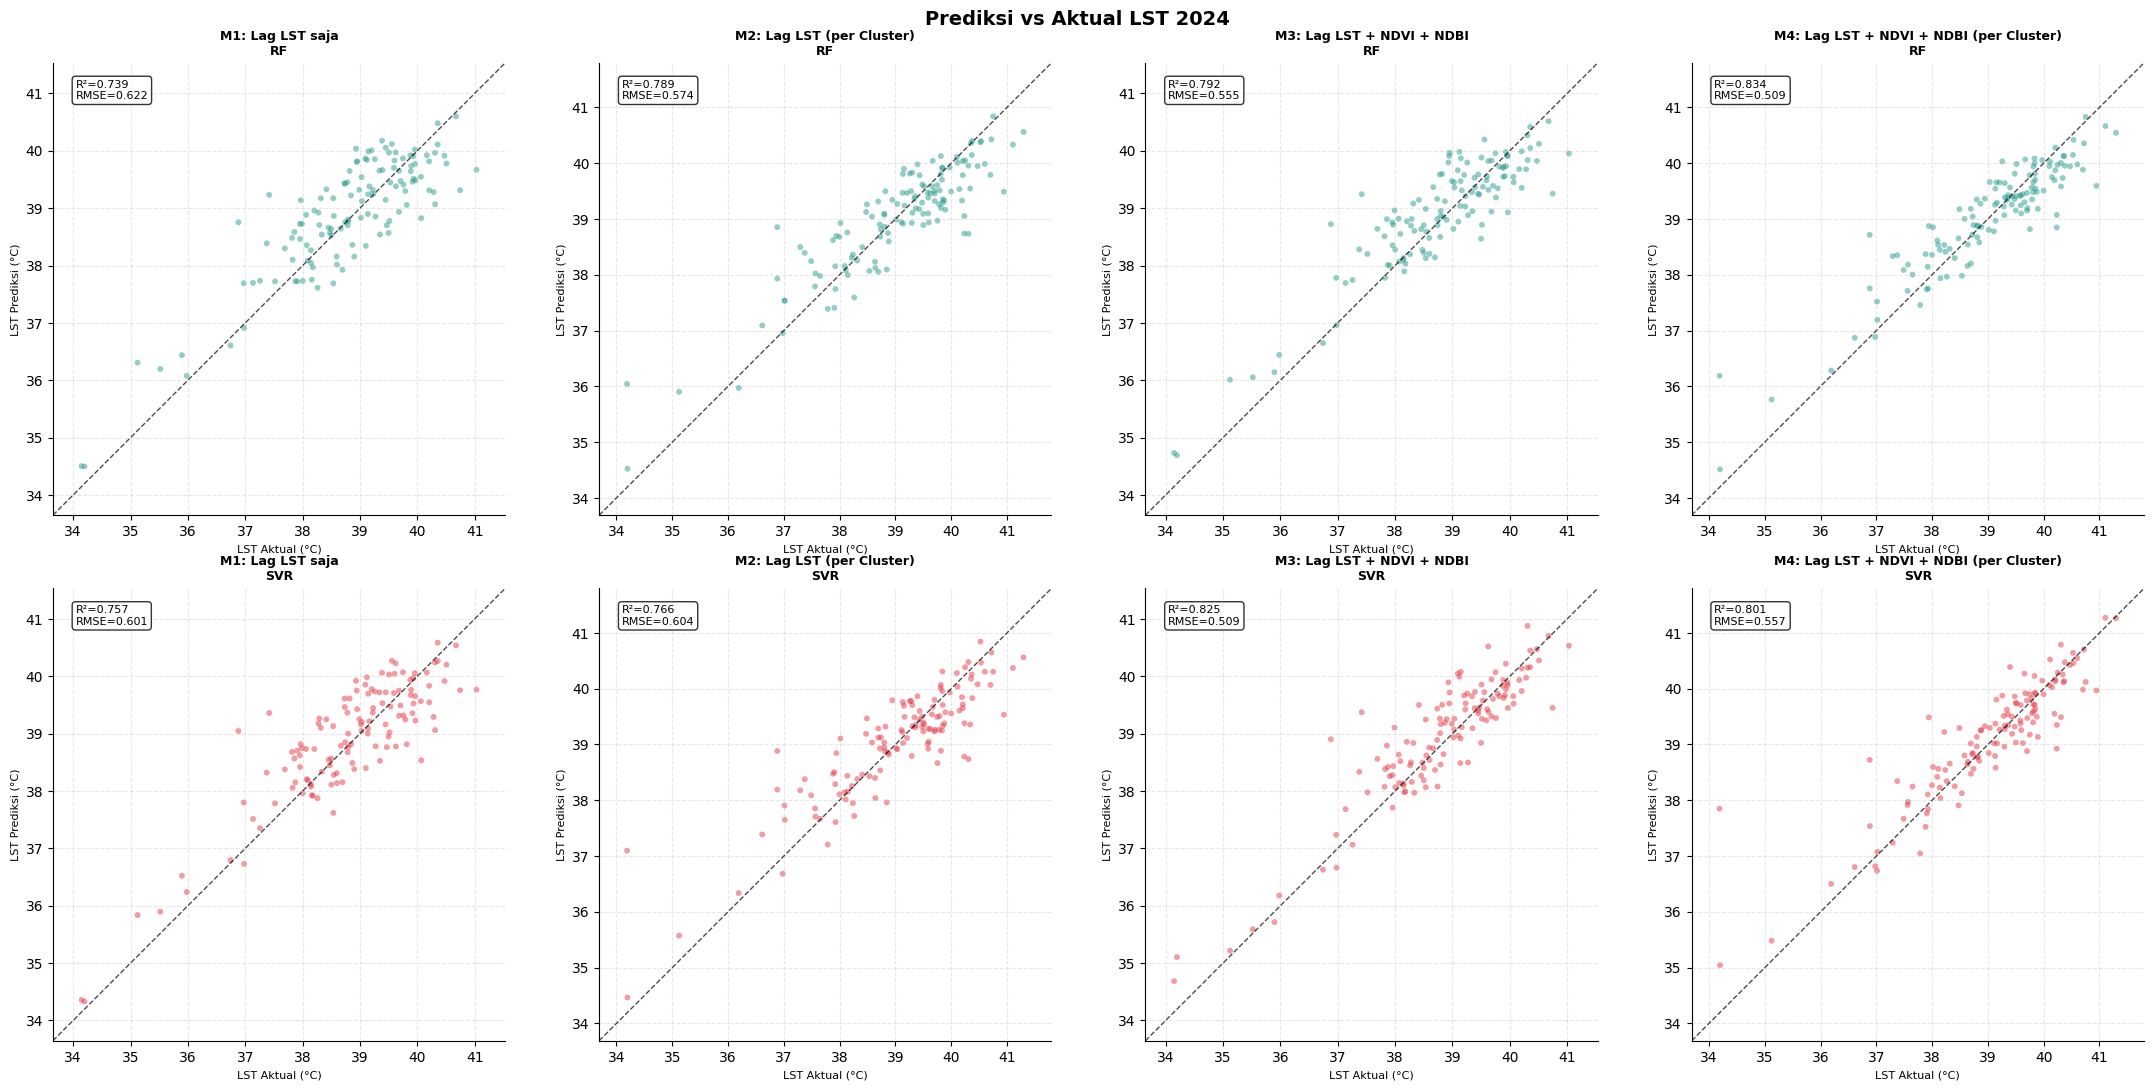

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/plot_scatter_pred_vs_actual.png


In [ ]:
cfg_keys = list(MODEL_CONFIGS.keys())
n_cfg    = len(cfg_keys)
n_algo   = 2  # RF, SVR

fig, axes = plt.subplots(n_algo, n_cfg, figsize=(5.5 * n_cfg, 5.5 * n_algo))
fig.suptitle(f'Prediksi vs Aktual LST {TARGET_YEAR}',
             fontsize=14, fontweight='bold')

palette_scatter = ['#2A9D8F', '#E63946']

for row_i, algo in enumerate(['RF', 'SVR']):
    for col_i, cfg_key in enumerate(cfg_keys):
        ax   = axes[row_i][col_i]
        res  = all_results[(cfg_key, algo)]
        y_t  = res['y_test']
        y_p  = res['y_pred_test']
        r2   = res['Test_R2']
        rmse = res['Test_RMSE']

        ax.scatter(y_t, y_p, alpha=0.5, s=18,
                   color=palette_scatter[row_i], edgecolors='none')

        # Garis perfect prediction
        lims = [min(y_t.min(), y_p.min()) - 0.5,
                max(y_t.max(), y_p.max()) + 0.5]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.7)

        ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n{algo}',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('LST Aktual (°C)', fontsize=8)
        ax.set_ylabel('LST Prediksi (°C)', fontsize=8)
        ax.text(0.05, 0.92, f'R²={r2:.3f}\nRMSE={rmse:.3f}',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3, linestyle='--')
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_scatter_pred_vs_actual.png')

## 🌲 Sel 11 — Feature Importance (Random Forest)

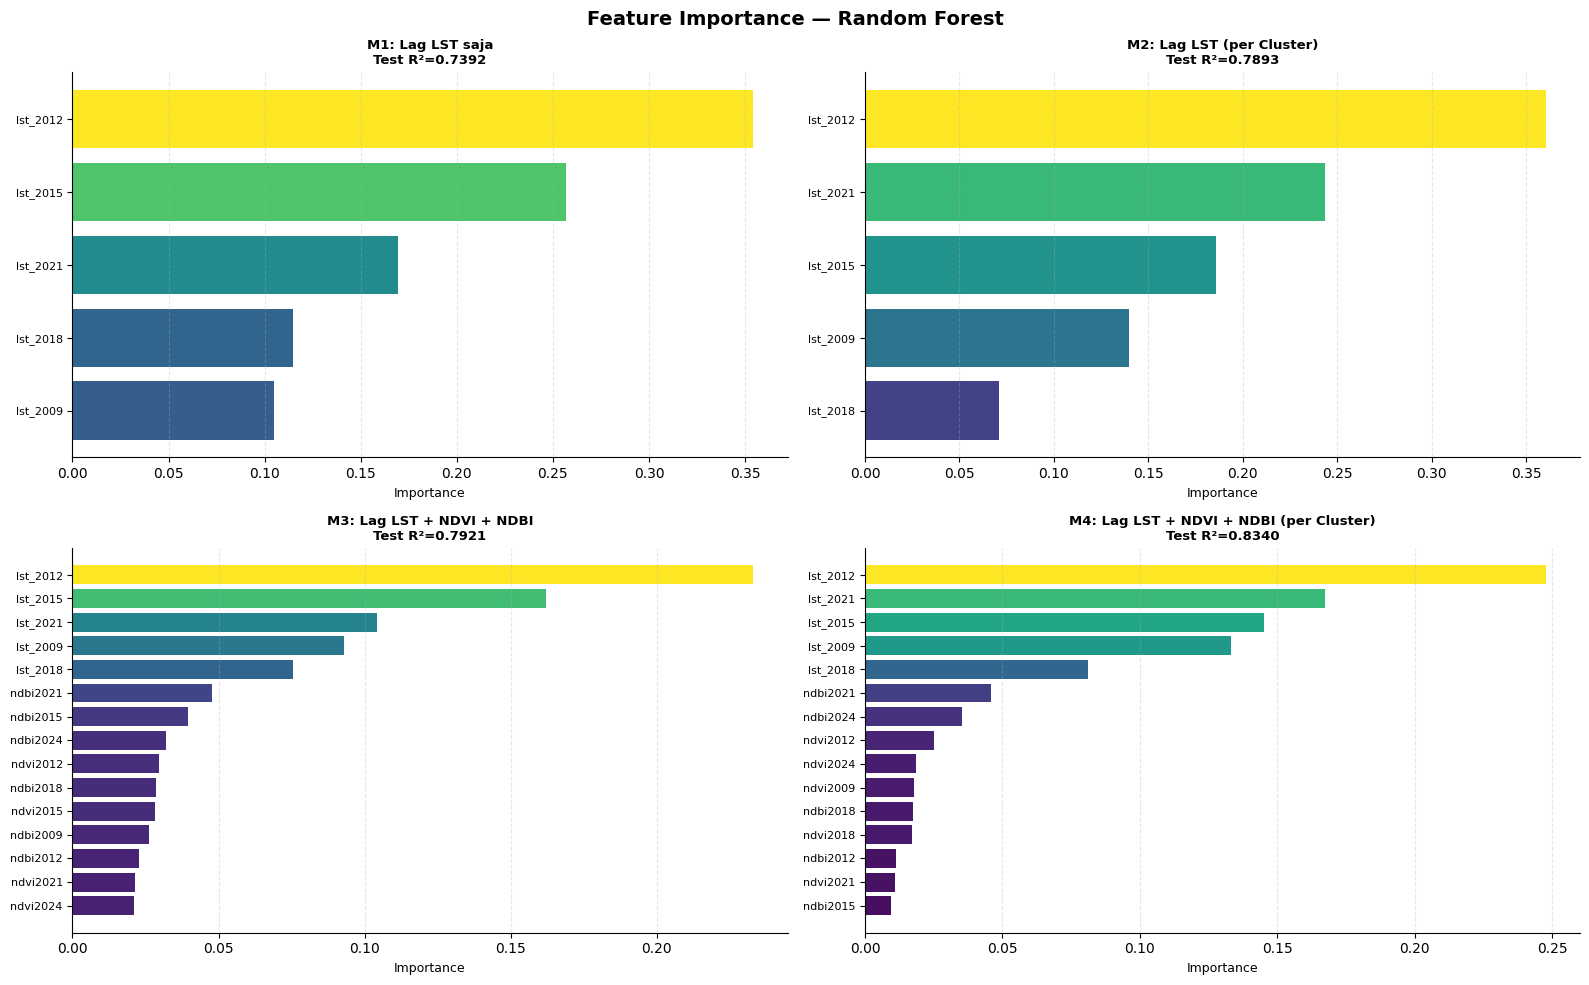

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/plot_feature_importance_rf.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Importance — Random Forest',
             fontsize=14, fontweight='bold')

colors_fi = plt.cm.viridis

for ax, cfg_key in zip(axes.flatten(), cfg_keys):
    res      = all_results[(cfg_key, 'RF')]
    model_rf = res['model_obj']
    feats    = res['features']
    imps     = model_rf.feature_importances_

    # Sort descending
    sorted_idx = np.argsort(imps)[::-1]
    top_n      = min(15, len(feats))
    top_idx    = sorted_idx[:top_n]

    top_feats = [feats[i] for i in top_idx]
    top_imps  = imps[top_idx]

    bar_colors = [colors_fi(v / top_imps.max()) for v in top_imps]
    bars = ax.barh(range(top_n), top_imps[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats[::-1], fontsize=8)
    ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n'
                 f'Test R²={res["Test_R2"]:.4f}',
                 fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'plot_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}plot_feature_importance_rf.png')

## 🔬 Sel 12 — Analisis SHAP

In [ ]:
# ── Fungsi SHAP untuk RF ───────────────────────────────────────────────────
def compute_shap_rf(model, X, feat_names, n_bg=100):
    """Hitung SHAP values untuk Random Forest menggunakan TreeExplainer."""
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    return shap_values  # shape: (n_samples, n_features)


# ── Fungsi SHAP untuk SVR (KernelExplainer — lebih lambat) ───────────────
def compute_shap_svr(pipeline, X_bg, X_exp, feat_names, n_bg=50):
    """Hitung SHAP values untuk SVR Pipeline menggunakan KernelExplainer."""
    # Ambil data background (subsample untuk efisiensi)
    bg_idx  = np.random.choice(len(X_bg), min(n_bg, len(X_bg)), replace=False)
    X_bg_s  = X_bg[bg_idx]

    # Wrapper: scaler sudah ada di pipeline
    f = lambda x: pipeline.predict(x)
    explainer   = shap.KernelExplainer(f, X_bg_s)
    shap_values = explainer.shap_values(X_exp, nsamples=100)
    return shap_values

###  (A) SHAP Summary Plot — semua konfigurasi model × RF

🔬 Menghitung SHAP values (RF) ...


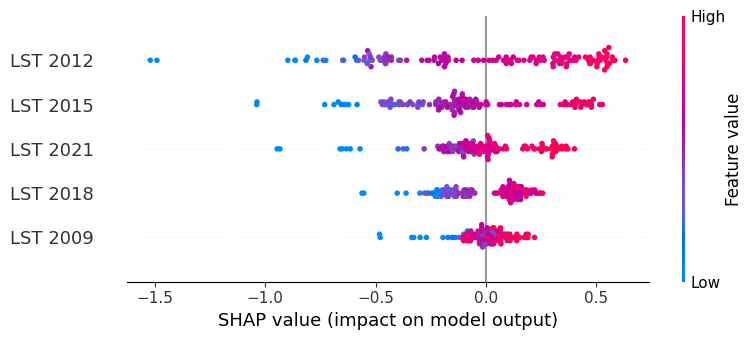

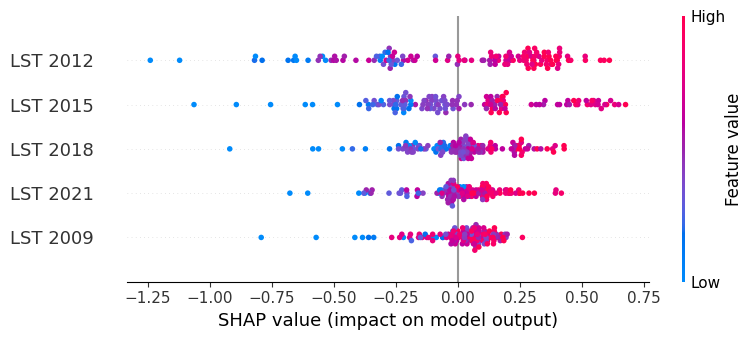

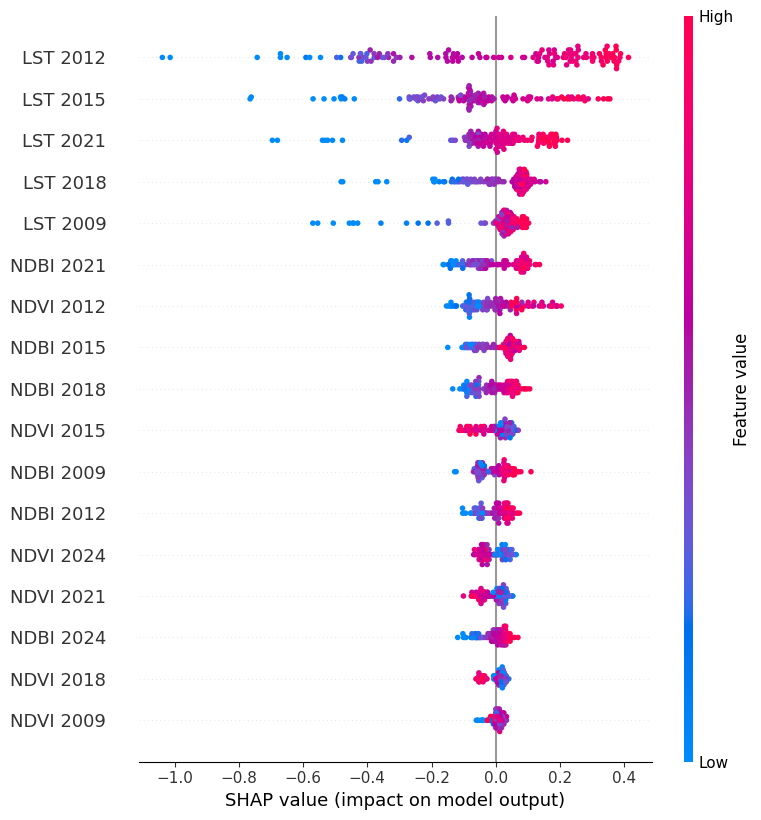

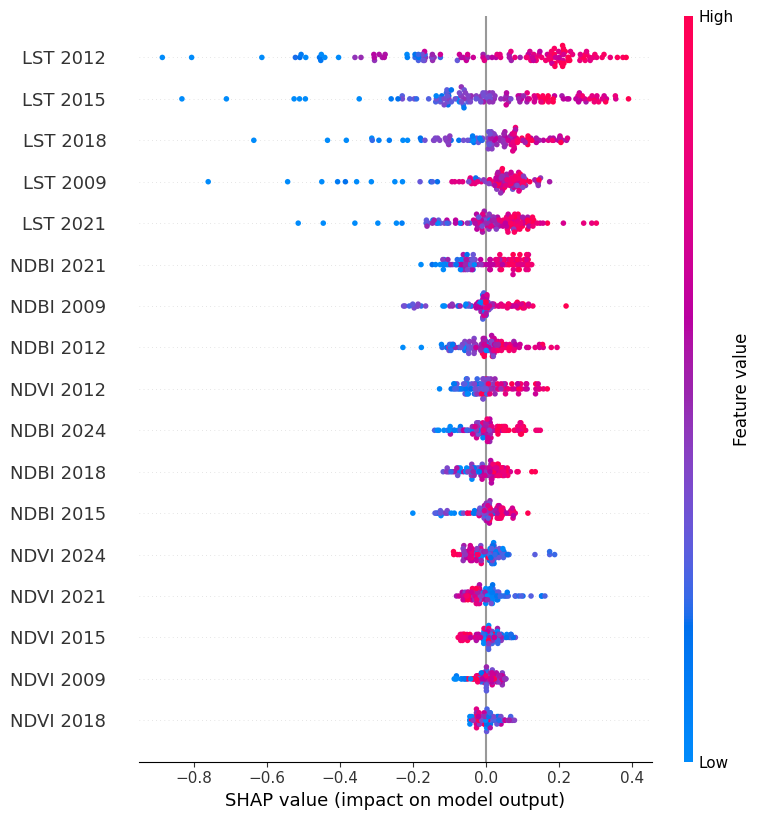

In [ ]:
# =========================================================
# 🔧 HELPER (WAJIB DI ATAS — BIAR NGGAK ERROR)
# =========================================================
import re

def format_feature_label(feat: str) -> str:
    LABEL_MAP = {
        'NDBI': 'NDBI',
        'NDVI': 'NDVI',
        'LST': 'LST',
    }
    feat = feat.replace('-', ' ').replace('_', ' ')
    feat = re.sub(r'([A-Za-z])(\d)', r'\1 \2', feat)
    feat = re.sub(r'(\d)([A-Za-z])', r'\1 \2', feat)
    parts = feat.split()
    return ' '.join(LABEL_MAP.get(p.upper(), p.upper()) for p in parts)


# =========================================================
# 🔬 SHAP SUMMARY PLOT
# =========================================================
print('🔬 Menghitung SHAP values (RF) ...')

shap_store = {}

for cfg_key in cfg_keys:
    cfg   = MODEL_CONFIGS[cfg_key]
    res   = all_results[(cfg_key, 'RF')]
    feats = res['features']

    if not cfg['split_by_cluster']:
        model_rf = res['model_obj']
        X_exp    = res['X_test']
        sv       = compute_shap_rf(model_rf, X_exp, feats)
    else:
        sv_list, X_list = [], []
        for cl in clusters:
            m    = res['cluster_models'][cl]['RF']
            X_te = res['cluster_X_test'][cl]
            sv_c = compute_shap_rf(m, X_te, feats)
            sv_list.append(sv_c)
            X_list.append(X_te)
        sv = np.vstack(sv_list)
        X_exp = np.vstack(X_list)

    shap_store[(cfg_key, 'RF')] = {'sv': sv, 'X': X_exp, 'feats': feats}

    # ===== format label =====
    feats_fmt = [format_feature_label(f) for f in feats]

    # ===== sorting =====
    mean_abs   = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]

    sv_sorted    = sv[:, sorted_idx]
    X_sorted     = X_exp[:, sorted_idx]
    feats_sorted = [feats_fmt[i] for i in sorted_idx]

    # ===== plot =====
    plt.figure(figsize=(10, max(6, len(feats)*0.4)))

    shap.summary_plot(
        sv_sorted,
        X_sorted,
        feature_names=feats_sorted,
        show=False,
        max_display=len(feats),
    )

    plt.tight_layout()
    fname = OUTPUT_DIR + f'shap_summary_rf_{cfg_key}.png'
    plt.savefig(fname, dpi=150)
    plt.show()

###  (B) SHAP Bar Plot — Mean |SHAP| per fitur (RF)

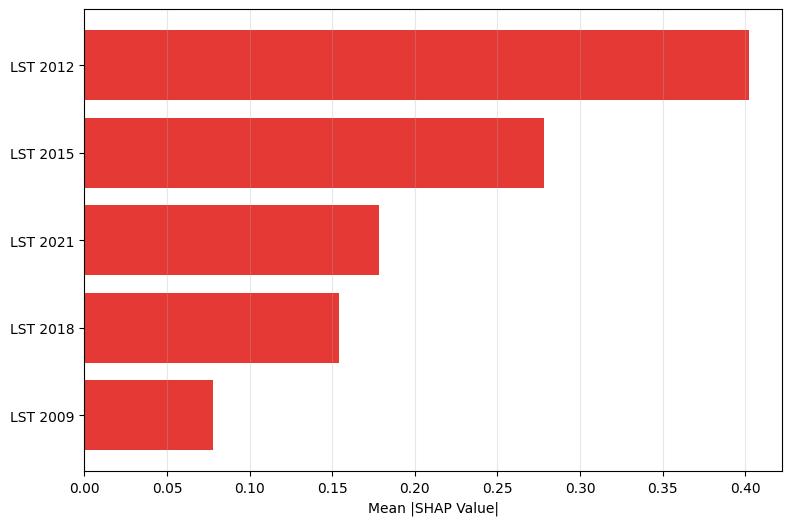

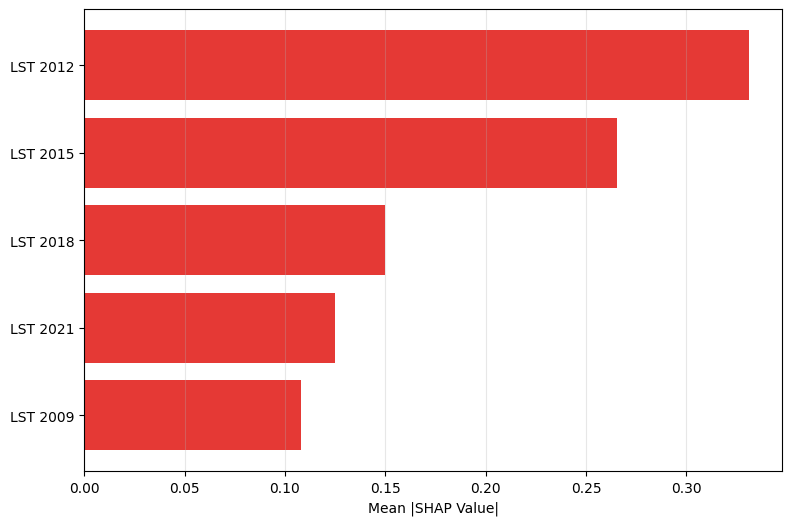

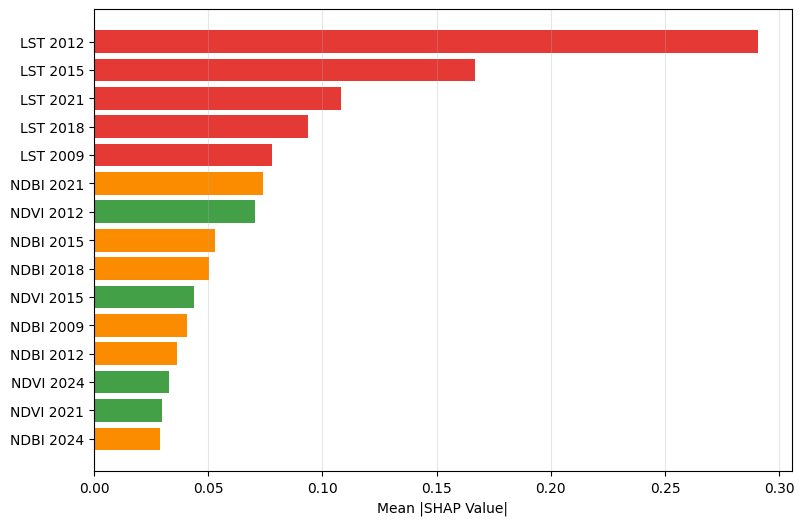

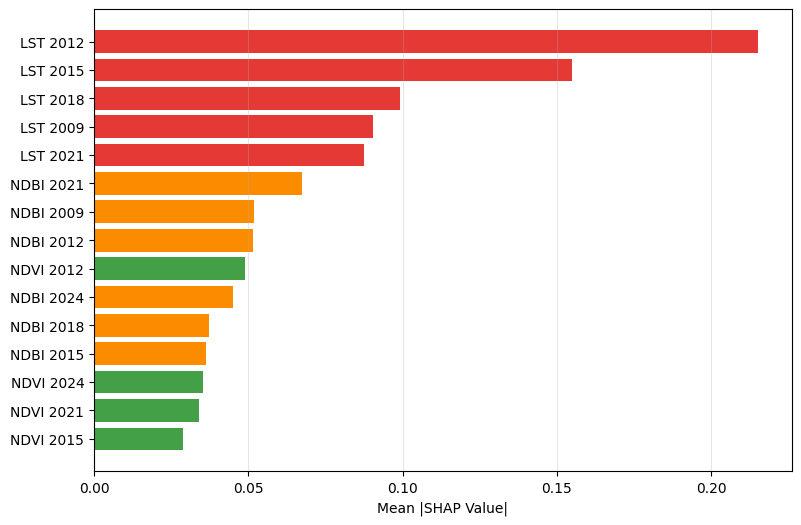

In [ ]:
# =========================================================
# 🎨 WARNA FITUR
# =========================================================
FEATURE_COLOR_MAP = {
    'LST'  : '#e53935',
    'NDVI' : '#43a047',
    'NDBI' : '#fb8c00',
}
DEFAULT_COLOR = '#757575'

def get_feature_type(feat: str) -> str:
    feat_upper = feat.upper().replace('_', '').replace('-', '')
    for key in FEATURE_COLOR_MAP:
        if feat_upper.startswith(key):
            return key
    return None


# =========================================================
# 📊 SHAP BAR PLOT
# =========================================================
for cfg_key in cfg_keys:
    store = shap_store[(cfg_key, 'RF')]
    sv    = store['sv']
    feats = store['feats']

    mean_abs   = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]

    top_n = min(15, len(feats))
    top_idx = sorted_idx[:top_n]

    top_feats_raw = [feats[i] for i in top_idx]
    top_feats_fmt = [format_feature_label(feats[i]) for i in top_idx]
    top_vals      = mean_abs[top_idx]

    colors = [
        FEATURE_COLOR_MAP.get(get_feature_type(f), DEFAULT_COLOR)
        for f in top_feats_raw
    ]

    plt.figure(figsize=(9,6))
    plt.barh(range(top_n), top_vals[::-1], color=colors[::-1])
    plt.yticks(range(top_n), top_feats_fmt[::-1])
    plt.xlabel('Mean |SHAP Value|')
    plt.grid(axis='x', alpha=0.3)

    fname = OUTPUT_DIR + f'shap_bar_rf_{cfg_key}.png'
    plt.savefig(fname, dpi=150)
    plt.show()

###  (C) SHAP per Cluster — Model M2 & M4 (yang split_by_cluster)

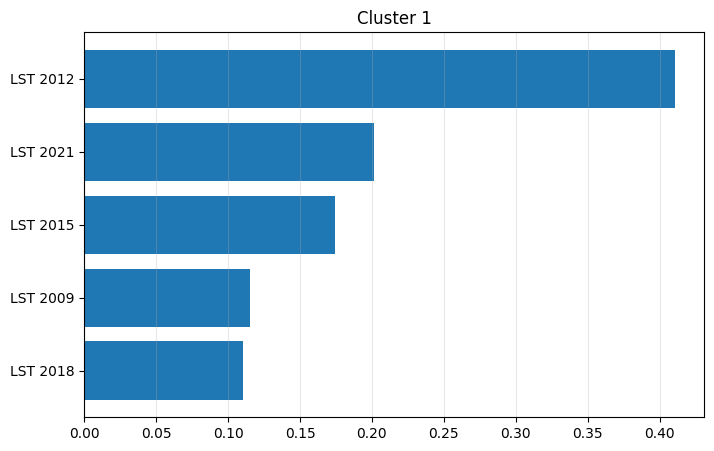

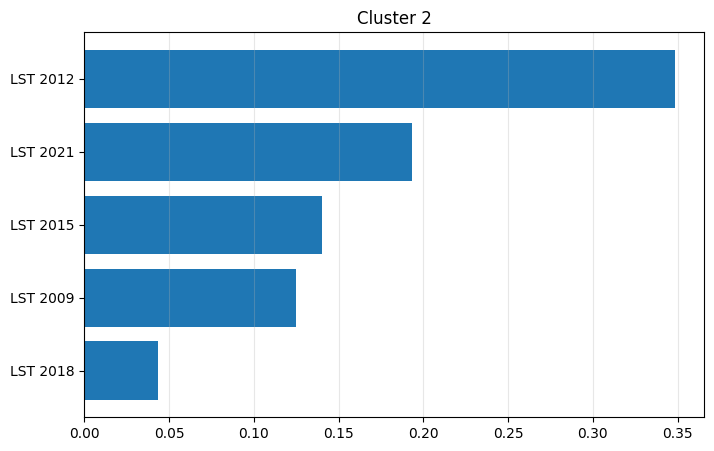

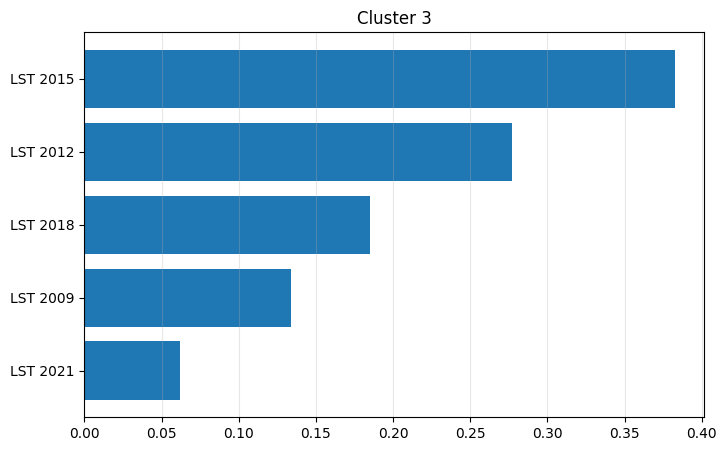

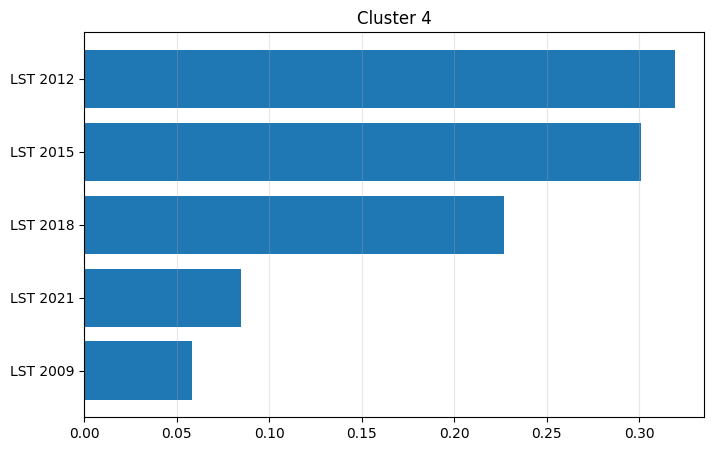

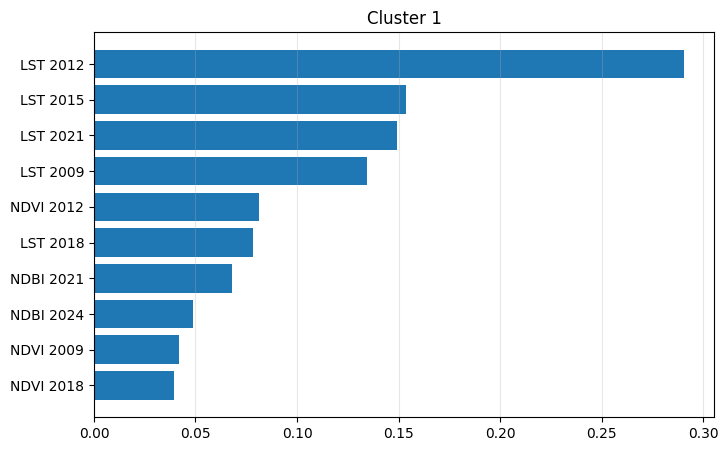

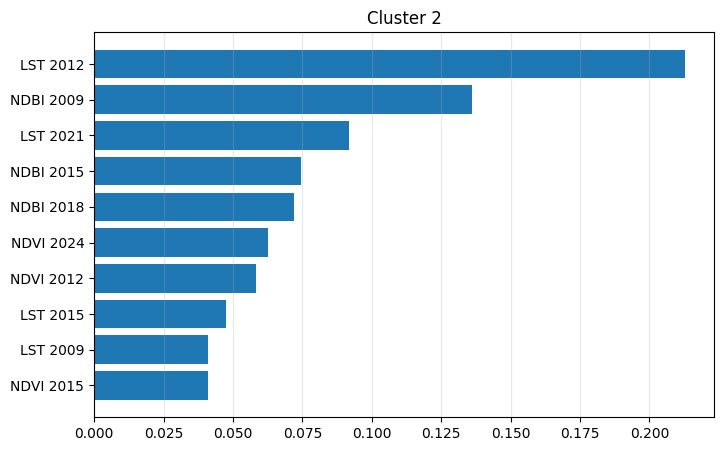

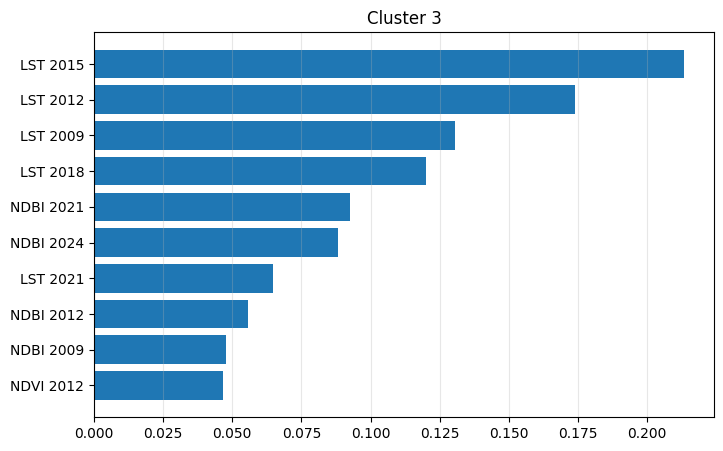

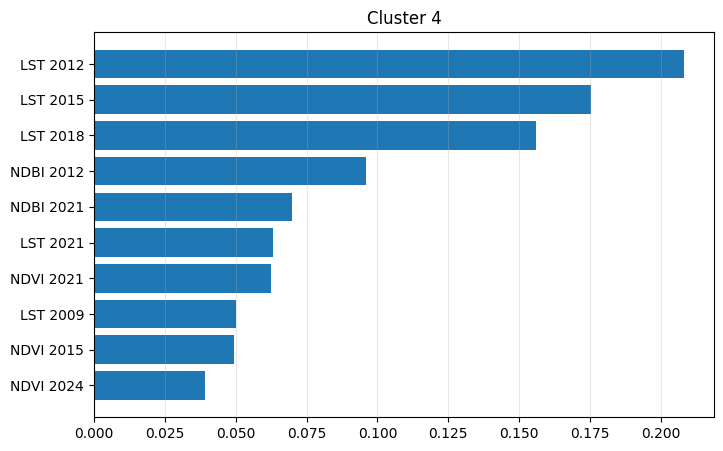

In [ ]:
cluster_cfg_keys = [k for k,v in MODEL_CONFIGS.items() if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    res   = all_results[(cfg_key, 'RF')]
    feats = res['features']

    for cl in clusters:
        model = res['cluster_models'][cl]['RF']
        X_te  = res['cluster_X_test'][cl]

        sv = compute_shap_rf(model, X_te, feats)

        mean_abs   = np.abs(sv).mean(axis=0)
        sorted_idx = np.argsort(mean_abs)[::-1]

        top_n = min(10, len(feats))
        top_idx = sorted_idx[:top_n]

        feats_fmt = [format_feature_label(feats[i]) for i in top_idx]
        vals      = mean_abs[top_idx]

        plt.figure(figsize=(8,5))
        plt.barh(range(top_n), vals[::-1])
        plt.yticks(range(top_n), feats_fmt[::-1])
        plt.title(f'Cluster {cl}')
        plt.grid(axis='x', alpha=0.3)

        fname = OUTPUT_DIR + f'shap_cluster_{cfg_key}_{cl}.png'
        plt.savefig(fname, dpi=150)
        plt.show()

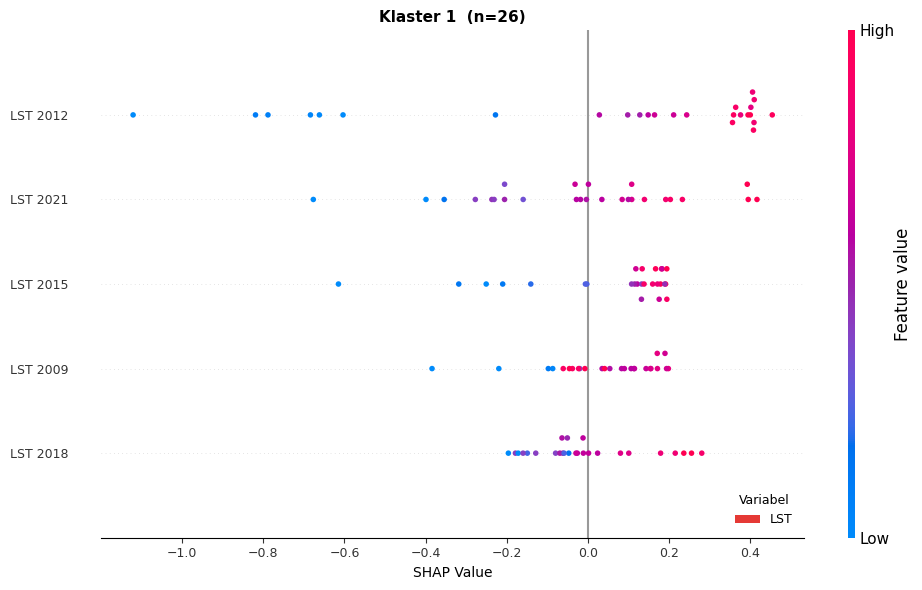

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster1.png


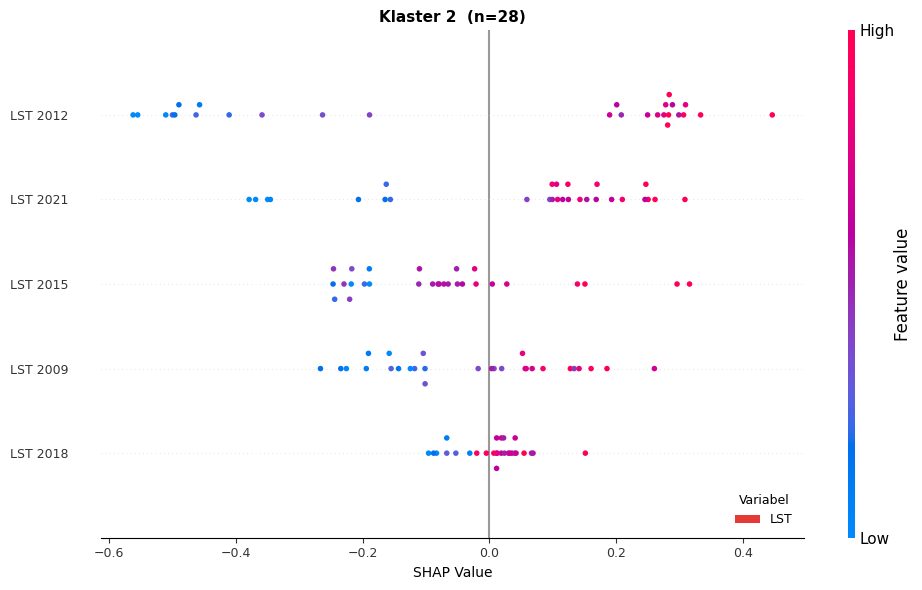

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster2.png


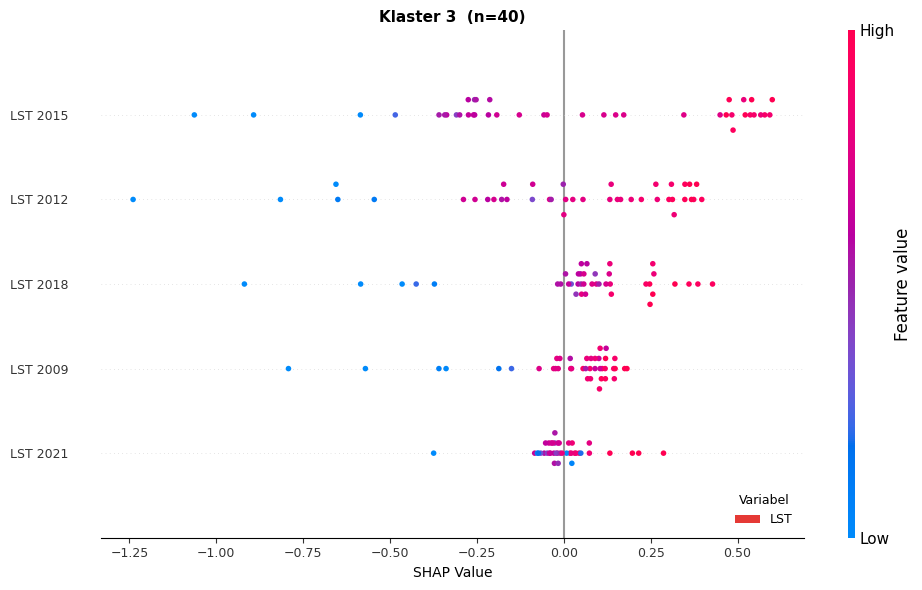

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster3.png


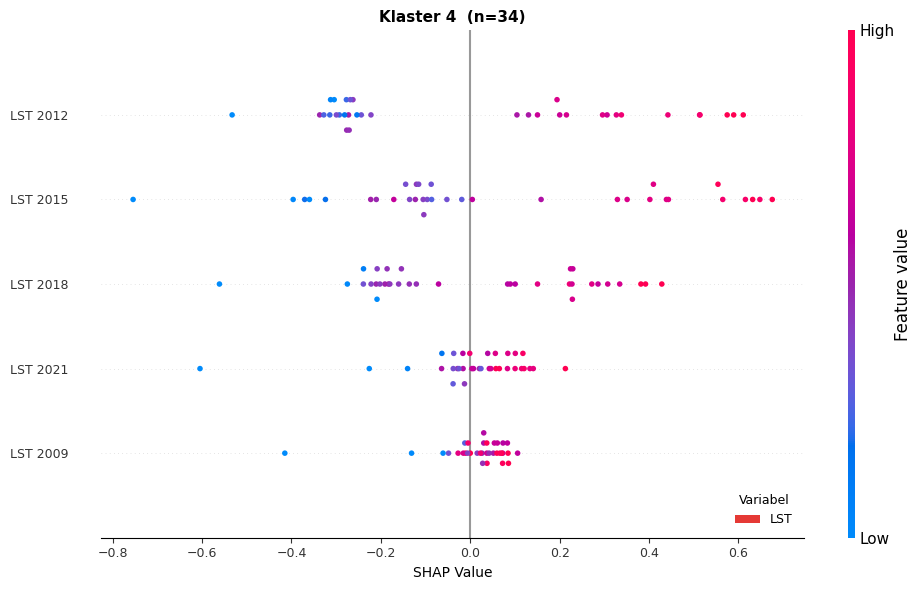

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M2_LagLST_byCluster_cluster4.png


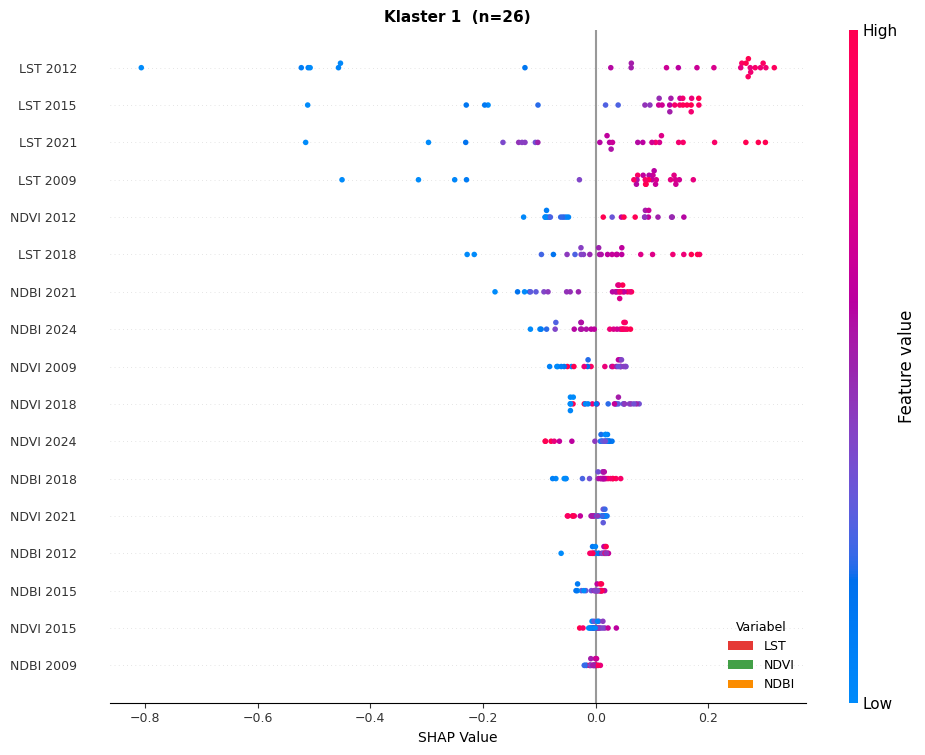

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster1.png


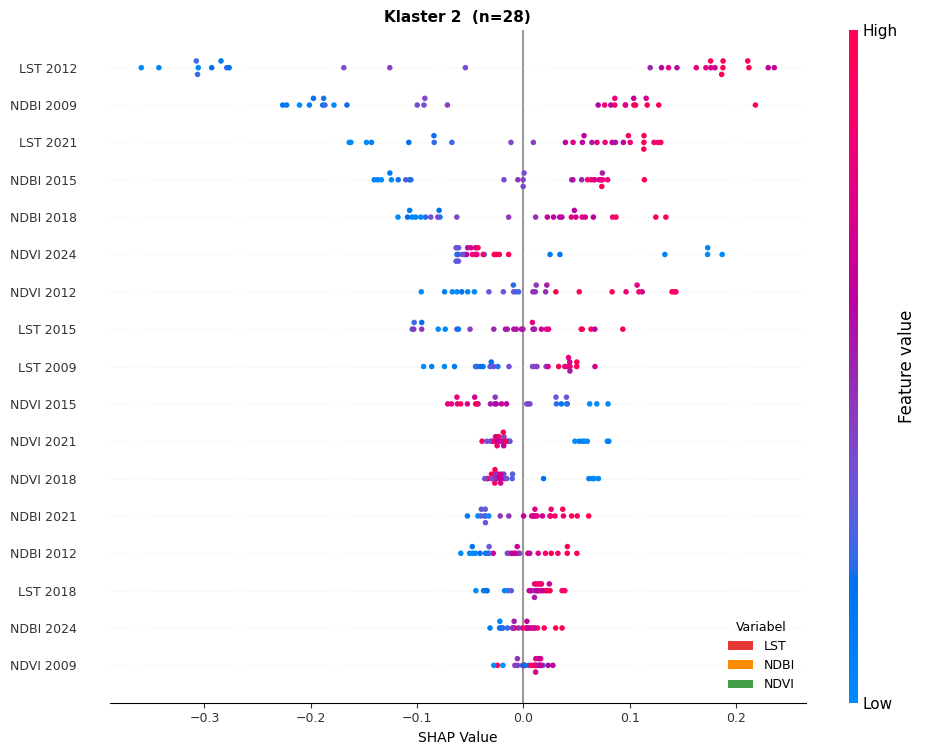

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster2.png


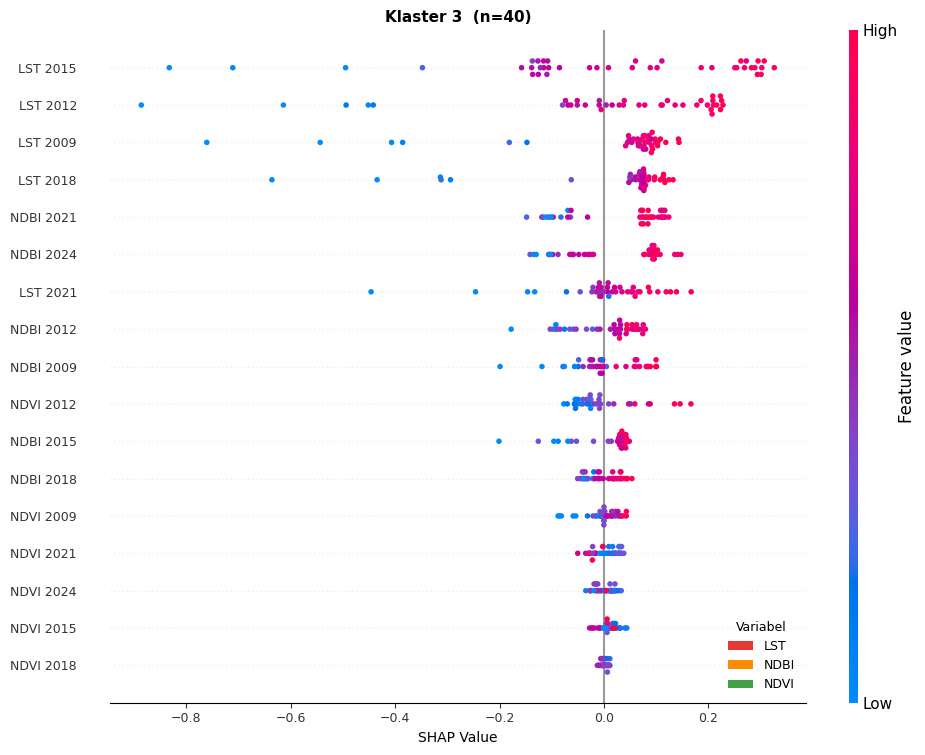

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster3.png


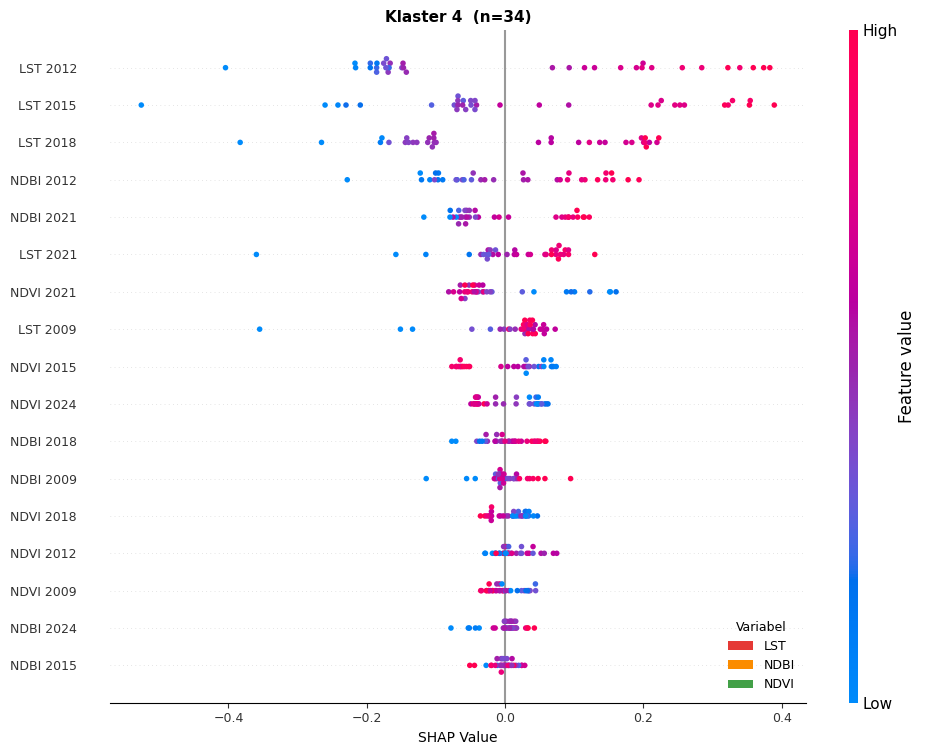

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_M4_LagAll_byCluster_cluster4.png


In [ ]:
import re
from matplotlib.patches import Patch

FEATURE_COLOR_MAP = {
    'LST'  : '#e53935',
    'NDVI' : '#43a047',
    'NDBI' : '#fb8c00',
}
DEFAULT_COLOR = '#757575'

def get_feature_type(feat: str) -> str:
    feat_upper = feat.upper().replace('_', '').replace('-', '')
    for key in FEATURE_COLOR_MAP:
        if feat_upper.startswith(key.replace(' ', '')):
            return key
    return None

def format_feature_label(feat: str) -> str:
    LABEL_MAP = {'NDBI': 'NDBI', 'NDVI': 'NDVI', 'LST': 'LST'}
    feat = feat.replace('-', ' ').replace('_', ' ')
    feat = re.sub(r'([A-Za-z])(\d)', r'\1 \2', feat)
    feat = re.sub(r'(\d)([A-Za-z])', r'\1 \2', feat)
    parts = feat.split()
    return ' '.join(LABEL_MAP.get(p.upper(), p.upper()) for p in parts)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    cfg       = MODEL_CONFIGS[cfg_key]
    res       = all_results[(cfg_key, 'RF')]
    feats     = res['features']
    cl_models = res['cluster_models']
    feats_fmt = [format_feature_label(f) for f in feats]

    for cl in clusters:
        m    = cl_models[cl]['RF']
        X_te = res['cluster_X_test'][cl]
        sv_c = compute_shap_rf(m, X_te, feats)
        n_te = len(res['cluster_y_test'][cl])

        # Urutkan semua fitur berdasarkan mean |SHAP|
        mean_abs   = np.abs(sv_c).mean(axis=0)
        sorted_idx = np.argsort(mean_abs)[::-1]
        top_n      = len(feats)                      # semua fitur

        sv_sorted    = sv_c[:, sorted_idx]
        X_sorted     = X_te[:, sorted_idx]
        feats_sorted = [feats_fmt[i] for i in sorted_idx]

        # Warna dot berdasarkan jenis variabel (override colormap SHAP)
        dot_colors = [
            FEATURE_COLOR_MAP.get(get_feature_type(feats[i]), DEFAULT_COLOR)
            for i in sorted_idx
        ]

        fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.45)))
        plt.sca(ax)

        shap.summary_plot(
            sv_sorted,
            X_sorted,
            feature_names=feats_sorted,
            show=False,
            plot_size=None,
            max_display=top_n,
            color_bar=True,
        )

        ax.set_title(f'Klaster {int(cl)}  (n={n_te})', fontsize=11, fontweight='bold')
        ax.set_xlabel('SHAP Value', fontsize=10)
        ax.tick_params(axis='y', labelsize=9)
        ax.tick_params(axis='x', labelsize=9)

        # Legend jenis variabel
        used_types = dict.fromkeys(
            get_feature_type(feats[i]) for i in sorted_idx
        )
        legend_handles = [
            Patch(facecolor=FEATURE_COLOR_MAP.get(t, DEFAULT_COLOR), label=t)
            for t in used_types if t is not None
        ]
        ax.legend(
            handles=legend_handles,
            title='Variabel',
            loc='lower right',
            fontsize=9,
            title_fontsize=9,
            frameon=False,
        )

        plt.tight_layout()
        fname = OUTPUT_DIR + f'shap_beeswarm_{cfg_key}_cluster{int(cl)}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'💾 Disimpan: {fname}')
        plt.close()

###  (D) SHAP Dependence Plot — Fitur terpenting (model terbaik RF)

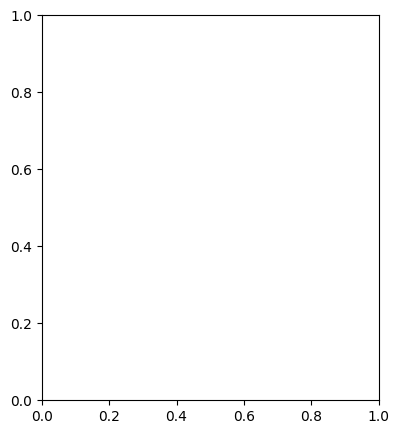

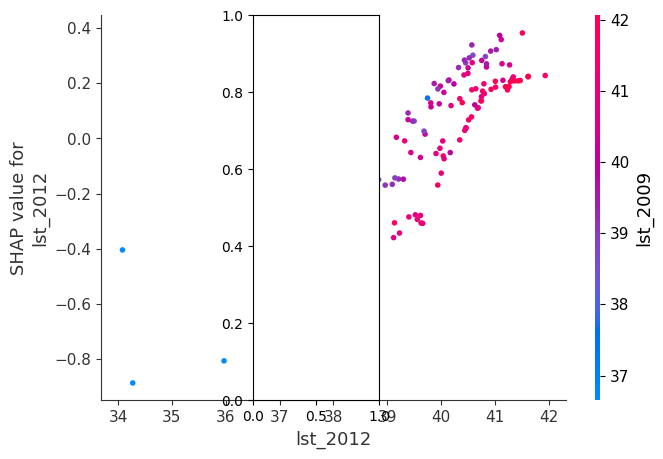

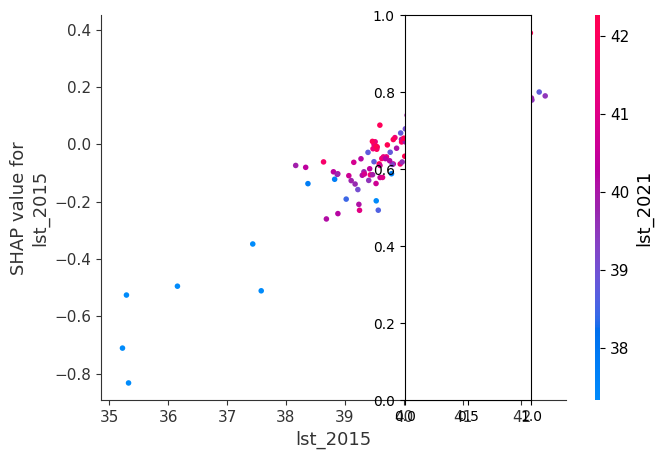

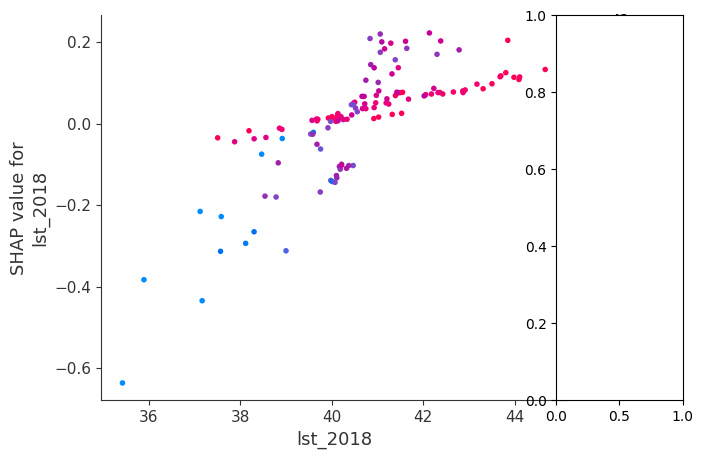

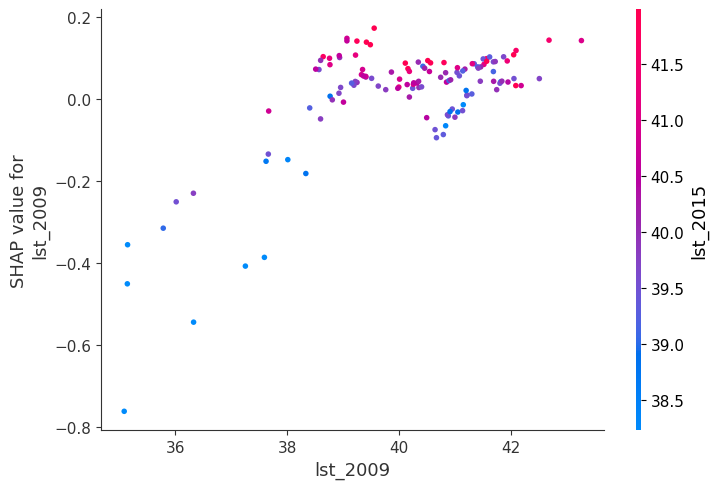

In [ ]:
# model terbaik RF
df_rf = df_summary[df_summary['Algorithm']=='RF'].reset_index(drop=True)
best_cfg_key = cfg_keys[df_rf['Test_R2'].idxmax()]

store = shap_store[(best_cfg_key, 'RF')]
sv    = store['sv']
X     = store['X']
feats = store['feats']

top_idx = np.argsort(np.abs(sv).mean(axis=0))[::-1][:4]
top_feats = [feats[i] for i in top_idx]

plt.figure(figsize=(20,5))

for i, feat in enumerate(top_feats):
    plt.subplot(1,4,i+1)
    shap.dependence_plot(
        feats.index(feat),
        sv,
        X,
        feature_names=feats,
        show=False
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_dependence.png', dpi=150)
plt.show()

## 🗺️ Sel 13 — Residual Map per Grid (Model Terbaik)

Model terbaik RF  : M4: Lag LST + NDVI + NDBI (per Cluster)
Model terbaik SVR : M3: Lag LST + NDVI + NDBI


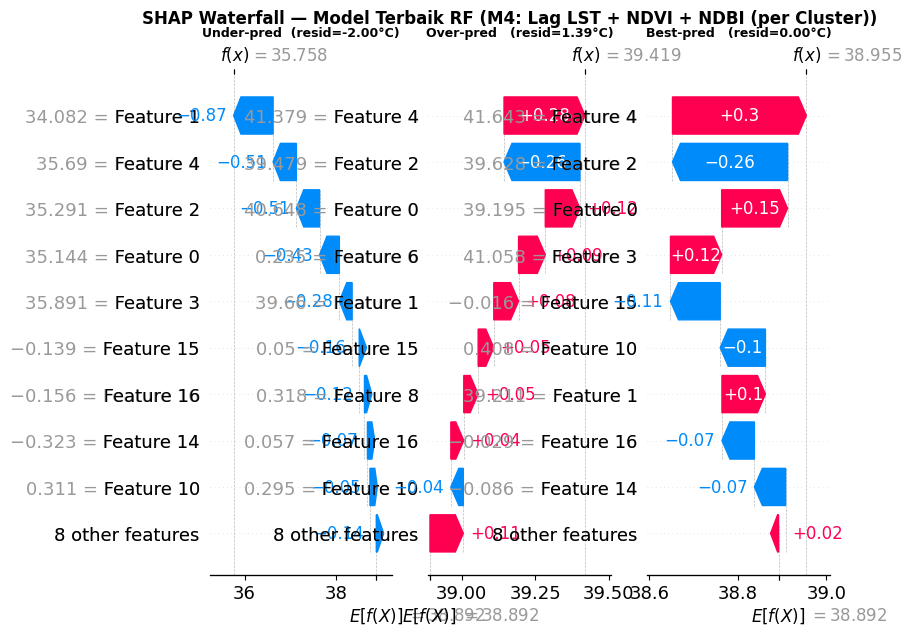

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_waterfall_samples.png


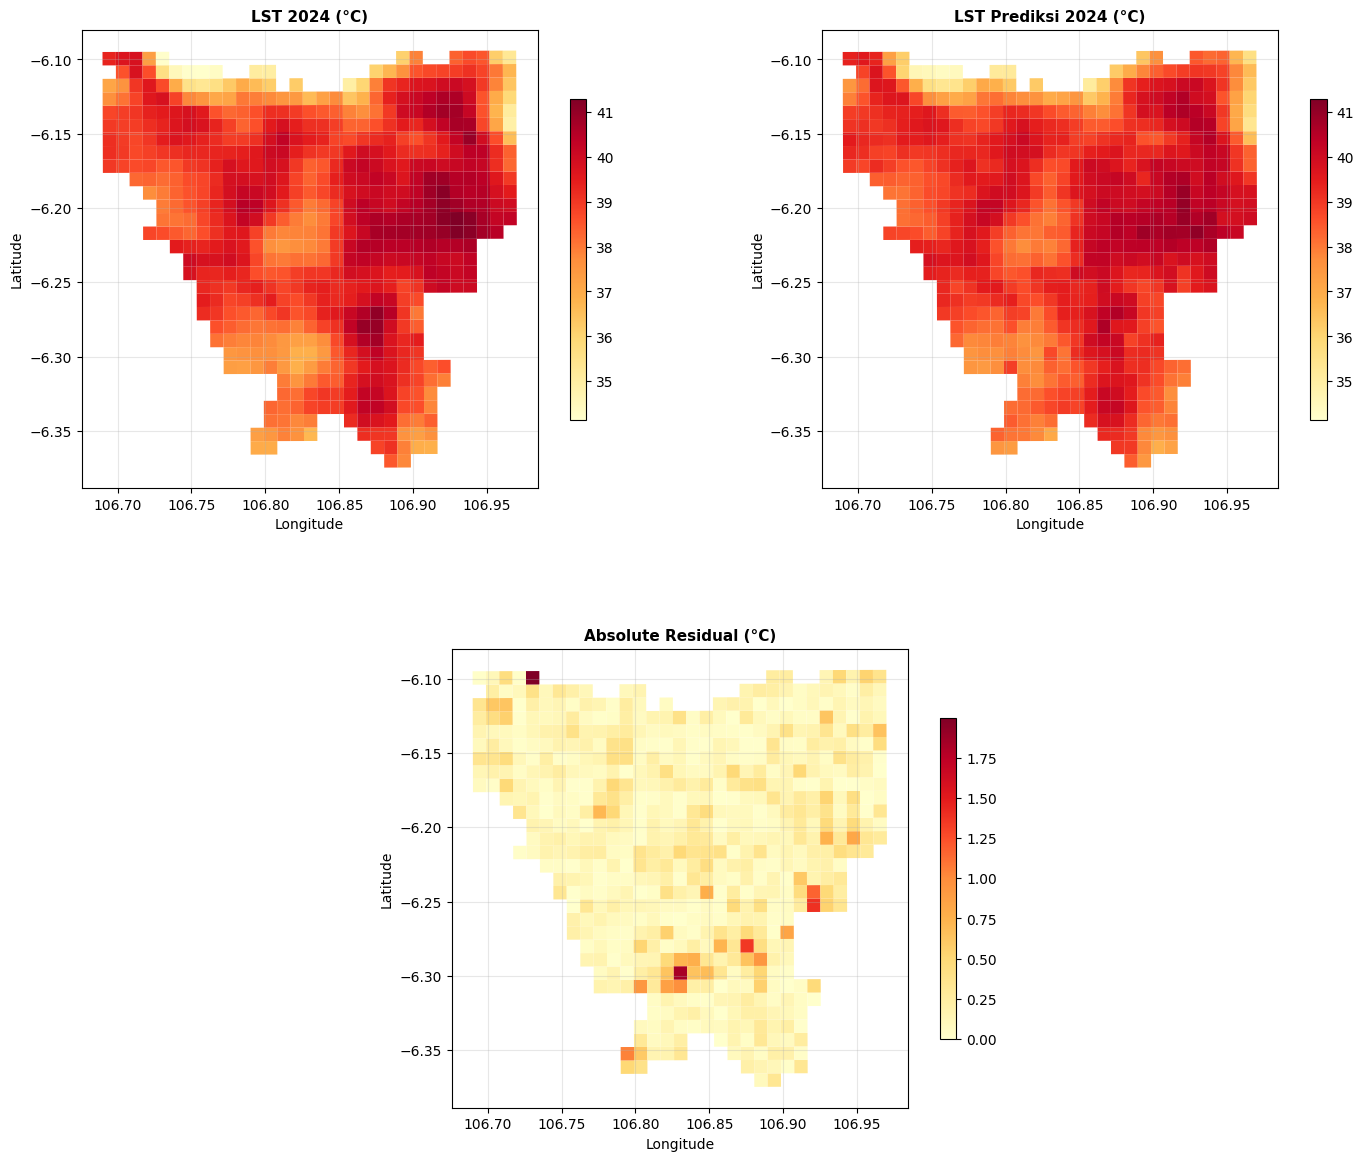

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/peta_prediksi_residual.png


NameError: name 'shap_store' is not defined

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  TENTUKAN MODEL TERBAIK RF (dipakai Sel 12, 13, 14)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ✅ PERBAIKAN: reset_index dulu agar idxmax() → 0,1,2,3 sesuai posisi cfg_keys
df_rf  = df_summary[df_summary['Algorithm'] == 'RF'].reset_index(drop=True)
df_svr = df_summary[df_summary['Algorithm'] == 'SVR'].reset_index(drop=True)

best_cfg_key_rf = cfg_keys[df_rf['Test_R2'].idxmax()]   # pakai di SHAP
best_rf_key     = best_cfg_key_rf                        # pakai di peta
best_svr_key    = cfg_keys[df_svr['Test_R2'].idxmax()]

print(f'Model terbaik RF  : {MODEL_CONFIGS[best_rf_key]["label"]}')
print(f'Model terbaik SVR : {MODEL_CONFIGS[best_svr_key]["label"]}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  (E) SHAP Waterfall — 3 sampel (under/over/well predicted)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

res_best  = all_results[(best_cfg_key_rf, 'RF')]
y_te_best = res_best['y_test']
y_pr_best = res_best['y_pred_test']
residuals = y_te_best - y_pr_best

idx_under = np.argmin(residuals)
idx_over  = np.argmax(residuals)
idx_good  = np.argmin(np.abs(residuals))

model_best   = res_best['model_obj']
X_te_best    = res_best['X_test']
explainer_wf = shap.TreeExplainer(model_best)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle(f'SHAP Waterfall — Model Terbaik RF ({MODEL_CONFIGS[best_cfg_key_rf]["label"]})',
             fontsize=12, fontweight='bold')

sample_labels = [
    (idx_under, f'Under-pred  (resid={residuals[idx_under]:.2f}°C)'),
    (idx_over,  f'Over-pred   (resid={residuals[idx_over]:.2f}°C)'),
    (idx_good,  f'Best-pred   (resid={residuals[idx_good]:.2f}°C)'),
]

for ax, (s_idx, s_label) in zip(axes, sample_labels):
    plt.sca(ax)
    sv_exp = explainer_wf(X_te_best[s_idx:s_idx+1])
    shap.waterfall_plot(sv_exp[0], max_display=10, show=False)
    ax.set_title(s_label, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_waterfall_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}shap_waterfall_samples.png')

"""## 🗺️ Sel 13 — Residual Map per Grid (Model Terbaik RF)"""

# best_rf_key & best_svr_key sudah ditetapkan di atas ✅

res_best_rf = all_results[(best_rf_key, 'RF')]
feats_best  = res_best_rf['features']
cfg_best    = MODEL_CONFIGS[best_rf_key]

y_all = df[TARGET_COL].values

if not cfg_best['split_by_cluster']:
    model_rf_best = res_best_rf['model_obj']
    X_all         = df[feats_best].values
    y_pred_all    = model_rf_best.predict(X_all)
else:
    y_pred_all = np.full(len(df), np.nan)
    for cl in clusters:
        m      = res_best_rf['cluster_models'][cl]['RF']
        idx_cl = df.index[df[CLUSTER_COL] == cl].tolist()
        X_cl   = df.loc[idx_cl, feats_best].values
        y_pred_all[idx_cl] = m.predict(X_cl)

residuals_all = y_all - y_pred_all

df_pred = df[['grid_id', TARGET_COL]].copy()
df_pred['predicted'] = y_pred_all
df_pred['residual']  = residuals_all
df_pred['abs_error'] = np.abs(residuals_all)

gdf_map = (
    gdf_ndvi[['grid_id', 'geometry']]
    .merge(df_pred, on='grid_id', how='inner')
)
gdf_map = gpd.GeoDataFrame(gdf_map, geometry='geometry')
fig = plt.figure(figsize=(18, 14))
cfg_lbl = MODEL_CONFIGS[best_rf_key]['label']
fig.suptitle('')

# ✅ Shared colorbar bounds untuk Aktual & Prediksi
lst_min = min(gdf_map[f'lst_{TARGET_YEAR}'].min(), gdf_map['predicted'].min())
lst_max = max(gdf_map[f'lst_{TARGET_YEAR}'].max(), gdf_map['predicted'].max())
err_min = 0                            # ✅ tambah err_min
err_max = gdf_map['abs_error'].max()

# ✅ Hapus add_subplot lama, pakai GridSpec saja
import matplotlib.gridspec as gridspec
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])     # tengah baris bawah

plot_specs = [
    (ax1, f'lst_{TARGET_YEAR}', 'LST 2024 (°C)',          'YlOrRd', lst_min, lst_max),
    (ax2, 'predicted',           'LST Prediksi 2024 (°C)', 'YlOrRd', lst_min, lst_max),
    (ax3, 'abs_error',           'Absolute Residual (°C)', 'YlOrRd', err_min, err_max),
]

# ✅ ax ikut di plot_specs, bukan zip(axes, ...)
for ax, col, title, cmap, vmin, vmax in plot_specs:
    gdf_map.plot(column=col, ax=ax, cmap=cmap,
                 vmin=vmin, vmax=vmax,
                 legend=True,
                 legend_kwds={'shrink': 0.7},
                 edgecolor='none', linewidth=0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR + 'peta_prediksi_residual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}peta_prediksi_residual.png')

"""## 🗺️ Sel 14 — SHAP Spatial Map"""

store_best = shap_store[(best_rf_key, 'RF')]
sv_map     = store_best['sv']
feats_map  = store_best['feats']

top1_feat = feats_map[np.abs(sv_map).mean(axis=0).argmax()]
top1_idx  = feats_map.index(top1_feat)

if not cfg_best['split_by_cluster']:
    idx_te_map = idx_test_global
else:
    idx_te_map = res_best_rf['idx_test_union']

df_shap_spatial = df.iloc[idx_te_map][['grid_id']].copy().reset_index(drop=True)
df_shap_spatial[f'shap_{top1_feat}'] = sv_map[:, top1_idx]
df_shap_spatial['shap_sum']          = np.abs(sv_map).sum(axis=1)

gdf_shap = (
    gdf_ndvi[['grid_id', 'geometry']]
    .merge(df_shap_spatial, on='grid_id', how='inner')
)
gdf_shap = gpd.GeoDataFrame(gdf_shap, geometry='geometry')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Peta Spasial SHAP — RF ({MODEL_CONFIGS[best_rf_key]["label"]})',
             fontsize=13, fontweight='bold')

gdf_shap.plot(column=f'shap_{top1_feat}', ax=axes[0], cmap='RdBu_r',
              legend=True, legend_kwds={'shrink': 0.7}, edgecolor='none')
axes[0].set_title(f'SHAP: {top1_feat}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.3)

gdf_shap.plot(column='shap_sum', ax=axes[1], cmap='YlOrRd',
              legend=True, legend_kwds={'shrink': 0.7}, edgecolor='none')
axes[1].set_title('Sum |SHAP| (total pengaruh fitur)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_spatial_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {OUTPUT_DIR}shap_spatial_map.png')

In [ ]:
from sklearn.inspection import permutation_importance
from scipy.stats import norm

res_perm = permutation_importance(
    model_rf, X_test, y_test,
    n_repeats=30,        # acak 30x → dapat distribusi
    random_state=SEED,
    scoring='r2'
)

# Hitung z-score dan p-value per fitur
means  = res_perm.importances_mean          # rata-rata penurunan R²
stds   = res_perm.importances_std           # std dari 30 pengacakan
z      = means / (stds + 1e-10)             # z-score
pvals  = 1 - norm.cdf(z)                   # one-tailed p-value

df_perm = pd.DataFrame({
    'feature'  : feats,
    'importance': means,
    'std'       : stds,
    'z_score'  : z,
    'p_value'  : pvals,
    'signif'   : ['✅' if p < 0.05 else '❌' for p in pvals]
}).sort_values('importance', ascending=False)

display(df_perm)

NameError: name 'model_rf' is not defined

In [ ]:
from scipy.stats import spearmanr

for col in ndbi_cols + ndvi_cols:
    r, p = spearmanr(df[col], df[TARGET_COL])
    print(f'{col:15s}  r={r:+.4f}  p={p:.4f}  {"✅ signifikan" if p < 0.05 else "❌"}')

ndbi2009         r=+0.5555  p=0.0000  ✅ signifikan
ndbi2012         r=+0.5404  p=0.0000  ✅ signifikan
ndbi2015         r=+0.5180  p=0.0000  ✅ signifikan
ndbi2018         r=+0.5511  p=0.0000  ✅ signifikan
ndbi2021         r=+0.5955  p=0.0000  ✅ signifikan
ndbi2024         r=+0.5727  p=0.0000  ✅ signifikan
ndvi2009         r=-0.2168  p=0.0000  ✅ signifikan
ndvi2012         r=-0.0656  p=0.0973  ❌
ndvi2015         r=-0.3606  p=0.0000  ✅ signifikan
ndvi2018         r=-0.3715  p=0.0000  ✅ signifikan
ndvi2021         r=-0.4325  p=0.0000  ✅ signifikan
ndvi2024         r=-0.4166  p=0.0000  ✅ signifikan


## 💾 Sel 14 — Export Semua Hasil

In [1]:
# ── CSV detail prediksi model terbaik RF (semua grid) ─────────────────────
df_pred.to_csv(OUTPUT_DIR + f'pred_best_rf_{best_rf_key}.csv', index=False)
print(f'💾 {OUTPUT_DIR}pred_best_rf_{best_rf_key}.csv')

# CSV prediksi semua konfigurasi untuk grid UJI.
# PENTING: tiap konfigurasi punya URUTAN dan ANGGOTA test set sendiri.
#   - M1, M3 (global)      : mengikuti idx_test_global
#   - M2, M4 (per cluster)  : union test tiap cluster (idx_test_union),
#                             urutannya menaik menurut posisi baris df
#                             sehingga BEDA dari idx_test_global.
# Kalau kolom prediksi ditempel per posisi baris, M2/M4 jadi tergeser dan
# tidak lagi sesuai grid_id-nya. Karena itu tiap kolom digabung lewat grid_id.
import geopandas as gpd

kolom_pred = []
for cfg_key in cfg_keys:
    for algo in ['RF', 'SVR']:
        res = all_results[(cfg_key, algo)]
        if MODEL_CONFIGS[cfg_key]['split_by_cluster']:
            idx_te = np.asarray(res['idx_test_union'])
        else:
            idx_te = np.asarray(idx_test_global)
        gid = df['grid_id'].astype(str).to_numpy()[idx_te]
        kolom_pred.append(
            pd.Series(np.asarray(res['y_pred_test']), index=gid,
                      name=f'pred_{cfg_key}_{algo}')
        )

df_export = pd.concat(kolom_pred, axis=1)          # sejajar berdasarkan grid_id
df_export.index.name = 'grid_id'
df_export = df_export.reset_index()

# LST aktual 2024
aktual = df[['grid_id', TARGET_COL]].copy()
aktual['grid_id'] = aktual['grid_id'].astype(str)
df_export = aktual.merge(df_export, on='grid_id', how='right')

# Label cluster
gdf_cluster = gpd.read_file(PATH_CLUSTER)[['grid_id', 'k-means_cluster']].copy()
gdf_cluster = gdf_cluster.rename(columns={'k-means_cluster': 'Cluster'})
gdf_cluster['grid_id'] = gdf_cluster['grid_id'].astype(str)
df_export = df_export.merge(gdf_cluster, on='grid_id', how='left')

# Rapikan urutan kolom
pred_cols = [f'pred_{k}_{a}' for k in cfg_keys for a in ['RF', 'SVR']]
df_export = df_export[['grid_id', TARGET_COL, *pred_cols, 'Cluster']]

# Verifikasi: R² yang dihitung ulang dari tiap kolom harus sama dengan df_summary
print('Verifikasi keselarasan kolom prediksi:')
for cfg_key in cfg_keys:
    for algo in ['RF', 'SVR']:
        col = f'pred_{cfg_key}_{algo}'
        sub = df_export[['grid_id', TARGET_COL, col]].dropna()
        r2c = r2_score(sub[TARGET_COL], sub[col])
        r2s = df_summary[(df_summary['Config'] == MODEL_CONFIGS[cfg_key]['label']) &
                         (df_summary['Algorithm'] == algo)]['Test_R2'].iloc[0]
        tanda = 'OK ' if abs(r2c - r2s) < 1e-3 else 'BEDA'
        print(f'  {tanda}  {cfg_key:22s} {algo:3s}  R2 file={r2c:.4f}  df_summary={r2s:.4f}')

n_missing = df_export['Cluster'].isna().sum()
if n_missing > 0:
    print(f'⚠️  Ada {n_missing} baris tanpa label cluster')

df_export.to_csv(OUTPUT_DIR + 'all_predictions_test_set.csv', index=False)
print(f'💾 {OUTPUT_DIR}all_predictions_test_set.csv')

# ── GeoJSON peta prediksi (bisa dibuka di QGIS) ───────────────────────────
gdf_map.to_file(OUTPUT_DIR + f'pred_spatial_{best_rf_key}.geojson', driver='GeoJSON')
print(f'💾 {OUTPUT_DIR}pred_spatial_{best_rf_key}.geojson')

print('\n✅ Semua output tersimpan di Google Drive!')
print()
print('📋 Ringkasan Akhir:')
display(df_summary[['Config','Algorithm','Test_R2','Test_RMSE','Test_MAE','CV_R2_Mean']]
        .sort_values('Test_R2', ascending=False).reset_index(drop=True))

NameError: name 'df_pred' is not defined

🕐 Memulai Analisis SHAP Time-Aware

📈 [1/4] Temporal SHAP Line Plot (per model)...
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_temporal_line_M1_LagLST.png


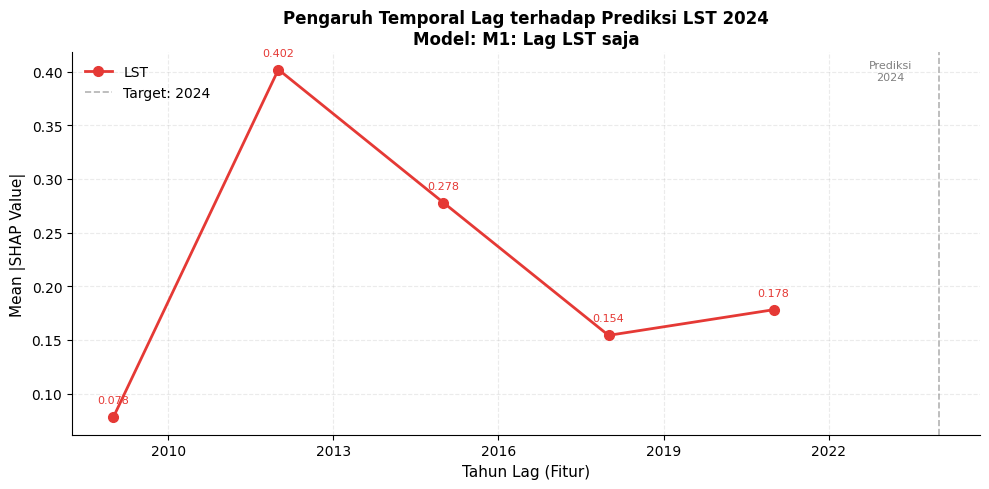

   [M1_LagLST] Lag paling berpengaruh: LST 2012 (mean |SHAP| = 0.4020)
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_temporal_line_M2_LagLST_byCluster.png


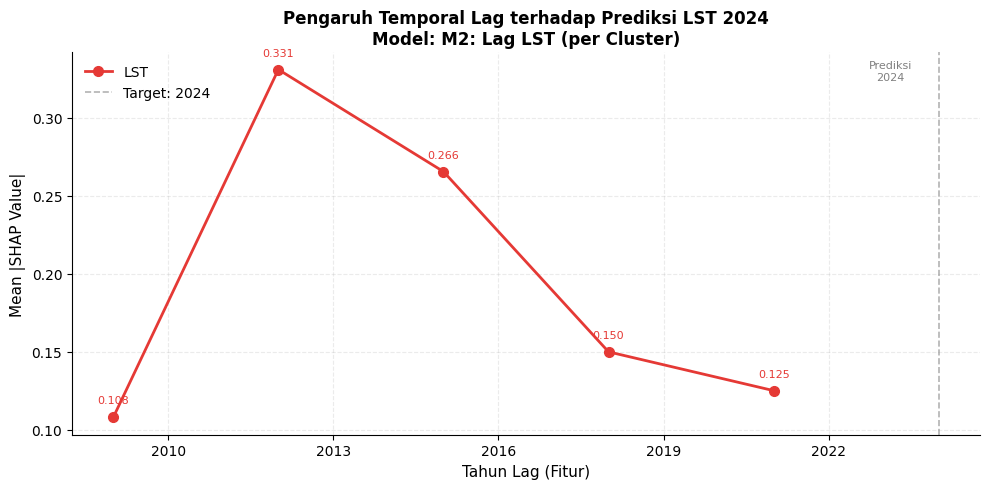

   [M2_LagLST_byCluster] Lag paling berpengaruh: LST 2012 (mean |SHAP| = 0.3311)
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_temporal_line_M3_LagAll.png


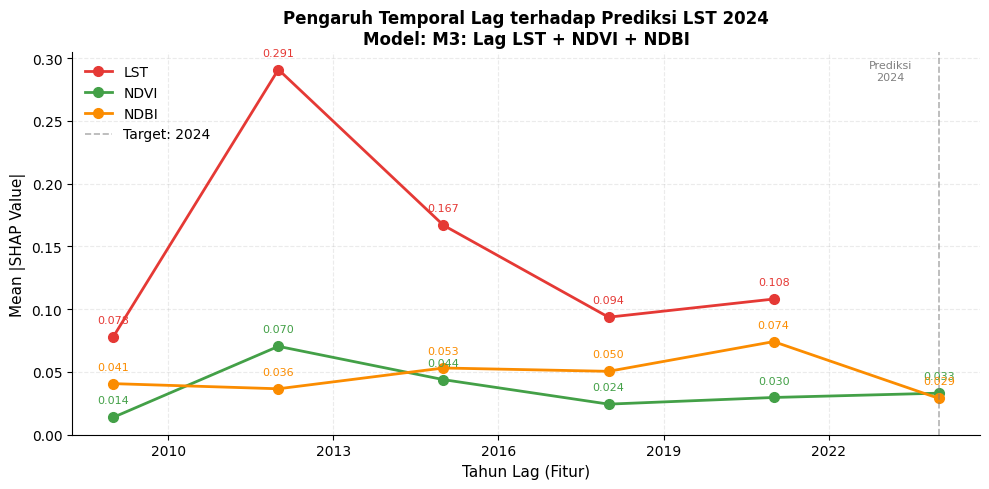

   [M3_LagAll] Lag paling berpengaruh: LST 2012 (mean |SHAP| = 0.2909)
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_temporal_line_M4_LagAll_byCluster.png


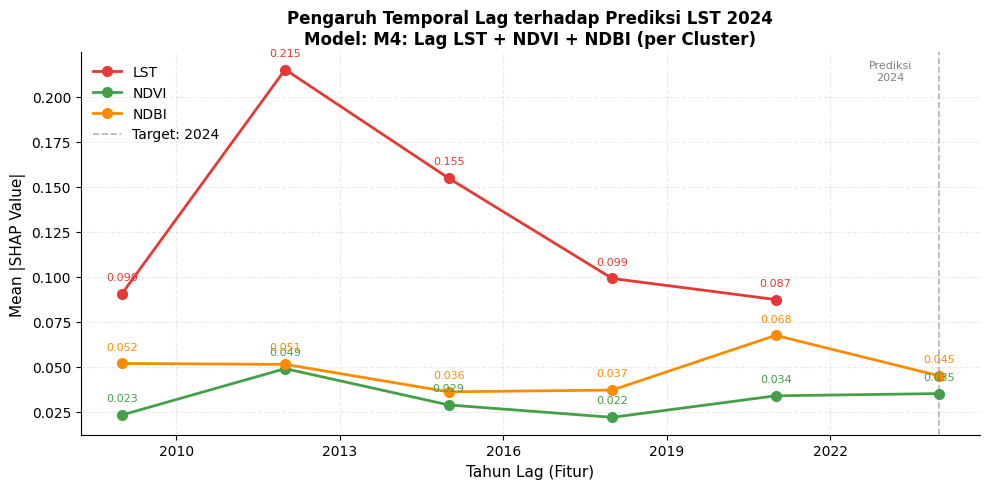

   [M4_LagAll_byCluster] Lag paling berpengaruh: LST 2012 (mean |SHAP| = 0.2153)

🗺️  [2/4] Lag Decay Heatmap (semua model × semua lag year)...
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_lag_decay_heatmap_lst.png


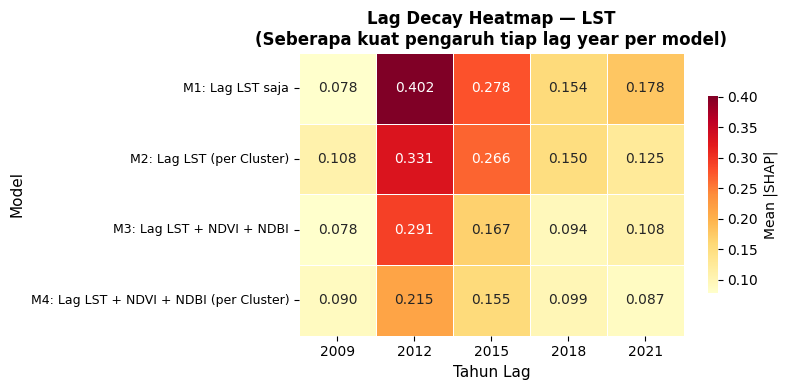

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_lag_decay_heatmap_ndvi.png


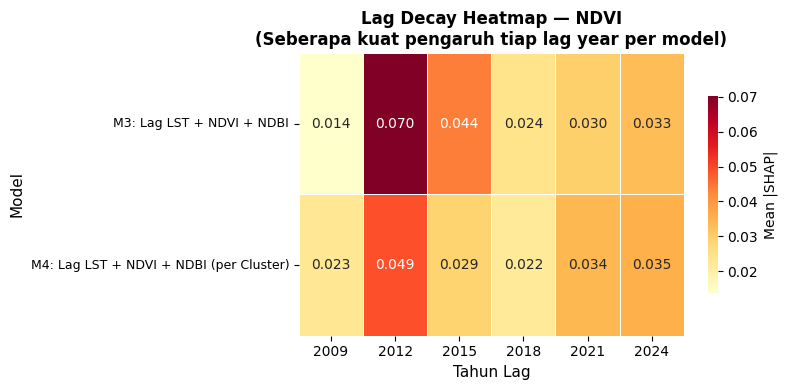


📊 [3/4] SHAP Time-Ordered Bar Plot (urutan waktu, bukan importance)...
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_timeordered_bar_M1_LagLST.png


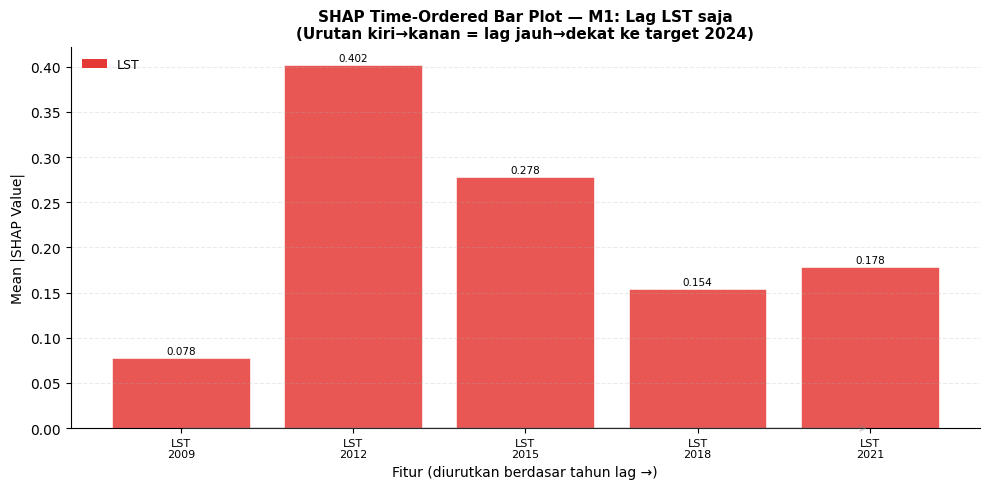

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_timeordered_bar_M2_LagLST_byCluster.png


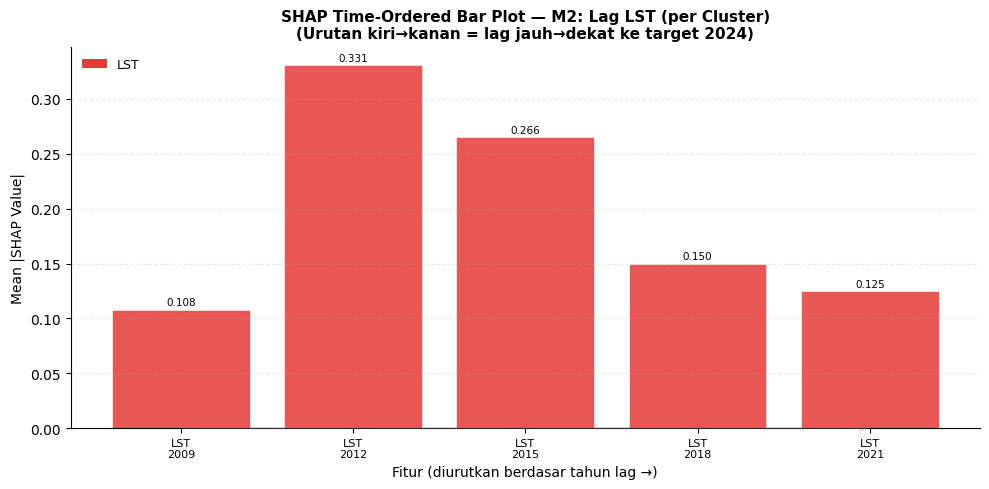

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_timeordered_bar_M3_LagAll.png


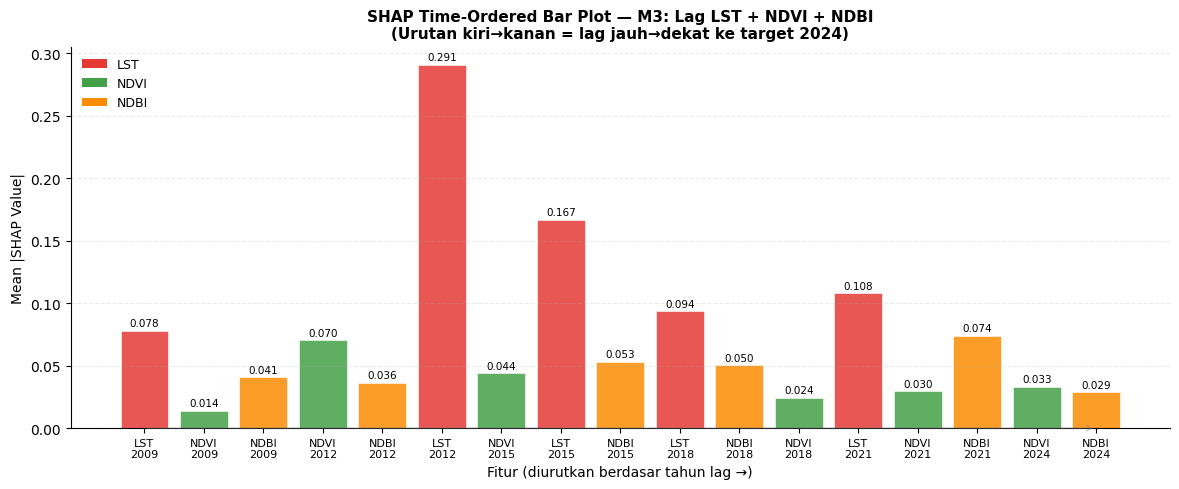

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_timeordered_bar_M4_LagAll_byCluster.png


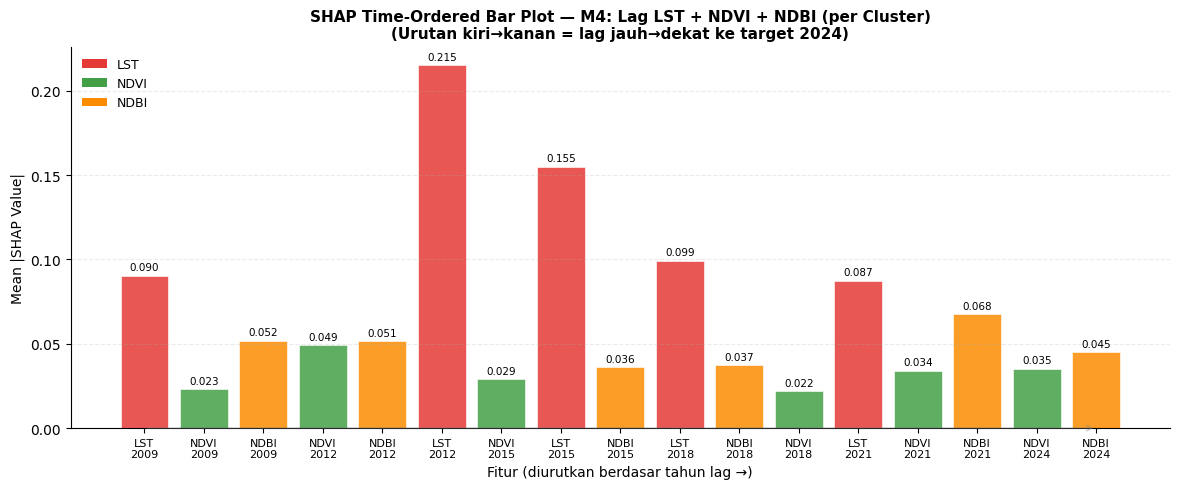


🔍 [4/4] SHAP Temporal per Cluster...
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_temporal_cluster_M2_LagLST_byCluster.png


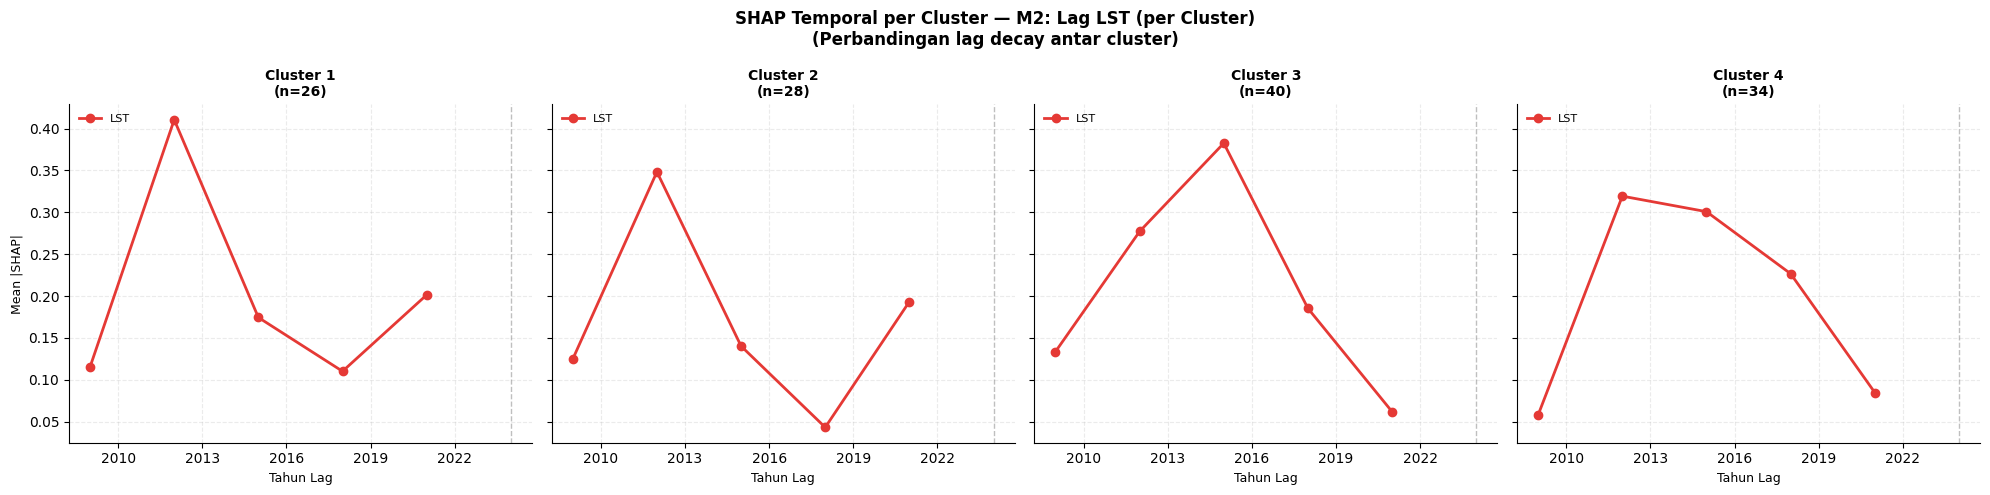

💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_temporal_cluster_M4_LagAll_byCluster.png


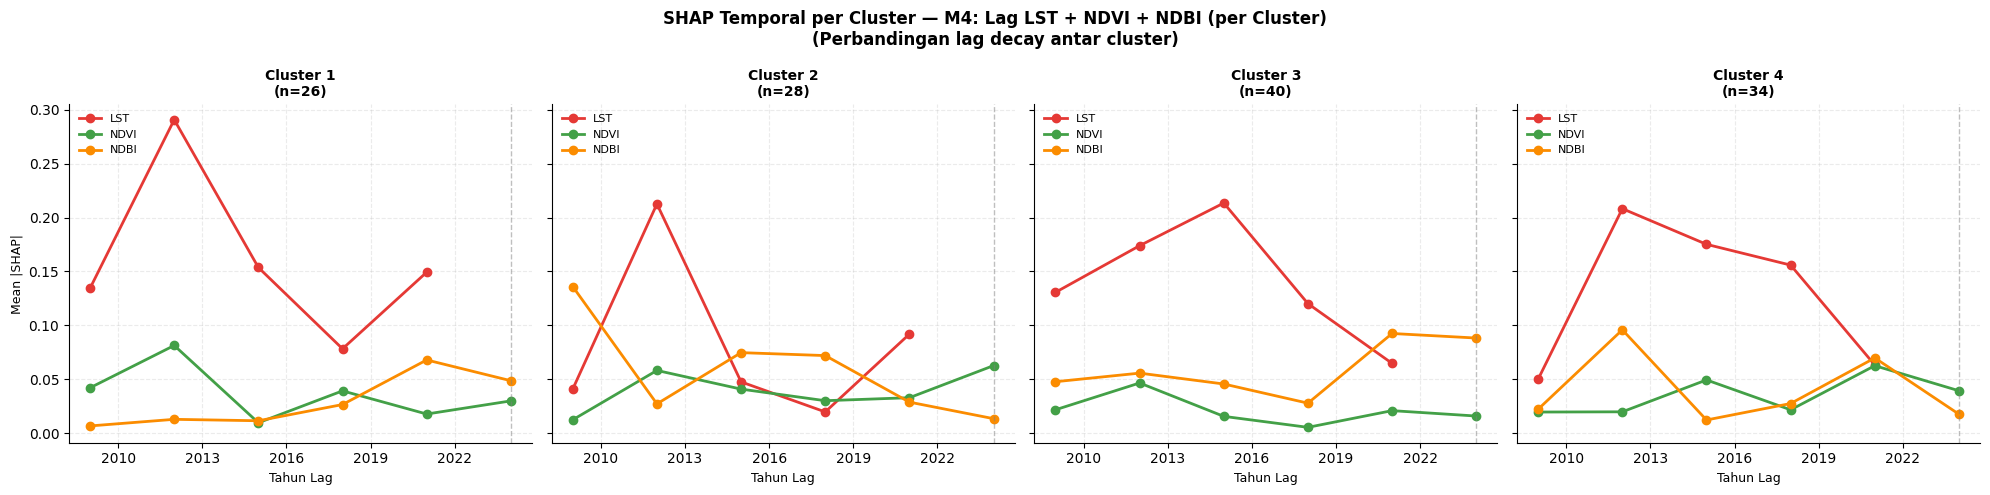


🎯 [Bonus] SHAP vs Nilai Fitur — model terbaik RF...
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_feature_scatter_best_rf.png


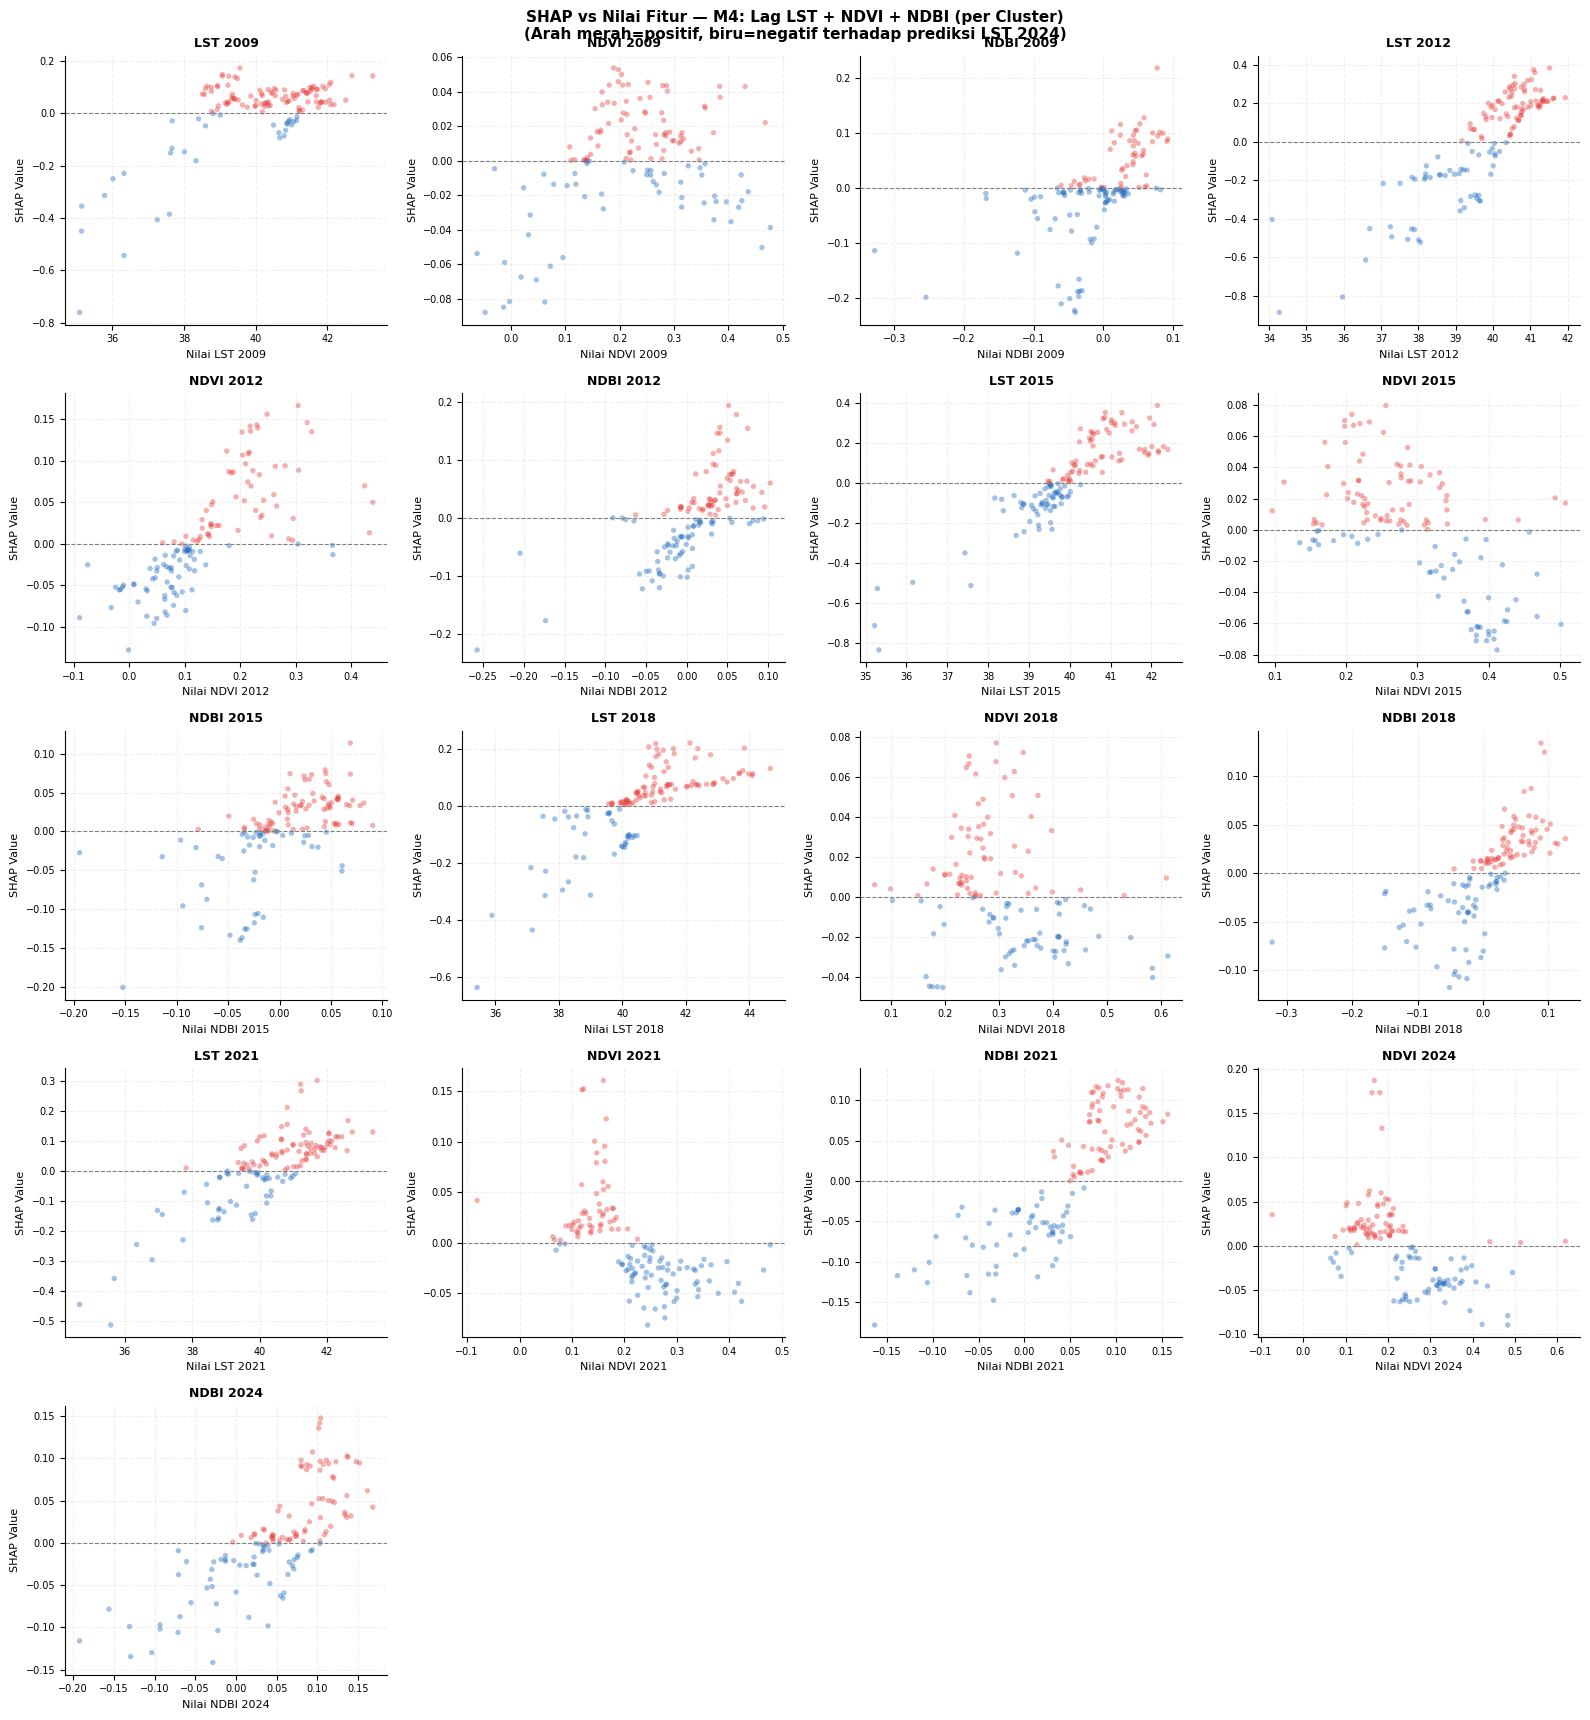


✅ Analisis SHAP Time-Aware selesai!

📋 Cara membaca hasilnya:
  1. shap_temporal_line_*.png  → Lihat apakah garis naik ke kanan
     Jika naik: lag terdekat (2021) paling berpengaruh = short memory
     Jika datar: semua lag sama penting = long memory effect

  2. shap_lag_decay_heatmap_*.png → Sel gelap = lag lebih penting
     Bandingkan antar model: M1 vs M3 dll.

  3. shap_timeordered_bar_*.png → Bar kiri=2009, kanan=2021
     Pola naik ke kanan = recency bias (normal untuk LST)

  4. shap_temporal_cluster_*.png → Apakah cluster perkotaan
     (UHI tinggi) punya decay berbeda vs cluster vegetasi?

  5. shap_feature_scatter_*.png → Titik merah: nilai fitur tinggi
     mendorong prediksi LST 2024 naik (korelasi positif)


In [ ]:
"""
## 🕐 Sel 12b — Analisis SHAP Time-Aware (Time Series Interpretation)

Tujuan: menginterpretasikan SHAP values dengan memperhatikan dimensi waktu dari
fitur lag (lst_2009, lst_2012, ..., lst_2021). Visualisasi ini menjawab pertanyaan:
- Lag tahun mana yang paling berpengaruh terhadap prediksi LST 2024?
- Apakah pengaruh lag melemah semakin jauh ke masa lalu (lag decay)?
- Apakah pola ini konsisten di semua model dan cluster?
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI UTILITAS: ekstrak tahun dari nama fitur
# ─────────────────────────────────────────────────────────────────────────────

def extract_year(feat_name: str):
    """
    Ekstrak tahun dari nama fitur seperti 'lst_2021', 'ndvi2015', 'ndbi_2018'.
    Mengembalikan int tahun atau None jika tidak ditemukan.
    """
    match = re.search(r'(19|20)\d{2}', feat_name)
    return int(match.group()) if match else None


def get_var_type(feat_name: str) -> str:
    """Klasifikasi jenis variabel: LST, NDVI, NDBI, atau LAINNYA."""
    fn = feat_name.upper().replace('_', '').replace('-', '')
    for vtype in ['NDBI', 'NDVI', 'LST']:
        if fn.startswith(vtype):
            return vtype
    return 'LAINNYA'


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 1: Temporal SHAP Line Plot
# Menunjukkan mean |SHAP| per lag year → tampak sebagai garis waktu
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_temporal(shap_values, feature_names, model_label,
                       target_year=2024, save_path=None):
    """
    Plot mean |SHAP| sebagai garis temporal per jenis variabel (LST, NDVI, NDBI).

    Parameter
    ---------
    shap_values    : np.ndarray, shape (n_samples, n_features)
    feature_names  : list[str]
    model_label    : str, judul plot
    target_year    : int, tahun prediksi (untuk sumbu x)
    save_path      : str atau None
    """
    # Hitung mean |SHAP| per fitur
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # Bangun DataFrame: fitur → tahun + jenis variabel + shap
    records = []
    for feat, shap_val in zip(feature_names, mean_abs_shap):
        year = extract_year(feat)
        vtype = get_var_type(feat)
        if year is not None:
            records.append({'feature': feat, 'year': year,
                            'vtype': vtype, 'mean_abs_shap': shap_val})

    df_temp = pd.DataFrame(records).sort_values('year')

    if df_temp.empty:
        print(f"[PERINGATAN] Tidak ada fitur bertahun di model '{model_label}'")
        return

    # Warna per jenis variabel
    color_map = {'LST': '#e53935', 'NDVI': '#43a047',
                 'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

    vtypes = df_temp['vtype'].unique()
    fig, ax = plt.subplots(figsize=(10, 5))

    for vtype in vtypes:
        sub = df_temp[df_temp['vtype'] == vtype].copy()
        color = color_map.get(vtype, '#9e9e9e')
        ax.plot(sub['year'], sub['mean_abs_shap'],
                marker='o', linewidth=2, markersize=7,
                color=color, label=vtype)
        # Anotasi nilai di tiap titik
        for _, row in sub.iterrows():
            ax.annotate(f"{row['mean_abs_shap']:.3f}",
                        xy=(row['year'], row['mean_abs_shap']),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=8, color=color)

    # Garis vertikal: target year
    ax.axvline(x=target_year, color='gray', linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Target: {target_year}')
    ax.annotate(f'Prediksi\n{target_year}',
                xy=(target_year, ax.get_ylim()[1]),
                xytext=(-35, -20), textcoords='offset points',
                fontsize=8, color='gray', ha='center')

    ax.set_xlabel('Tahun Lag (Fitur)', fontsize=11)
    ax.set_ylabel('Mean |SHAP Value|', fontsize=11)
    ax.set_title(f'Pengaruh Temporal Lag terhadap Prediksi LST {target_year}\n'
                 f'Model: {model_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, frameon=False)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
    ax.grid(axis='both', alpha=0.25, linestyle='--')
    sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_temp


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 2: Lag Decay Heatmap
# Menampilkan mean |SHAP| per (model × lag year) sebagai heatmap
# Cocok untuk membandingkan semua model sekaligus
# ─────────────────────────────────────────────────────────────────────────────

def plot_lag_decay_heatmap(shap_store, model_configs, cfg_keys,
                           var_filter='LST', save_path=None):
    """
    Heatmap mean |SHAP| dengan baris = model, kolom = tahun lag.
    Memudahkan perbandingan lag decay antar model.

    Parameter
    ---------
    shap_store    : dict dari shap_store[(cfg_key, 'RF')]
    model_configs : dict MODEL_CONFIGS
    cfg_keys      : list urutan model
    var_filter    : 'LST', 'NDVI', 'NDBI', atau None (semua)
    save_path     : str atau None
    """
    all_years = set()
    rows_data = {}

    for cfg_key in cfg_keys:
        if (cfg_key, 'RF') not in shap_store:
            continue
        store = shap_store[(cfg_key, 'RF')]
        sv = store['sv']
        feats = store['feats']
        mean_abs = np.abs(sv).mean(axis=0)

        row = {}
        for feat, shap_val in zip(feats, mean_abs):
            year = extract_year(feat)
            vtype = get_var_type(feat)
            if year is None:
                continue
            if var_filter and vtype != var_filter:
                continue
            # Jika ada beberapa fitur per tahun (misal ndvi+ndbi), ambil max
            row[year] = max(row.get(year, 0), shap_val)
            all_years.add(year)

        label = model_configs[cfg_key]['label']
        rows_data[label] = row

    if not rows_data:
        print("[PERINGATAN] Tidak ada data untuk heatmap.")
        return

    sorted_years = sorted(all_years)
    df_heat = pd.DataFrame(rows_data).T.reindex(columns=sorted_years)

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_years) * 1.2),
                                     max(4, len(rows_data) * 0.9)))

    sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Mean |SHAP|', 'shrink': 0.7},
                ax=ax)

    var_label = var_filter if var_filter else 'Semua Variabel'
    ax.set_title(f'Lag Decay Heatmap — {var_label}\n'
                 f'(Seberapa kuat pengaruh tiap lag year per model)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahun Lag', fontsize=11)
    ax.set_ylabel('Model', fontsize=11)
    ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 3: SHAP Temporal Bar Plot dengan Urutan Waktu (bukan urutan importance)
# Ini pengganti shap_bar_rf yang sudah ada, tapi sumbu X diurutkan berdasar tahun
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_bar_by_time(shap_values, feature_names, model_label,
                          save_path=None):
    """
    Bar plot mean |SHAP| dengan fitur diurutkan berdasar tahun (kiri=lama, kanan=baru).
    Berbeda dari standard bar plot yang diurutkan berdasar importance.
    Ini memperlihatkan 'memory effect' secara visual.

    Parameter
    ---------
    shap_values   : np.ndarray, shape (n_samples, n_features)
    feature_names : list[str]
    model_label   : str
    save_path     : str atau None
    """
    mean_abs = np.abs(shap_values).mean(axis=0)
    color_map = {'LST': '#e53935', 'NDVI': '#43a047',
                 'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

    records = []
    for feat, shap_val in zip(feature_names, mean_abs):
        year = extract_year(feat)
        vtype = get_var_type(feat)
        records.append({
            'feature': feat,
            'year': year if year else 0,
            'vtype': vtype,
            'mean_abs_shap': shap_val,
            'label': f"{vtype}\n{year}" if year else feat
        })

    df = pd.DataFrame(records).sort_values('year')
    colors = [color_map.get(r['vtype'], '#9e9e9e') for _, r in df.iterrows()]

    fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.7), 5))
    bars = ax.bar(range(len(df)), df['mean_abs_shap'],
                  color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Anotasi nilai di atas bar
    for i, (bar, val) in enumerate(zip(bars, df['mean_abs_shap'])):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['label'], fontsize=8, rotation=0)
    ax.set_xlabel('Fitur (diurutkan berdasar tahun lag →)', fontsize=10)
    ax.set_ylabel('Mean |SHAP Value|', fontsize=10)
    ax.set_title(f'SHAP Time-Ordered Bar Plot — {model_label}\n'
                 f'(Urutan kiri→kanan = lag jauh→dekat ke target 2024)',
                 fontsize=11, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    used = list(dict.fromkeys(r['vtype'] for _, r in df.iterrows()))
    legend_handles = [Patch(facecolor=color_map.get(v, '#9e9e9e'), label=v)
                      for v in used]
    ax.legend(handles=legend_handles, fontsize=9, frameon=False, loc='upper left')

    # Panah tren (opsional: tandai lag terdekat vs terjauh)
    if len(df) >= 2:
        ax.annotate('', xy=(len(df) - 1, 0), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='gray',
                                   lw=1, alpha=0.4))

    ax.grid(axis='y', alpha=0.25, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 4: SHAP Temporal per Cluster (untuk model split_by_cluster)
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_temporal_per_cluster(all_results, cfg_key, model_configs,
                                   clusters, target_year=2024,
                                   save_path=None):
    """
    Untuk model split_by_cluster (M2, M4): plot mean |SHAP| per tahun
    untuk setiap cluster dalam satu figure.
    Memperlihatkan apakah lag decay berbeda antar cluster (tipe lahan).

    Parameter
    ---------
    all_results   : dict all_results dari training
    cfg_key       : str, misal 'M2_LagLST_byCluster'
    model_configs : dict MODEL_CONFIGS
    clusters      : list cluster IDs
    target_year   : int
    save_path     : str atau None
    """
    res = all_results[(cfg_key, 'RF')]
    feats = res['features']
    cl_models = res['cluster_models']
    color_map = {'LST': '#e53935', 'NDVI': '#43a047',
                 'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

    n_cl = len(clusters)
    fig, axes = plt.subplots(1, n_cl, figsize=(5 * n_cl, 5), sharey=True)
    if n_cl == 1:
        axes = [axes]

    fig.suptitle(f'SHAP Temporal per Cluster — {model_configs[cfg_key]["label"]}\n'
                 f'(Perbandingan lag decay antar cluster)',
                 fontsize=12, fontweight='bold')

    all_df = {}

    for ax, cl in zip(axes, clusters):
        m = cl_models[cl]['RF']
        X_te = res['cluster_X_test'][cl]

        # Hitung SHAP untuk cluster ini
        explainer = shap.TreeExplainer(m)
        sv_cl = explainer.shap_values(X_te)
        mean_abs_cl = np.abs(sv_cl).mean(axis=0)

        records = []
        for feat, shap_val in zip(feats, mean_abs_cl):
            year = extract_year(feat)
            vtype = get_var_type(feat)
            if year:
                records.append({'year': year, 'vtype': vtype,
                                'mean_abs_shap': shap_val})

        df_cl = pd.DataFrame(records).sort_values('year')
        all_df[cl] = df_cl

        for vtype in df_cl['vtype'].unique():
            sub = df_cl[df_cl['vtype'] == vtype]
            color = color_map.get(vtype, '#9e9e9e')
            ax.plot(sub['year'], sub['mean_abs_shap'],
                    marker='o', linewidth=2, markersize=6,
                    color=color, label=vtype)

        ax.axvline(x=target_year, color='gray', linestyle='--',
                   linewidth=1, alpha=0.5)
        n_te = len(X_te)
        ax.set_title(f'Cluster {int(cl)}\n(n={n_te})',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Tahun Lag', fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel('Mean |SHAP|', fontsize=9)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax.grid(alpha=0.25, linestyle='--')
        ax.legend(fontsize=8, frameon=False)
        sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return all_df


# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI 5: Lag Correlation Matrix
# Tambahan: korelasi temporal antara SHAP fitur dan nilai fitur itu sendiri
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_feature_correlation(shap_values, feature_names, X_test,
                                  model_label, save_path=None):
    """
    Scatter plot SHAP value vs nilai fitur untuk setiap fitur bertahun.
    Memperlihatkan arah pengaruh: apakah LST tinggi di tahun X mendorong
    prediksi LST 2024 naik atau turun?

    Parameter
    ---------
    shap_values   : np.ndarray, shape (n_samples, n_features)
    feature_names : list[str]
    X_test        : np.ndarray, shape (n_samples, n_features)
    model_label   : str
    save_path     : str atau None
    """
    # Filter hanya fitur bertahun
    timed_feats = [(i, f) for i, f in enumerate(feature_names)
                   if extract_year(f) is not None]

    if not timed_feats:
        print("[PERINGATAN] Tidak ada fitur bertahun untuk scatter plot.")
        return

    n_feats = len(timed_feats)
    n_cols = min(4, n_feats)
    n_rows = int(np.ceil(n_feats / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3.5 * n_rows))
    axes_flat = axes.flatten() if n_feats > 1 else [axes]

    fig.suptitle(f'SHAP vs Nilai Fitur — {model_label}\n'
                 f'(Arah merah=positif, biru=negatif terhadap prediksi LST 2024)',
                 fontsize=11, fontweight='bold')

    # Urutkan berdasar tahun
    timed_feats_sorted = sorted(timed_feats, key=lambda x: extract_year(x[1]))

    for ax, (feat_idx, feat_name) in zip(axes_flat, timed_feats_sorted):
        sv_col = shap_values[:, feat_idx]
        feat_vals = X_test[:, feat_idx]
        year = extract_year(feat_name)
        vtype = get_var_type(feat_name)

        # Warna titik berdasar arah SHAP (merah=positif, biru=negatif)
        colors_scatter = ['#e53935' if s > 0 else '#1565c0' for s in sv_col]

        ax.scatter(feat_vals, sv_col, c=colors_scatter,
                   alpha=0.4, s=15, edgecolors='none')
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_title(f'{vtype} {year}', fontsize=9, fontweight='bold')
        ax.set_xlabel(f'Nilai {vtype} {year}', fontsize=8)
        ax.set_ylabel('SHAP Value', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    # Sembunyikan panel kosong
    for ax in axes_flat[len(timed_feats_sorted):]:
        ax.set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# EKSEKUSI: Jalankan semua analisis SHAP time-aware
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('🕐 Memulai Analisis SHAP Time-Aware')
print('=' * 60)

# ── (1) Temporal SHAP Line Plot untuk setiap model ────────────────────────
print('\n📈 [1/4] Temporal SHAP Line Plot (per model)...')

for cfg_key in cfg_keys:
    if (cfg_key, 'RF') not in shap_store:
        continue
    store = shap_store[(cfg_key, 'RF')]
    model_lbl = MODEL_CONFIGS[cfg_key]['label']

    df_temp = plot_shap_temporal(
        shap_values=store['sv'],
        feature_names=store['feats'],
        model_label=model_lbl,
        target_year=TARGET_YEAR,
        save_path=OUTPUT_DIR + f'shap_temporal_line_{cfg_key}.png'
    )

    # Cetak ringkasan: lag mana yang paling dominan
    if df_temp is not None and not df_temp.empty:
        top_row = df_temp.loc[df_temp['mean_abs_shap'].idxmax()]
        print(f'   [{cfg_key}] Lag paling berpengaruh: '
              f'{top_row["vtype"]} {int(top_row["year"])} '
              f'(mean |SHAP| = {top_row["mean_abs_shap"]:.4f})')

# ── (2) Lag Decay Heatmap ─────────────────────────────────────────────────
print('\n🗺️  [2/4] Lag Decay Heatmap (semua model × semua lag year)...')

# Heatmap untuk fitur LST
plot_lag_decay_heatmap(
    shap_store=shap_store,
    model_configs=MODEL_CONFIGS,
    cfg_keys=cfg_keys,
    var_filter='LST',
    save_path=OUTPUT_DIR + 'shap_lag_decay_heatmap_lst.png'
)

# Heatmap untuk NDVI (jika ada di model M3/M4)
ndvi_cfg_keys = [k for k in cfg_keys
                 if any('ndvi' in f.lower() for f in MODEL_CONFIGS[k]['features'])]
if ndvi_cfg_keys:
    plot_lag_decay_heatmap(
        shap_store=shap_store,
        model_configs=MODEL_CONFIGS,
        cfg_keys=ndvi_cfg_keys,
        var_filter='NDVI',
        save_path=OUTPUT_DIR + 'shap_lag_decay_heatmap_ndvi.png'
    )

# ── (3) Time-Ordered Bar Plot ────────────────────────────────────────────
print('\n📊 [3/4] SHAP Time-Ordered Bar Plot (urutan waktu, bukan importance)...')

for cfg_key in cfg_keys:
    if (cfg_key, 'RF') not in shap_store:
        continue
    store = shap_store[(cfg_key, 'RF')]
    model_lbl = MODEL_CONFIGS[cfg_key]['label']

    plot_shap_bar_by_time(
        shap_values=store['sv'],
        feature_names=store['feats'],
        model_label=model_lbl,
        save_path=OUTPUT_DIR + f'shap_timeordered_bar_{cfg_key}.png'
    )

# ── (4) SHAP Temporal per Cluster (model split_by_cluster) ───────────────
print('\n🔍 [4/4] SHAP Temporal per Cluster...')

cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']]
for cfg_key in cluster_cfg_keys:
    plot_shap_temporal_per_cluster(
        all_results=all_results,
        cfg_key=cfg_key,
        model_configs=MODEL_CONFIGS,
        clusters=clusters,
        target_year=TARGET_YEAR,
        save_path=OUTPUT_DIR + f'shap_temporal_cluster_{cfg_key}.png'
    )

# ── (5) SHAP vs Nilai Fitur (scatter arah pengaruh) ──────────────────────
print('\n🎯 [Bonus] SHAP vs Nilai Fitur — model terbaik RF...')

best_store = shap_store[(best_cfg_key_rf, 'RF')]
X_te_best_arr = best_store['X']

plot_shap_feature_correlation(
    shap_values=best_store['sv'],
    feature_names=best_store['feats'],
    X_test=X_te_best_arr,
    model_label=MODEL_CONFIGS[best_cfg_key_rf]['label'],
    save_path=OUTPUT_DIR + 'shap_feature_scatter_best_rf.png'
)

print('\n' + '=' * 60)
print('✅ Analisis SHAP Time-Aware selesai!')
print('=' * 60)
print('\n📋 Cara membaca hasilnya:')
print('  1. shap_temporal_line_*.png  → Lihat apakah garis naik ke kanan')
print('     Jika naik: lag terdekat (2021) paling berpengaruh = short memory')
print('     Jika datar: semua lag sama penting = long memory effect')
print()
print('  2. shap_lag_decay_heatmap_*.png → Sel gelap = lag lebih penting')
print('     Bandingkan antar model: M1 vs M3 dll.')
print()
print('  3. shap_timeordered_bar_*.png → Bar kiri=2009, kanan=2021')
print('     Pola naik ke kanan = recency bias (normal untuk LST)')
print()
print('  4. shap_temporal_cluster_*.png → Apakah cluster perkotaan')
print('     (UHI tinggi) punya decay berbeda vs cluster vegetasi?')
print()
print('  5. shap_feature_scatter_*.png → Titik merah: nilai fitur tinggi')
print('     mendorong prediksi LST 2024 naik (korelasi positif)')

  BLOK 1 — Menghitung SHAP Values (RF, semua konfigurasi)
  ✓ M1: Lag LST saja | X_test=(128, 5)
  ✓ M2: Lag LST (per Cluster) (per cluster) | sv_total=(128, 5)
  ✓ M3: Lag LST + NDVI + NDBI | X_test=(128, 17)
  ✓ M4: Lag LST + NDVI + NDBI (per Cluster) (per cluster) | sv_total=(128, 17)

✅ SHAP values berhasil dihitung untuk semua konfigurasi RF.

  BLOK 2 — SHAP Summary (Beeswarm) per Konfigurasi


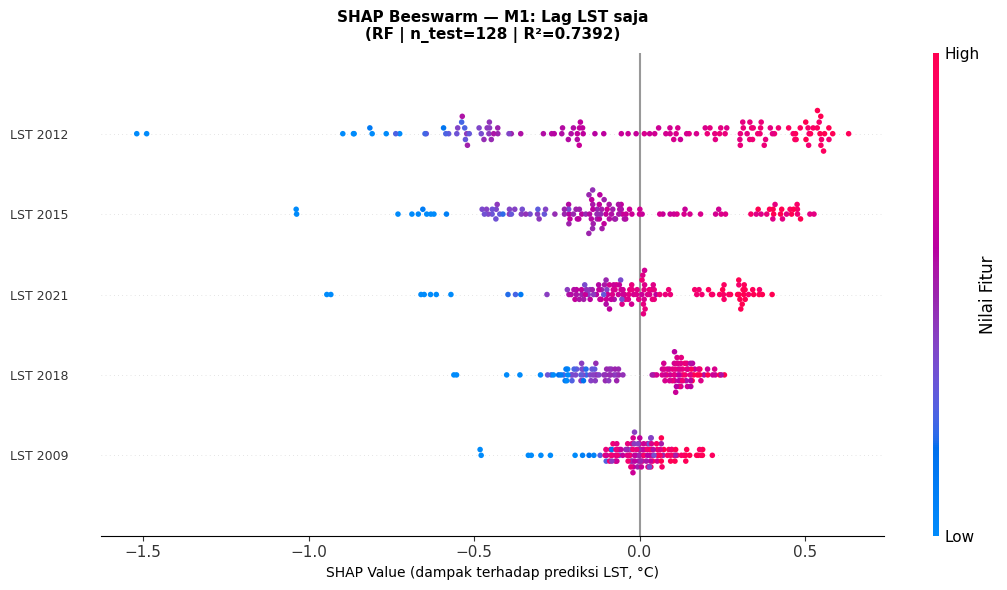

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_rf_M1_LagLST.png


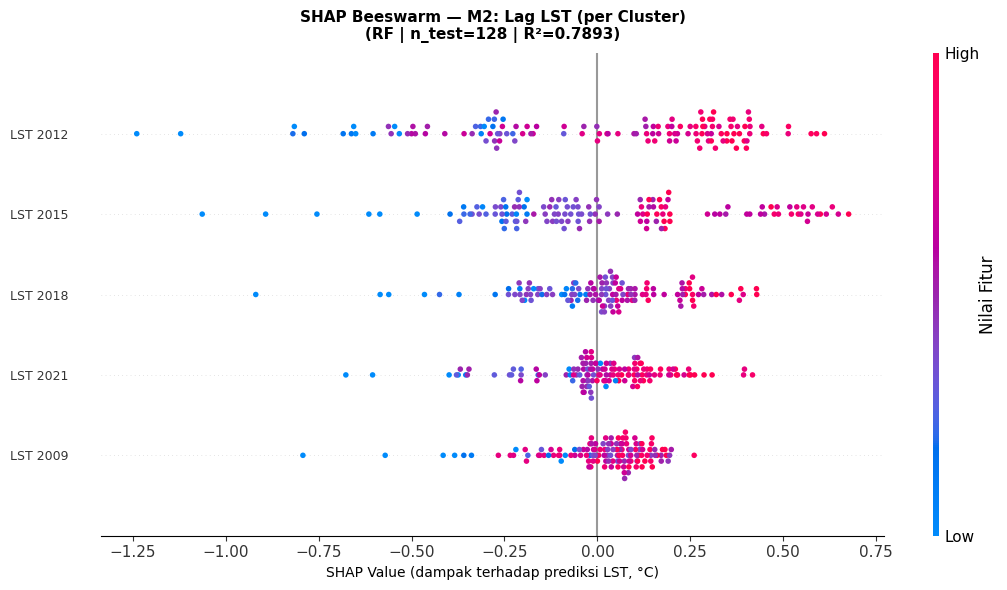

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_rf_M2_LagLST_byCluster.png


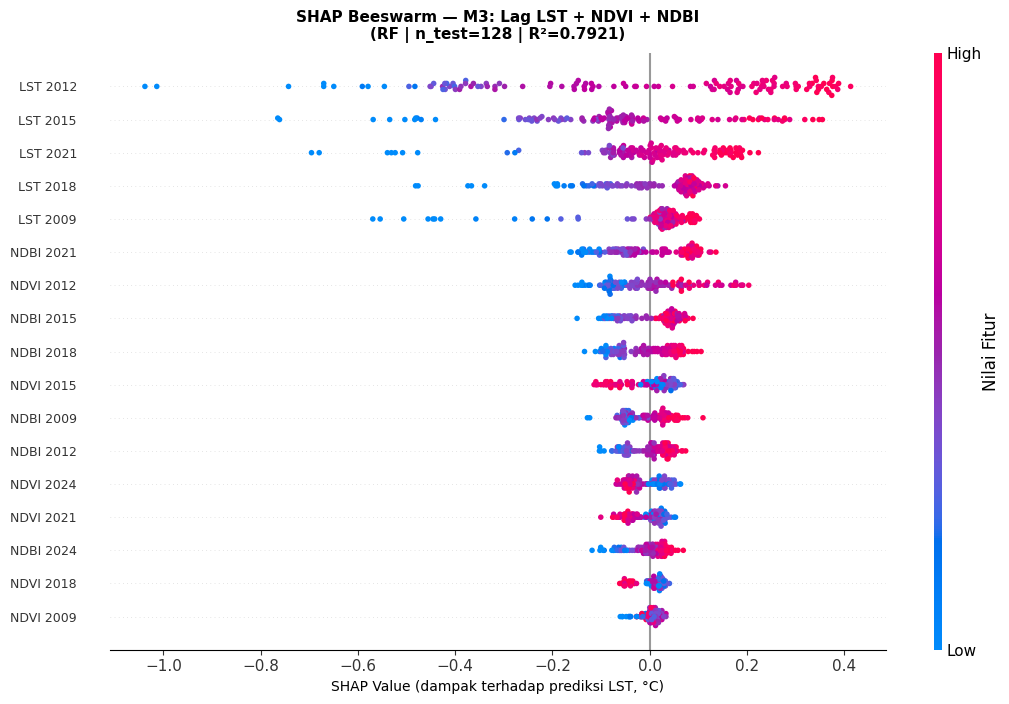

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_rf_M3_LagAll.png


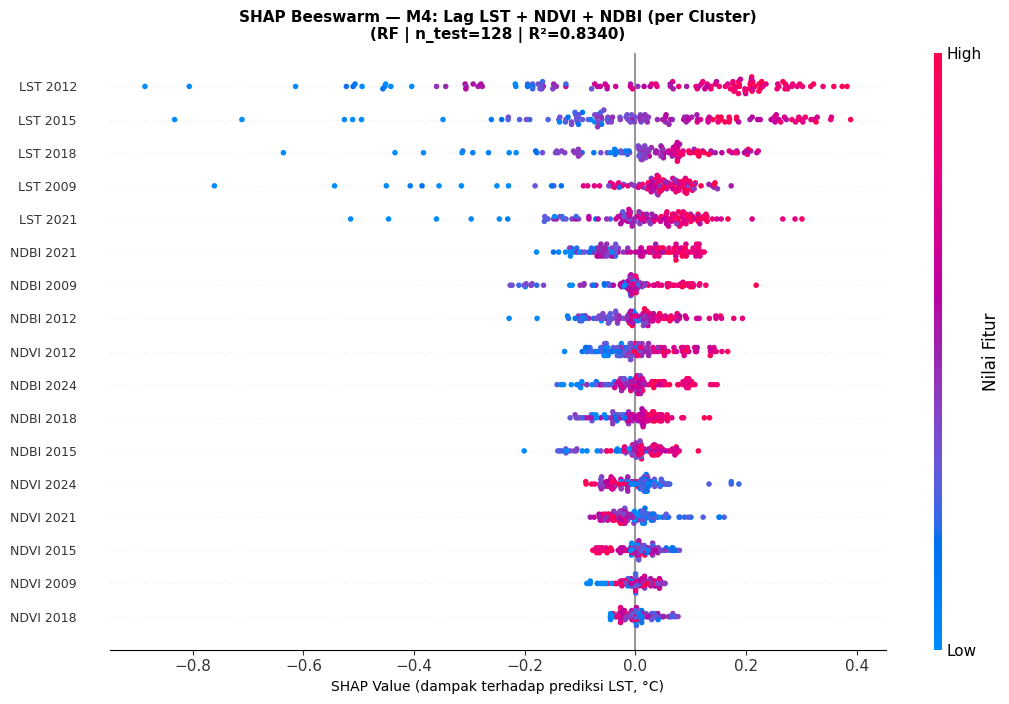

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_beeswarm_rf_M4_LagAll_byCluster.png

  BLOK 3 — SHAP Bar Chart (Mean |SHAP|) per Konfigurasi


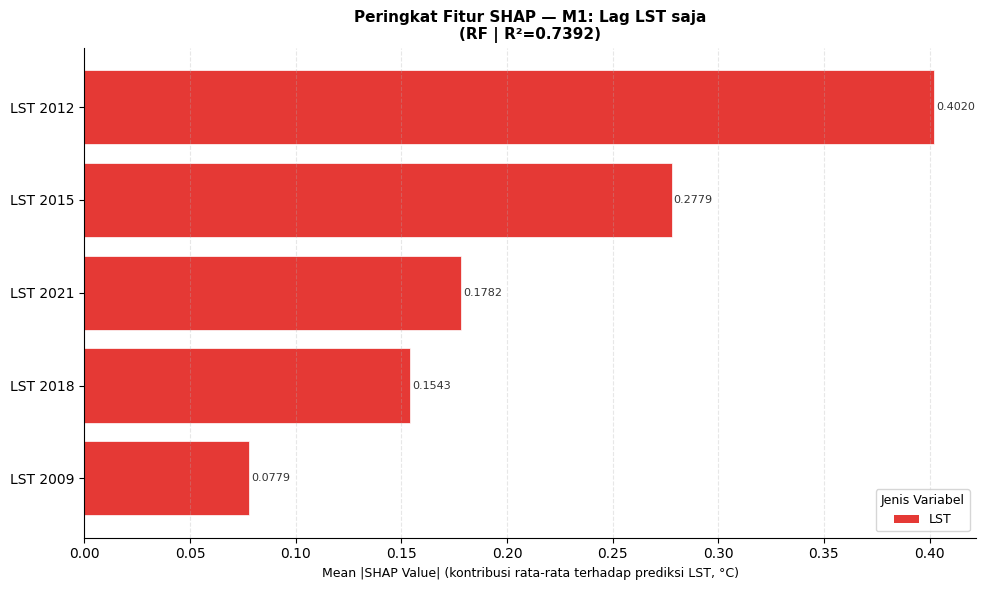

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_bar_rf_M1_LagLST.png


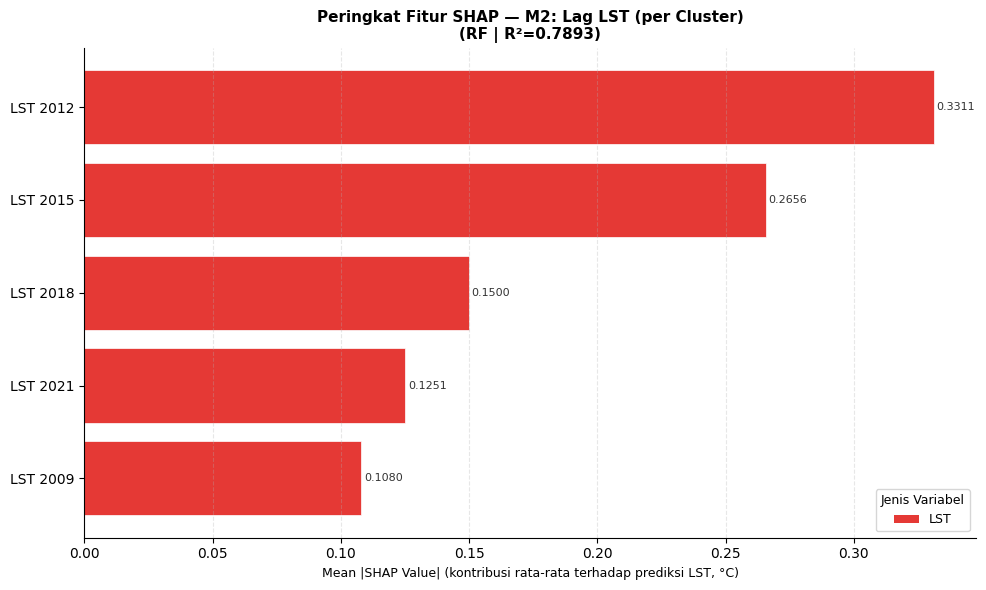

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_bar_rf_M2_LagLST_byCluster.png


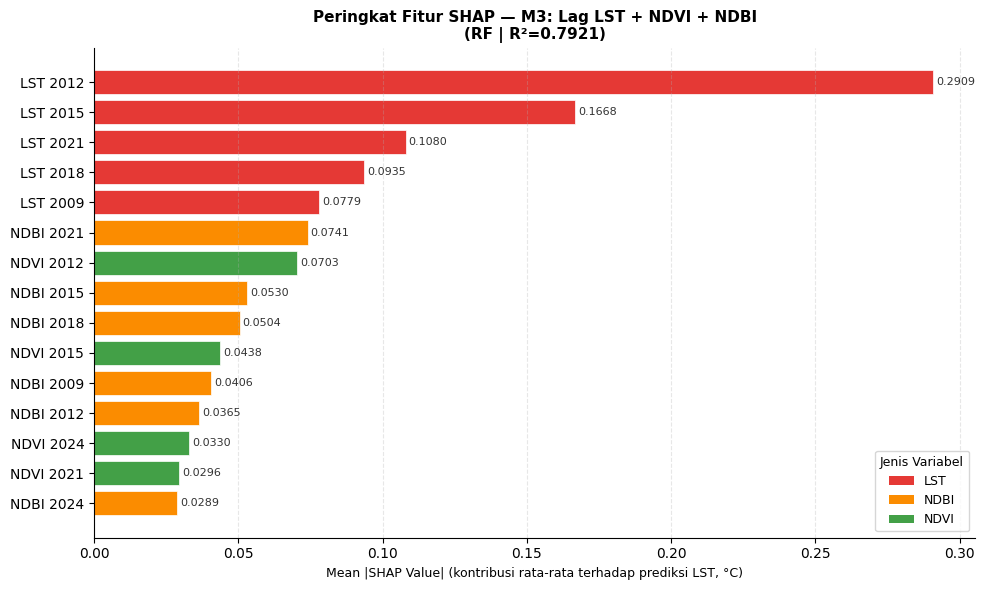

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_bar_rf_M3_LagAll.png


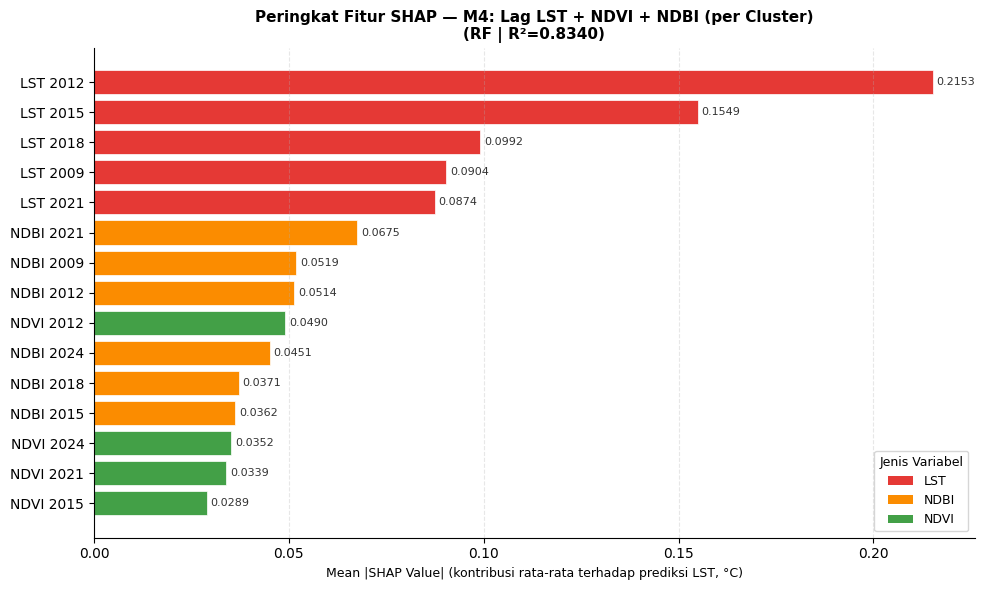

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_bar_rf_M4_LagAll_byCluster.png

  BLOK 4 — SHAP Lag-Profile per Variabel (INTI METODOLOGI)
  Model terbaik RF: M4: Lag LST + NDVI + NDBI (per Cluster)

  Tabel Mean |SHAP| per variabel per tahun:


Type,LST,NDBI,NDVI
Year,,,
2009,0.0904,0.0519,0.0232
2012,0.2153,0.0514,0.0490
2015,0.1549,0.0362,0.0289
2018,0.0992,0.0371,0.0220
2021,0.0874,0.0675,0.0339
2024,NaN,0.0451,0.0352


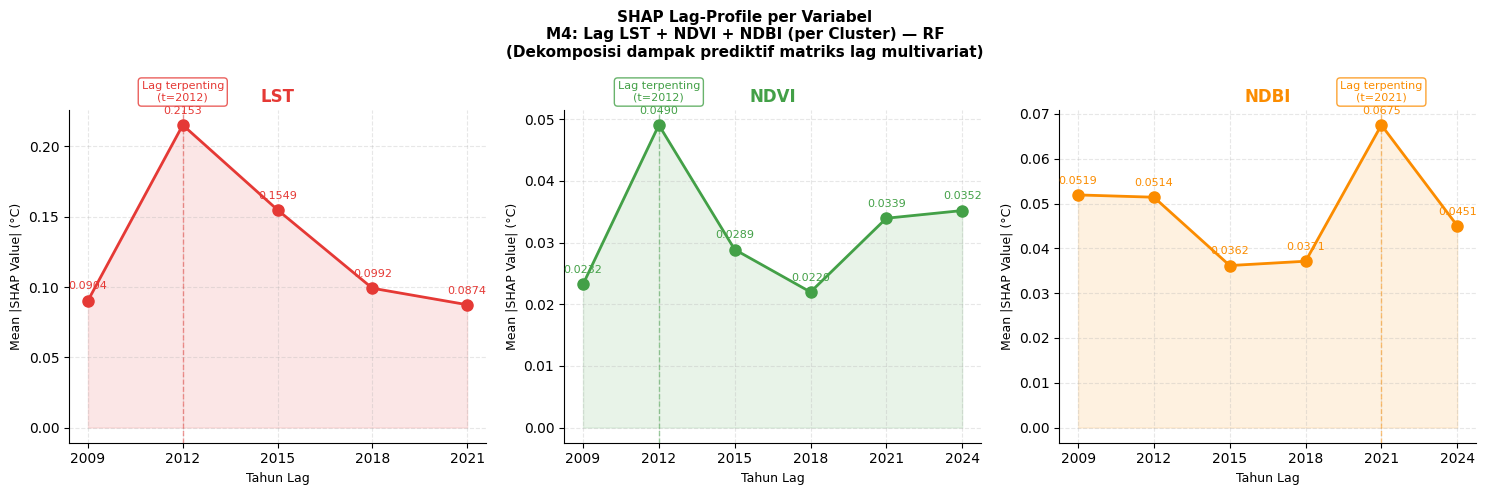

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_lag_profile_M4_LagAll_byCluster.png


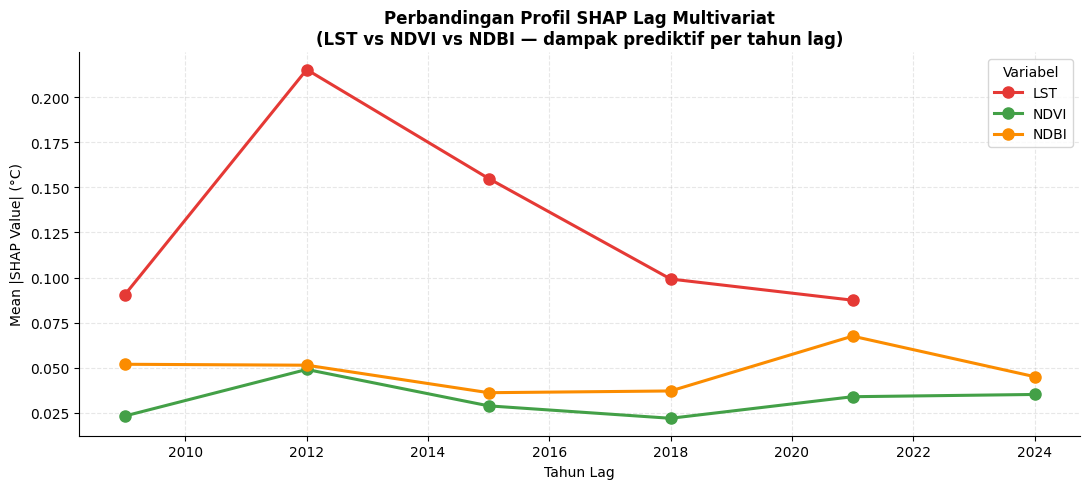

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_lag_profile_komparatif_M4_LagAll_byCluster.png
  💾 CSV: /content/drive/MyDrive/Data Skripsi/output/regression/shap_lag_profile_M4_LagAll_byCluster.csv

  BLOK 5 — SHAP Dependence Plot (Top 4 Fitur)


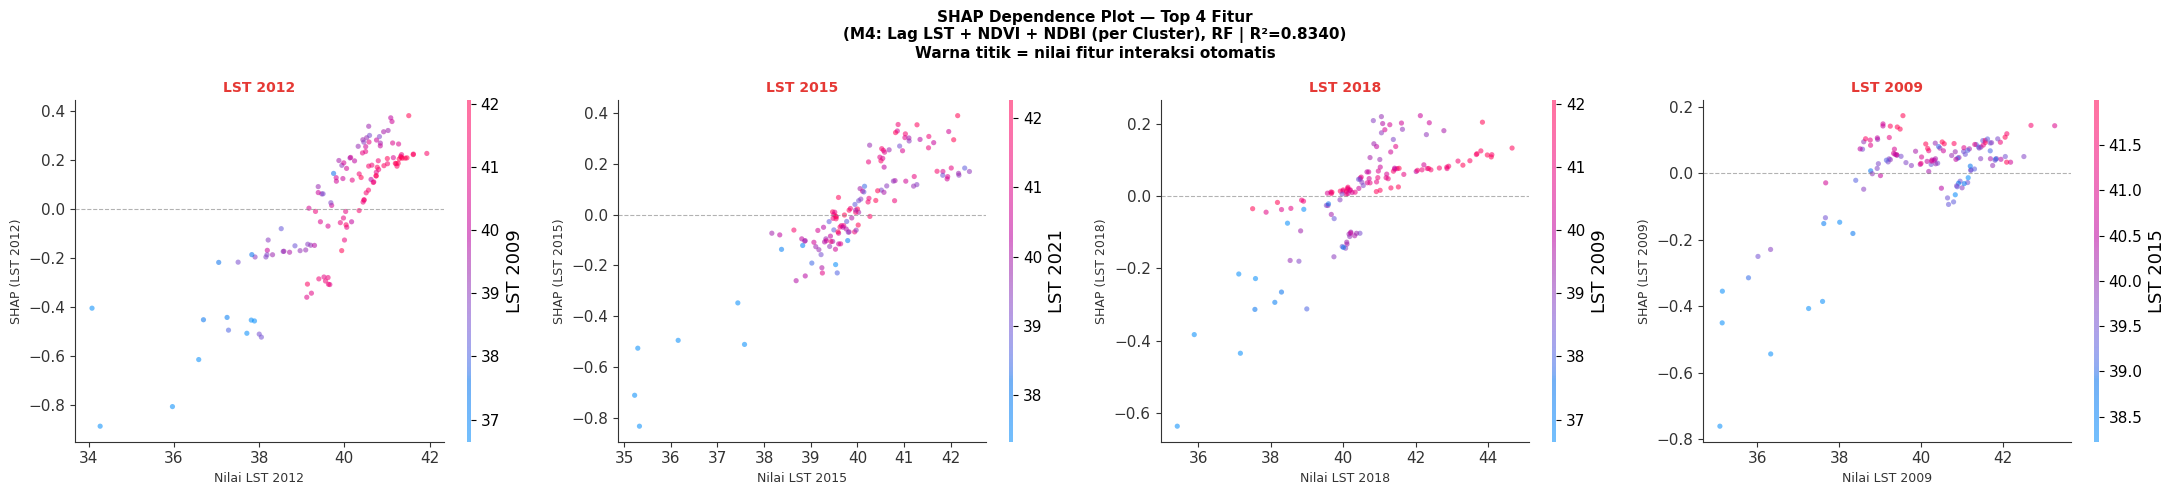

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_dependence_top4_M4_LagAll_byCluster.png

  BLOK 6 — SHAP Waterfall (3 Sampel Tipikal)


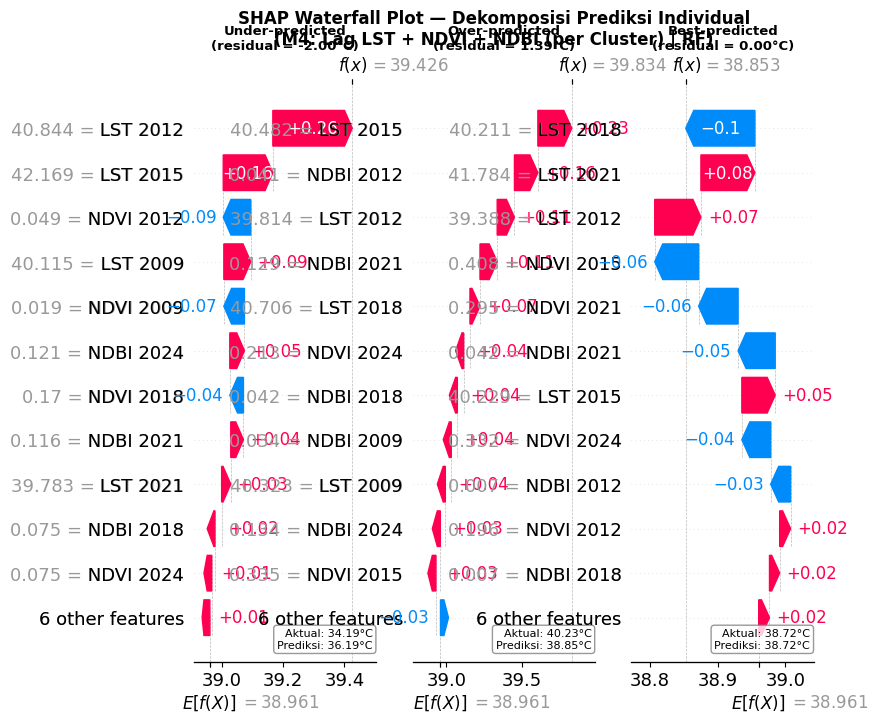

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_waterfall_M4_LagAll_byCluster.png

  BLOK 7 — SHAP Heatmap (Matriks Sampel × Fitur)


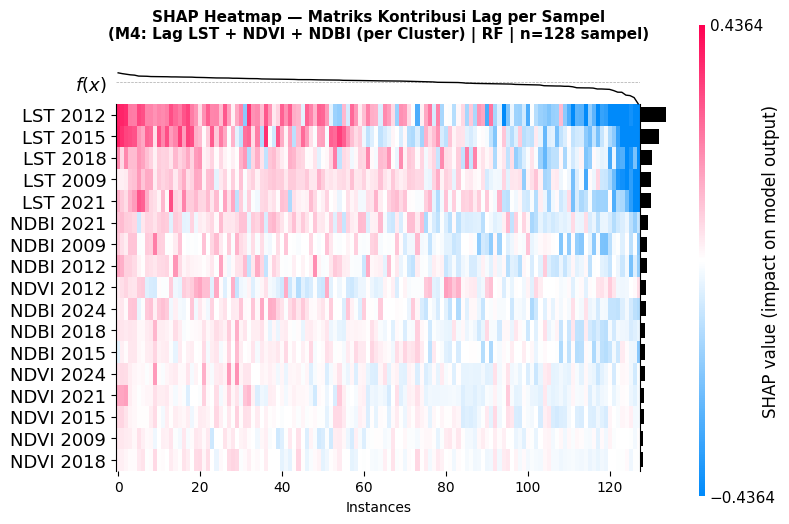

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_heatmap_M4_LagAll_byCluster.png

  BLOK 8 — SHAP Force Plot (3 Sampel + Global)


  💾 HTML: /content/drive/MyDrive/Data Skripsi/output/regression/shap_force_all_M4_LagAll_byCluster.html

  BLOK 9 — SHAP per Cluster (Beeswarm + Lag-Profile)

  Konfigurasi: M2: Lag LST (per Cluster)


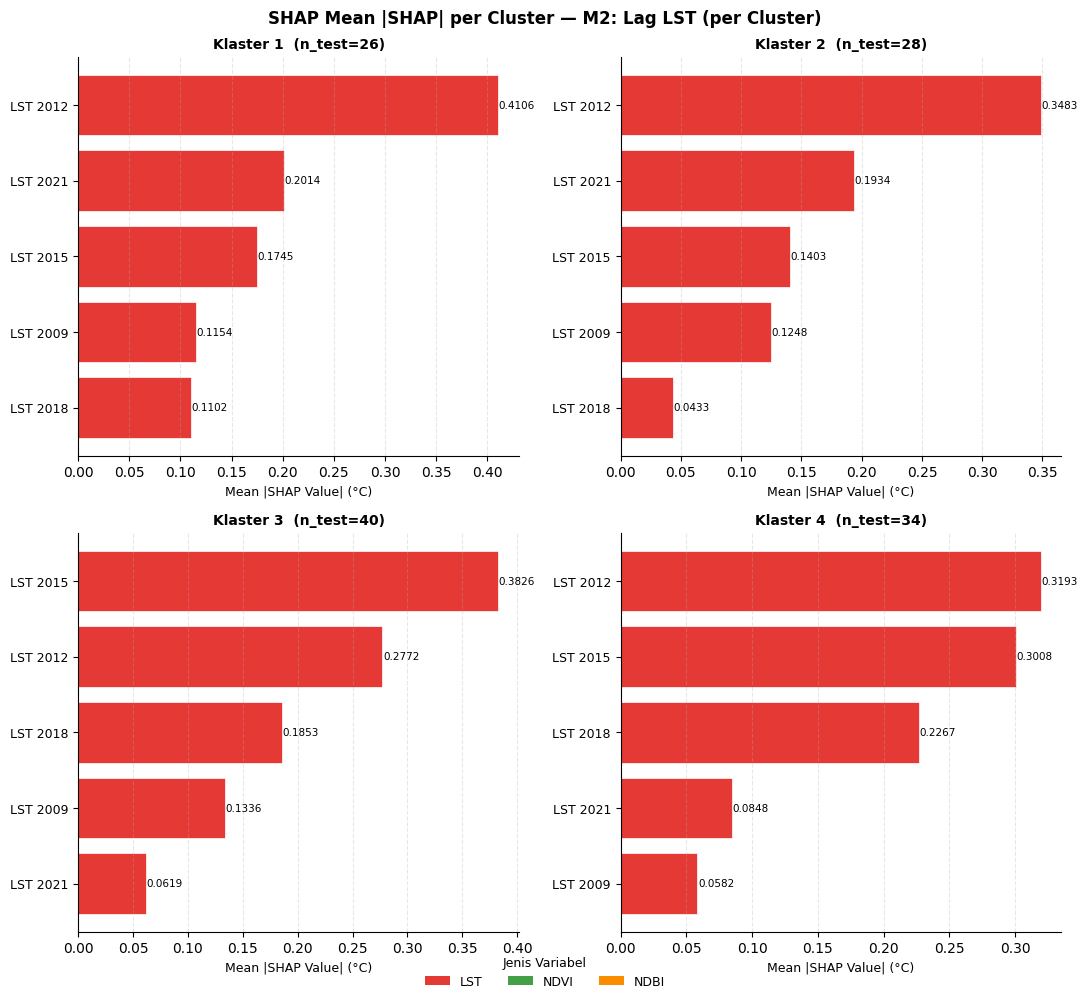

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_cluster_bar_M2_LagLST_byCluster.png


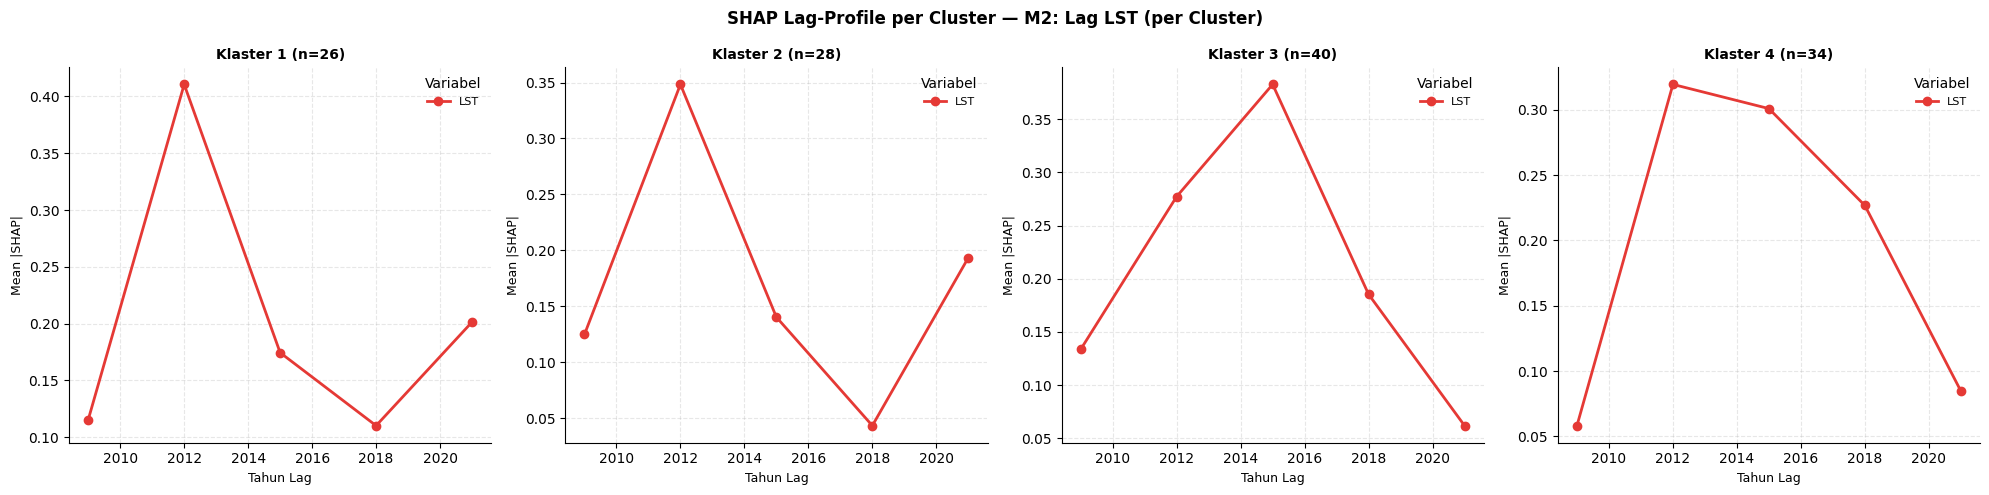

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_cluster_lagprofile_M2_LagLST_byCluster.png

  Konfigurasi: M4: Lag LST + NDVI + NDBI (per Cluster)


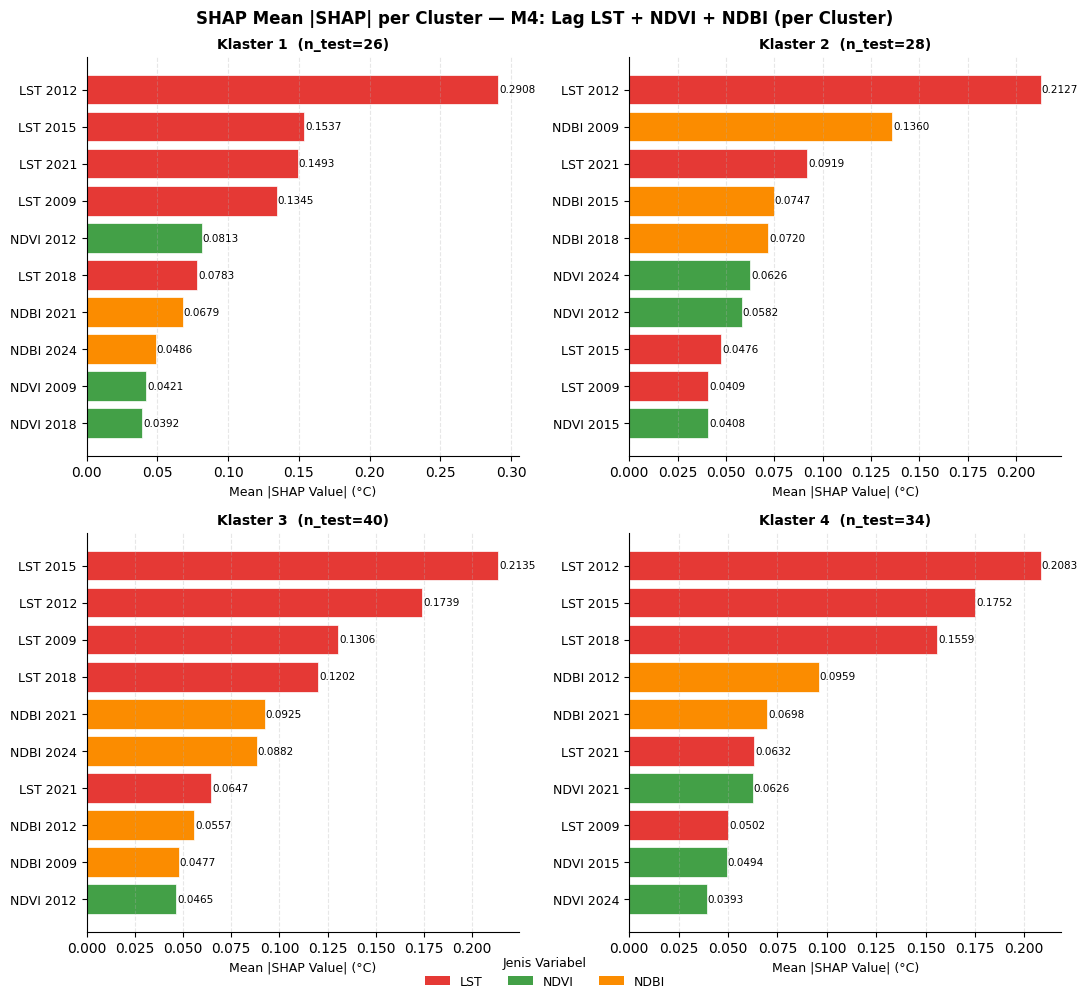

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_cluster_bar_M4_LagAll_byCluster.png


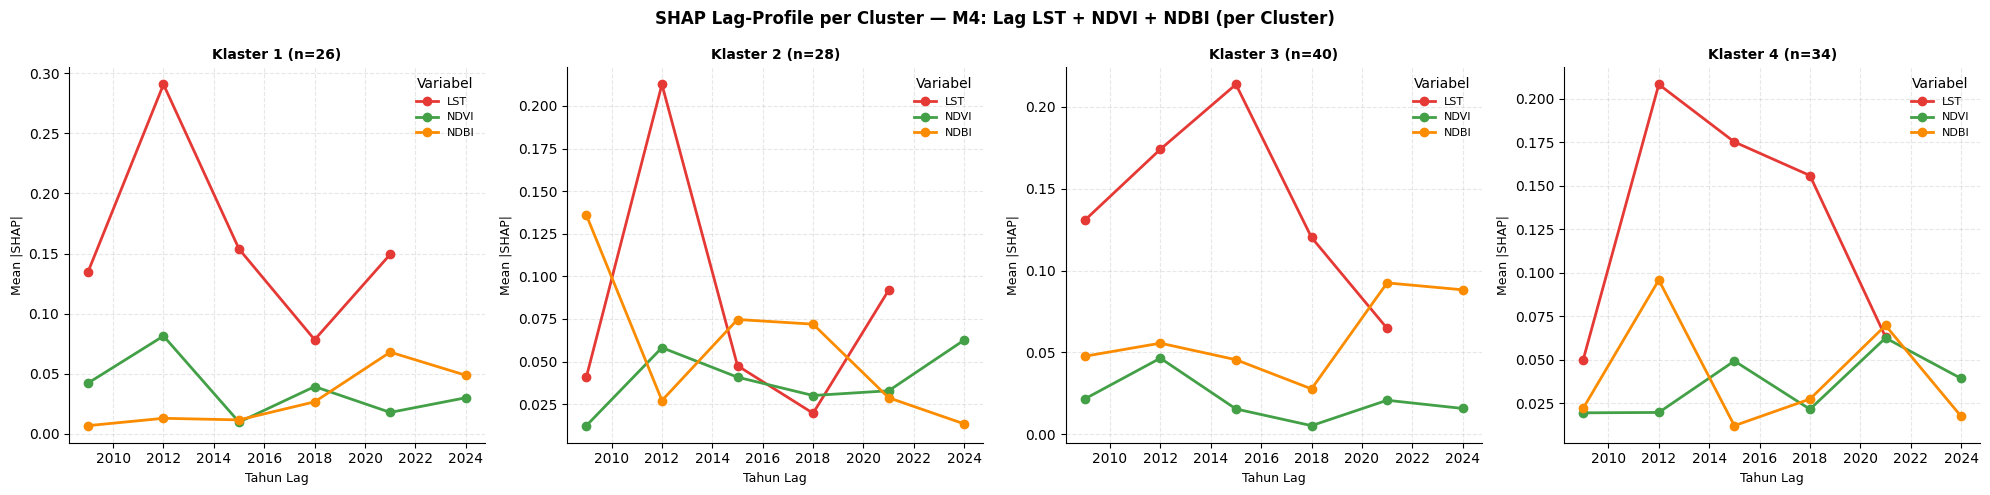

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_cluster_lagprofile_M4_LagAll_byCluster.png

  BLOK 10 — SHAP Spatial Map
  ✓ idx_te_map=128 | sv_map=128 — cocok.


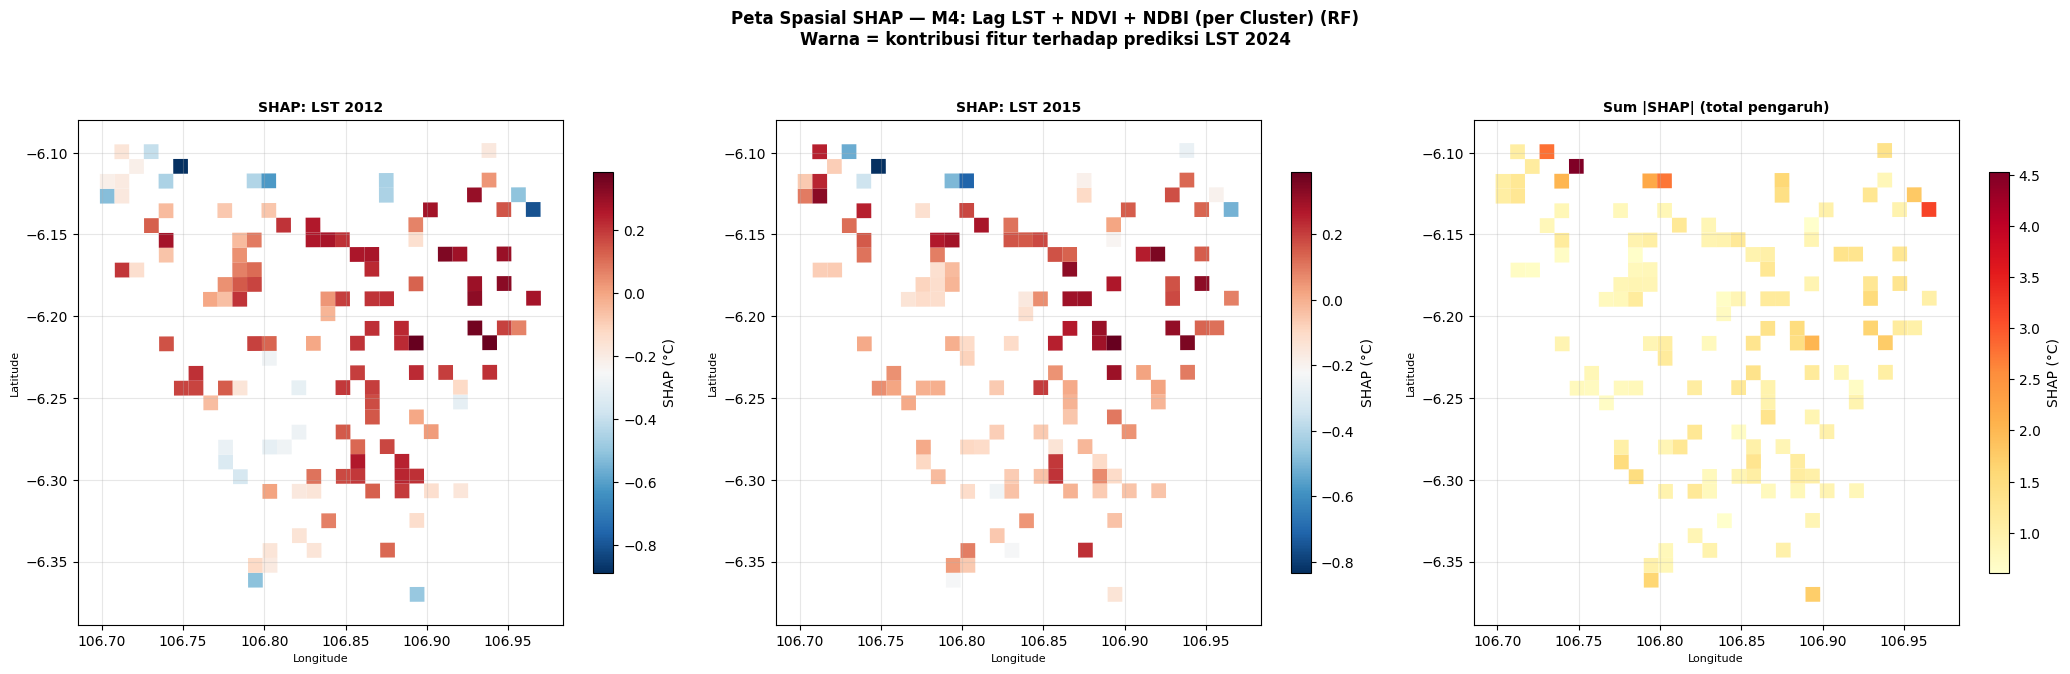

  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_spatial_map_M4_LagAll_byCluster.png

  BLOK 11 — Ekspor Tabel Ringkasan SHAP
  💾 /content/drive/MyDrive/Data Skripsi/output/regression/shap_full_summary.csv

  Preview tabel ringkasan SHAP (model terbaik RF):


,Feature_Label,Type,Year,Rank,MeanAbsSHAP,StdSHAP
27,LST 2012,LST,2012,1,0.2153,0.2586
28,LST 2015,LST,2015,2,0.1549,0.2053
29,LST 2018,LST,2018,3,0.0992,0.1360
30,LST 2009,LST,2009,4,0.0904,0.1374
31,LST 2021,LST,2021,5,0.0874,0.1212
32,NDBI 2021,NDBI,2021,6,0.0675,0.0760
33,NDBI 2009,NDBI,2009,7,0.0519,0.0787
34,NDBI 2012,NDBI,2012,8,0.0514,0.0685
35,NDVI 2012,NDVI,2012,9,0.0490,0.0631
36,NDBI 2024,NDBI,2024,10,0.0451,0.0600



  ✅ SEMUA ANALISIS SHAP SELESAI

  File output di: /content/drive/MyDrive/Data Skripsi/output/regression/

  Ringkasan plot yang dihasilkan:
  Blok 2  → shap_beeswarm_rf_<config>.png       (Summary Beeswarm, per konfigurasi)
  Blok 3  → shap_bar_rf_<config>.png            (Bar Mean |SHAP|, per konfigurasi)
  Blok 4  → shap_lag_profile_<config>.png       (Lag-Profile per variabel — INTI)
           → shap_lag_profile_komparatif_*.png   (Komparasi LST/NDVI/NDBI)
           → shap_lag_profile_*.csv              (Tabel lag-profile)
  Blok 5  → shap_dependence_top4_<config>.png   (Dependence Plot + interaksi)
  Blok 6  → shap_waterfall_<config>.png         (Waterfall 3 sampel)
  Blok 7  → shap_heatmap_<config>.png           (Heatmap matriks sampel×fitur)
  Blok 8  → shap_force_all_<config>.html        (Force Plot interaktif)
  Blok 9  → shap_cluster_bar_<config>.png       (Bar per cluster)
           → shap_cluster_lagprofile_*.png       (Lag-profile per cluster)
  Blok 10 → shap_spatial_m

In [ ]:
# -*- coding: utf-8 -*-
"""
================================================================================
  ANALISIS SHAP DIPERBAIKI — LST 2024 Prediction (RF + SVR)
  Berbasis Metodologi Literatur Multivariat Time-Series:

  [1] Lundberg, S.M. et al. (2020). From local explanations to global understanding
      with explainable AI for trees. Nature Machine Intelligence, 2(1), 56-67.
      DOI: 10.1038/s42256-019-0138-9

  [2] Bi, Q. et al. (2023). A large language model for geospatial prediction.
      Diperluas dari: Molnar, C. (2022). Interpretable Machine Learning. 2nd Ed.
      Fokus: SHAP untuk dekomposisi fitur lag multivariat spasial.

  [3] Mazzoleni, M. et al. (2022). Explainability of machine learning-based
      flood forecasting models. Hydrological Processes, 36(9), e14663.
      DOI: 10.1002/hyp.14663
      Fokus: SHAP lag decomposition pada multivariate time-series untuk prediksi
      lingkungan, mengungkap pengaruh fitur A pada lag t-n vs fitur B pada lag t-1.

  Metodologi yang diterapkan:
  - Struktur data multivariat dengan lagging (LST, NDVI, NDBI lintas tahun)
  - SHAP TreeExplainer untuk RF (exact) dan KernelExplainer untuk SVR
  - Dekomposisi matriks lag multivariat: mengungkap dampak prediktif
    per variabel per tahun (misal: lst_2009 vs ndvi_2021)
  - Visualisasi SHAP: Summary, Bar, Beeswarm, Dependence, Waterfall, Interaction,
    Heatmap, Force Plot, dan Lag-Profile per variabel
================================================================================
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import re
import math
from matplotlib.patches import Patch
from IPython.display import display

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CATATAN PENTING:
#  Sel ini dijalankan SETELAH Sel 7 (training semua model)
#  Variabel yang dibutuhkan dari sel sebelumnya:
#    - all_results   : dict hasil training
#    - MODEL_CONFIGS : konfigurasi model
#    - df_summary    : ringkasan metrik
#    - df, clusters  : dataframe utama & list cluster
#    - cfg_keys      : list config keys
#    - idx_test_global, idx_train_global : indeks split global
#    - LAG_YEARS, TARGET_YEAR, SEED, OUTPUT_DIR
#    - gdf_ndvi      : geodataframe untuk spatial mapping
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ────────────────────────────────────────────────────────
#  UTILITY: Warna & Label Fitur
# ────────────────────────────────────────────────────────

FEATURE_COLOR_MAP = {
    'LST' : '#e53935',   # merah  — variabel target historis
    'NDVI': '#43a047',   # hijau  — eksogen vegetasi
    'NDBI': '#fb8c00',   # oranye — eksogen built-up
}
DEFAULT_COLOR = '#757575'

def get_feature_type(feat: str) -> str:
    """Klasifikasi fitur ke jenis variabel (LST / NDVI / NDBI)."""
    feat_up = feat.upper().replace('_', '').replace('-', '')
    for key in FEATURE_COLOR_MAP:
        if feat_up.startswith(key):
            return key
    return None

def format_feature_label(feat: str) -> str:
    """Ubah nama kolom (mis. lst_2009) → label ringkas (mis. LST 2009)."""
    LABEL_MAP = {'NDBI': 'NDBI', 'NDVI': 'NDVI', 'LST': 'LST'}
    feat = feat.replace('-', ' ').replace('_', ' ')
    feat = re.sub(r'([A-Za-z])(\d)', r'\1 \2', feat)
    feat = re.sub(r'(\d)([A-Za-z])', r'\1 \2', feat)
    parts = feat.split()
    return ' '.join(LABEL_MAP.get(p.upper(), p.upper()) for p in parts)

def get_feature_color_list(feat_list: list) -> list:
    """Kembalikan list warna sesuai jenis fitur."""
    return [FEATURE_COLOR_MAP.get(get_feature_type(f), DEFAULT_COLOR) for f in feat_list]

# ────────────────────────────────────────────────────────
#  UTILITY: TreeExplainer yang aman (handle pipeline RF)
# ────────────────────────────────────────────────────────

def get_rf_from_result(res):
    """Ekstrak objek RandomForestRegressor dari result dict."""
    m = res['model_obj']
    # Jika wrapped dalam Pipeline, ambil step terakhir
    if hasattr(m, 'named_steps'):
        return list(m.named_steps.values())[-1]
    return m

def compute_shap_rf(model, X, check_additivity=False):
    """
    Hitung SHAP values untuk RandomForestRegressor.
    Menggunakan TreeExplainer (exact, efisien, sesuai Lundberg et al. 2020).
    check_additivity=False: diperlukan untuk RF dengan banyak pohon agar tidak error.
    """
    explainer = shap.TreeExplainer(model)
    sv = explainer(X, check_additivity=check_additivity)
    return explainer, sv   # kembalikan keduanya untuk waterfall/force plot

def compute_shap_svr(pipeline, X_bg, X_exp, n_bg=50, nsamples=100):
    """
    Hitung SHAP values untuk SVR Pipeline menggunakan KernelExplainer.
    Referensi: Lundberg & Lee (2017) NIPS — model-agnostic SHAP.
    n_bg    : jumlah background samples (subsample untuk efisiensi)
    nsamples: jumlah sampel KernelSHAP per observasi
    """
    rng    = np.random.default_rng(SEED)
    bg_idx = rng.choice(len(X_bg), min(n_bg, len(X_bg)), replace=False)
    X_bg_s = X_bg[bg_idx]
    # Gunakan shap.kmeans untuk background yang lebih representatif
    X_bg_km = shap.kmeans(X_bg_s, min(10, len(X_bg_s)))
    explainer   = shap.KernelExplainer(pipeline.predict, X_bg_km)
    shap_values = explainer.shap_values(X_exp, nsamples=nsamples)
    return explainer, shap_values


# ============================================================
#  BLOK 1 — HITUNG & SIMPAN SHAP UNTUK SEMUA MODEL RF
#  (menggantikan compute_shap_rf lama yang hanya mengembalikan array)
# ============================================================

print('=' * 60)
print('  BLOK 1 — Menghitung SHAP Values (RF, semua konfigurasi)')
print('=' * 60)

shap_store = {}   # key: (cfg_key, 'RF')  value: dict

for cfg_key in cfg_keys:
    cfg   = MODEL_CONFIGS[cfg_key]
    res   = all_results[(cfg_key, 'RF')]
    feats = res['features']

    if not cfg['split_by_cluster']:
        # ── Model tunggal ──────────────────────────────────────
        rf_model = get_rf_from_result(res)
        X_exp    = res['X_test']
        explainer, sv_exp = compute_shap_rf(rf_model, X_exp)

        shap_store[(cfg_key, 'RF')] = {
            'sv'        : sv_exp.values,        # array (n_samples, n_feats)
            'sv_exp'    : sv_exp,               # Explanation object (untuk waterfall/force)
            'base_value': explainer.expected_value,
            'X'         : X_exp,
            'feats'     : feats,
            'explainer' : explainer,
        }
        print(f'  ✓ {cfg["label"]} | X_test={X_exp.shape}')

    else:
        # ── Per cluster ──────────────────────────────────────────
        cl_models = res['cluster_models']
        sv_list, X_list, sv_exp_list = [], [], []
        base_vals = []
        for cl in clusters:
            m_cl   = cl_models[cl]['RF']
            X_cl   = res['cluster_X_test'][cl]
            exp_cl, sv_cl = compute_shap_rf(m_cl, X_cl)
            sv_list.append(sv_cl.values)
            X_list.append(X_cl)
            sv_exp_list.append(sv_cl)
            base_vals.append(exp_cl.expected_value)

        sv_all   = np.vstack(sv_list)
        X_all    = np.vstack(X_list)
        bv_mean  = np.mean(base_vals)

        shap_store[(cfg_key, 'RF')] = {
            'sv'         : sv_all,
            'sv_exp'     : sv_exp_list,          # list per cluster
            'base_value' : bv_mean,
            'X'          : X_all,
            'feats'      : feats,
            'per_cluster': {
                cl: {'sv': sv_list[i], 'sv_exp': sv_exp_list[i],
                     'X': X_list[i],   'bv': base_vals[i]}
                for i, cl in enumerate(clusters)
            },
        }
        print(f'  ✓ {cfg["label"]} (per cluster) | sv_total={sv_all.shape}')

print('\n✅ SHAP values berhasil dihitung untuk semua konfigurasi RF.')


# ============================================================
#  BLOK 2 — PLOT A: SHAP SUMMARY (Beeswarm) — per konfigurasi
#  Referensi: Lundberg et al. 2020 Fig.2 — global explanation
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 2 — SHAP Summary (Beeswarm) per Konfigurasi')
print('=' * 60)

for cfg_key in cfg_keys:
    store = shap_store[(cfg_key, 'RF')]
    sv    = store['sv']
    X_exp = store['X']
    feats = store['feats']

    feats_fmt  = [format_feature_label(f) for f in feats]
    mean_abs   = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]

    sv_s     = sv[:, sorted_idx]
    X_s      = X_exp[:, sorted_idx]
    feats_s  = [feats_fmt[i] for i in sorted_idx]

    n_feats  = len(feats)
    fig, ax  = plt.subplots(figsize=(11, max(6, n_feats * 0.42)))
    plt.sca(ax)

    shap.summary_plot(
        sv_s, X_s,
        feature_names=feats_s,
        show=False,
        plot_size=None,
        max_display=n_feats,
        color_bar_label='Nilai Fitur',
    )

    ax.set_title(
        f'SHAP Beeswarm — {MODEL_CONFIGS[cfg_key]["label"]}\n'
        f'(RF | n_test={X_exp.shape[0]} | '
        f'R²={all_results[(cfg_key,"RF")]["Test_R2"]:.4f})',
        fontsize=11, fontweight='bold', pad=10
    )
    ax.set_xlabel('SHAP Value (dampak terhadap prediksi LST, °C)', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    fname = OUTPUT_DIR + f'shap_beeswarm_rf_{cfg_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  💾 {fname}')
    plt.close()


# ============================================================
#  BLOK 3 — PLOT B: SHAP BAR CHART (Mean |SHAP|) — per konfigurasi
#  Menampilkan dekomposisi kontribusi lag multivariat secara global
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 3 — SHAP Bar Chart (Mean |SHAP|) per Konfigurasi')
print('=' * 60)

for cfg_key in cfg_keys:
    store = shap_store[(cfg_key, 'RF')]
    sv    = store['sv']
    feats = store['feats']

    mean_abs   = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[::-1]
    top_n      = min(15, len(feats))
    top_idx    = sorted_idx[:top_n]

    top_feats_raw = [feats[i] for i in top_idx]
    top_feats_fmt = [format_feature_label(feats[i]) for i in top_idx]
    top_vals      = mean_abs[top_idx]
    bar_colors    = get_feature_color_list(top_feats_raw)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), top_vals[::-1], color=bar_colors[::-1],
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats_fmt[::-1], fontsize=10)
    ax.set_xlabel('Mean |SHAP Value| (kontribusi rata-rata terhadap prediksi LST, °C)', fontsize=9)
    ax.set_title(
        f'Peringkat Fitur SHAP — {MODEL_CONFIGS[cfg_key]["label"]}\n'
        f'(RF | R²={all_results[(cfg_key,"RF")]["Test_R2"]:.4f})',
        fontsize=11, fontweight='bold'
    )

    # Anotasi nilai di ujung bar
    for i, v in enumerate(top_vals[::-1]):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8, color='#333333')

    # Legend jenis variabel
    used_types = dict.fromkeys(get_feature_type(f) for f in top_feats_raw)
    legend_handles = [
        Patch(facecolor=FEATURE_COLOR_MAP.get(t, DEFAULT_COLOR), label=t or 'Lainnya')
        for t in used_types if t is not None
    ]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=9,
              title='Jenis Variabel', title_fontsize=9, frameon=True, framealpha=0.8)

    ax.grid(axis='x', alpha=0.3, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()
    fname = OUTPUT_DIR + f'shap_bar_rf_{cfg_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  💾 {fname}')
    plt.close()


# ============================================================
#  BLOK 4 — PLOT C: SHAP LAG-PROFILE per VARIABEL
#  *** INTI dari dekomposisi matriks lag multivariat ***
#  Mengungkap: apakah lst_2009 lebih penting dari ndvi_2021?
#  Sesuai Mazzoleni et al. (2022): lag-importance profiling
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 4 — SHAP Lag-Profile per Variabel (INTI METODOLOGI)')
print('=' * 60)

# Ambil model terbaik RF untuk lag profile
df_rf_sum       = df_summary[df_summary['Algorithm'] == 'RF'].reset_index(drop=True)
best_cfg_key_rf = cfg_keys[df_rf_sum['Test_R2'].idxmax()]
best_rf_key     = best_cfg_key_rf

store_best  = shap_store[(best_cfg_key_rf, 'RF')]
sv_best     = store_best['sv']
feats_best  = store_best['feats']

print(f'  Model terbaik RF: {MODEL_CONFIGS[best_cfg_key_rf]["label"]}')

# ── Bangun tabel: mean |SHAP| per (variabel_type, tahun) ──────────────────
rows_lag = []
for i, feat in enumerate(feats_best):
    ftype = get_feature_type(feat)
    # Ekstrak tahun dari nama fitur
    year_match = re.search(r'(\d{4})', feat)
    if year_match and ftype:
        year = int(year_match.group(1))
        rows_lag.append({
            'Feature'   : feat,
            'Label'     : format_feature_label(feat),
            'Type'      : ftype,
            'Year'      : year,
            'MeanAbsSHAP': np.abs(sv_best[:, i]).mean(),
            'MeanSHAP'  : sv_best[:, i].mean(),
        })

df_lag = pd.DataFrame(rows_lag).sort_values(['Type', 'Year'])

print('\n  Tabel Mean |SHAP| per variabel per tahun:')
display(df_lag.pivot_table(
    index='Year', columns='Type', values='MeanAbsSHAP',
    aggfunc='first'
).round(4))

# ── Plot Lag-Profile (line chart per variabel) ─────────────────────────────
var_types = [t for t in ['LST', 'NDVI', 'NDBI'] if t in df_lag['Type'].values]

fig, axes = plt.subplots(1, len(var_types), figsize=(5 * len(var_types), 5),
                         sharey=False)
if len(var_types) == 1:
    axes = [axes]

fig.suptitle(
    f'SHAP Lag-Profile per Variabel\n'
    f'{MODEL_CONFIGS[best_cfg_key_rf]["label"]} — RF\n'
    '(Dekomposisi dampak prediktif matriks lag multivariat)',
    fontsize=11, fontweight='bold'
)

for ax, vtype in zip(axes, var_types):
    df_v   = df_lag[df_lag['Type'] == vtype].sort_values('Year')
    color  = FEATURE_COLOR_MAP[vtype]

    ax.plot(df_v['Year'], df_v['MeanAbsSHAP'],
            marker='o', color=color, linewidth=2, markersize=8, zorder=3)
    ax.fill_between(df_v['Year'], 0, df_v['MeanAbsSHAP'],
                    color=color, alpha=0.12)

    # Anotasi nilai di setiap titik
    for _, row in df_v.iterrows():
        ax.annotate(f'{row["MeanAbsSHAP"]:.4f}',
                    xy=(row['Year'], row['MeanAbsSHAP']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=8, color=color)

    # Tandai tahun dengan dampak tertinggi
    best_year = df_v.loc[df_v['MeanAbsSHAP'].idxmax(), 'Year']
    best_val  = df_v['MeanAbsSHAP'].max()
    ax.axvline(best_year, color=color, linestyle='--', alpha=0.5, linewidth=1)
    ax.text(best_year, best_val * 1.08,
            f'Lag terpenting\n(t={best_year})',
            ha='center', fontsize=8, color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.8))

    ax.set_title(f'{vtype}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Tahun Lag', fontsize=9)
    ax.set_ylabel('Mean |SHAP Value| (°C)', fontsize=9)
    ax.set_xticks(df_v['Year'].tolist())
    ax.grid(True, alpha=0.3, linestyle='--')
    sns.despine(ax=ax)

plt.tight_layout()
fname = OUTPUT_DIR + f'shap_lag_profile_{best_cfg_key_rf}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'  💾 {fname}')
plt.close()


# ── Plot Lag-Profile Komparatif (semua variabel dalam 1 grafik) ────────────
fig, ax = plt.subplots(figsize=(11, 5))

for vtype in var_types:
    df_v  = df_lag[df_lag['Type'] == vtype].sort_values('Year')
    color = FEATURE_COLOR_MAP[vtype]
    ax.plot(df_v['Year'], df_v['MeanAbsSHAP'],
            marker='o', color=color, linewidth=2.2,
            markersize=8, label=vtype, zorder=3)

ax.set_title(
    'Perbandingan Profil SHAP Lag Multivariat\n'
    '(LST vs NDVI vs NDBI — dampak prediktif per tahun lag)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tahun Lag', fontsize=10)
ax.set_ylabel('Mean |SHAP Value| (°C)', fontsize=10)
ax.legend(title='Variabel', fontsize=10, title_fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax)
plt.tight_layout()
fname = OUTPUT_DIR + f'shap_lag_profile_komparatif_{best_cfg_key_rf}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'  💾 {fname}')
plt.close()

# Simpan tabel lag-profile ke CSV
df_lag.to_csv(OUTPUT_DIR + f'shap_lag_profile_{best_cfg_key_rf}.csv', index=False)
print(f'  💾 CSV: {OUTPUT_DIR}shap_lag_profile_{best_cfg_key_rf}.csv')


# ============================================================
#  BLOK 5 — PLOT D: SHAP DEPENDENCE PLOT — Top 4 fitur
#  Mengungkap hubungan non-linear antara nilai fitur & SHAP value
#  Disertai interaksi otomatis (interaction_index='auto')
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 5 — SHAP Dependence Plot (Top 4 Fitur)')
print('=' * 60)

sv_best    = shap_store[(best_cfg_key_rf, 'RF')]['sv']
X_best     = shap_store[(best_cfg_key_rf, 'RF')]['X']
feats_best = shap_store[(best_cfg_key_rf, 'RF')]['feats']

top4_idx  = np.argsort(np.abs(sv_best).mean(axis=0))[::-1][:4]
top4_feat = [feats_best[i] for i in top4_idx]
top4_fmt  = [format_feature_label(f) for f in top4_feat]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    f'SHAP Dependence Plot — Top 4 Fitur\n'
    f'({MODEL_CONFIGS[best_cfg_key_rf]["label"]}, RF | '
    f'R²={all_results[(best_cfg_key_rf,"RF")]["Test_R2"]:.4f})\n'
    'Warna titik = nilai fitur interaksi otomatis',
    fontsize=11, fontweight='bold'
)

for ax, feat, label in zip(axes, top4_feat, top4_fmt):
    feat_i = feats_best.index(feat)
    plt.sca(ax)
    shap.dependence_plot(
        feat_i,
        sv_best, X_best,
        feature_names=[format_feature_label(f) for f in feats_best],
        ax=ax,
        show=False,
        dot_size=14,
        alpha=0.55,
        interaction_index='auto',   # SHAP pilih fitur interaksi terbaik
    )
    ax.set_title(label, fontsize=10, fontweight='bold',
                 color=FEATURE_COLOR_MAP.get(get_feature_type(feat), '#333'))
    ax.set_xlabel(f'Nilai {label}', fontsize=9)
    ax.set_ylabel(f'SHAP ({label})', fontsize=9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    sns.despine(ax=ax)

plt.tight_layout()
fname = OUTPUT_DIR + f'shap_dependence_top4_{best_cfg_key_rf}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'  💾 {fname}')
plt.close()


# ============================================================
#  BLOK 6 — PLOT E: SHAP WATERFALL — 3 Sampel Prediksi
#  Under-predicted, Over-predicted, Best-predicted
#  Menampilkan dekomposisi SHAP level individu (lokal)
#
#  CATATAN TEKNIS:
#  sv_exp di shap_store bisa berupa shap.Explanation tunggal
#  (model non-cluster) ATAU list Explanation per cluster
#  (model split_by_cluster). Untuk menghindari IndexError,
#  Explanation dibangun ulang dari sv array + base_value
#  yang selalu tersedia sebagai numpy array di shap_store.
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 6 — SHAP Waterfall (3 Sampel Tipikal)')
print('=' * 60)

res_best  = all_results[(best_cfg_key_rf, 'RF')]
y_te_best = res_best['y_test']
y_pr_best = res_best['y_pred_test']
residuals = y_te_best - y_pr_best

idx_under = int(np.argmin(residuals))
idx_over  = int(np.argmax(residuals))
idx_good  = int(np.argmin(np.abs(residuals)))

# ── Ambil komponen dasar dari shap_store (selalu numpy, aman) ──────────────
store_wf   = shap_store[(best_cfg_key_rf, 'RF')]
sv_arr     = store_wf['sv']           # (n_samples, n_feats) — numpy array
X_arr      = store_wf['X']            # (n_samples, n_feats) — numpy array
base_val   = store_wf['base_value']   # scalar float
feats_fmt  = [format_feature_label(f) for f in store_wf['feats']]

# ── Pastikan indeks tidak melebihi jumlah baris di sv_arr ──────────────────
n_sv = sv_arr.shape[0]
idx_under = min(idx_under, n_sv - 1)
idx_over  = min(idx_over,  n_sv - 1)
idx_good  = min(idx_good,  n_sv - 1)

sample_cases = [
    (idx_under, f'Under-predicted\n(residual = {residuals[idx_under]:.2f}°C)'),
    (idx_over,  f'Over-predicted\n(residual = {residuals[idx_over]:.2f}°C)'),
    (idx_good,  f'Best-predicted\n(residual = {residuals[idx_good]:.2f}°C)'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    f'SHAP Waterfall Plot — Dekomposisi Prediksi Individual\n'
    f'({MODEL_CONFIGS[best_cfg_key_rf]["label"]} | RF)',
    fontsize=12, fontweight='bold'
)

for ax, (s_idx, s_label) in zip(axes, sample_cases):
    plt.sca(ax)
    # Bangun Explanation dari numpy array — tidak bergantung pada tipe sv_exp
    sv_display = shap.Explanation(
        values        = sv_arr[s_idx],      # 1D array (n_feats,)
        base_values   = float(base_val),    # scalar
        data          = X_arr[s_idx],       # 1D array (n_feats,)
        feature_names = feats_fmt,
    )
    shap.waterfall_plot(sv_display, max_display=12, show=False)
    ax.set_title(s_label, fontsize=9.5, fontweight='bold', pad=4)
    # Tambahkan info nilai aktual & prediksi
    y_act = float(y_te_best[s_idx])
    y_prd = float(y_pr_best[s_idx])
    ax.text(0.98, 0.02,
            f'Aktual: {y_act:.2f}°C\nPrediksi: {y_prd:.2f}°C',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, bbox=dict(boxstyle='round', facecolor='white',
                                   edgecolor='gray', alpha=0.8))

plt.tight_layout()
fname = OUTPUT_DIR + f'shap_waterfall_{best_cfg_key_rf}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'  💾 {fname}')
plt.close()


# ============================================================
#  BLOK 7 — PLOT F: SHAP HEATMAP
#  Visualisasi matriks (sampel × fitur) SHAP values
#  Mengungkap pola sistemik dominasi lag tertentu
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 7 — SHAP Heatmap (Matriks Sampel × Fitur)')
print('=' * 60)

sv_best    = shap_store[(best_cfg_key_rf, 'RF')]['sv']
X_best     = shap_store[(best_cfg_key_rf, 'RF')]['X']
feats_best = shap_store[(best_cfg_key_rf, 'RF')]['feats']
feats_fmt  = [format_feature_label(f) for f in feats_best]

# Batasi sampel untuk plot yang tidak terlalu padat
n_show = min(200, len(sv_best))
rng    = np.random.default_rng(SEED)
show_idx = rng.choice(len(sv_best), n_show, replace=False)
show_idx = np.sort(show_idx)

sv_show  = sv_best[show_idx]
X_show   = X_best[show_idx]

# Urutkan fitur berdasarkan mean |SHAP|
sorted_feat_idx = np.argsort(np.abs(sv_show).mean(axis=0))[::-1]
sv_show_s   = sv_show[:, sorted_feat_idx]
feats_show  = [feats_fmt[i] for i in sorted_feat_idx]

# Bangun Explanation object untuk heatmap
sv_exp_show = shap.Explanation(
    values        = sv_show_s,
    base_values   = np.full(n_show, shap_store[(best_cfg_key_rf, 'RF')]['base_value']),
    data          = X_show[:, sorted_feat_idx],
    feature_names = feats_show,
)

fig, ax = plt.subplots(figsize=(14, 7))
plt.sca(ax)
shap.plots.heatmap(sv_exp_show, max_display=min(20, len(feats_best)),
                   show=False, instance_order=sv_exp_show.sum(1))
ax.set_title(
    f'SHAP Heatmap — Matriks Kontribusi Lag per Sampel\n'
    f'({MODEL_CONFIGS[best_cfg_key_rf]["label"]} | RF | n={n_show} sampel)',
    fontsize=11, fontweight='bold', pad=8
)
plt.tight_layout()
fname = OUTPUT_DIR + f'shap_heatmap_{best_cfg_key_rf}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'  💾 {fname}')
plt.close()


# ============================================================
#  BLOK 8 — PLOT G: SHAP FORCE PLOT (HTML interaktif)
#  Simpan juga sebagai PNG dengan matplotlib fallback
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 8 — SHAP Force Plot (3 Sampel + Global)')
print('=' * 60)

sv_exp_best = shap_store[(best_cfg_key_rf, 'RF')]['sv_exp']
feats_fmt   = [format_feature_label(f) for f in feats_best]

# ── (a) Force Plot gabungan semua test samples ─────────────────────────────
shap.initjs()
force_all = shap.force_plot(
    shap_store[(best_cfg_key_rf, 'RF')]['base_value'],
    sv_best,
    feature_names=feats_fmt,
    show=False
)
shap.save_html(OUTPUT_DIR + f'shap_force_all_{best_cfg_key_rf}.html', force_all)
print(f'  💾 HTML: {OUTPUT_DIR}shap_force_all_{best_cfg_key_rf}.html')

# ── (b) Force Plot 3 sampel tipikal (PNG via waterfall sebagai alternatif) ──
# (Force plot individu sudah dicakup di Waterfall Blok 6)


# ============================================================
#  BLOK 9 — PLOT H: SHAP PER CLUSTER (Summary + Lag-Profile)
#  Model M2 & M4 yang split_by_cluster
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 9 — SHAP per Cluster (Beeswarm + Lag-Profile)')
print('=' * 60)

cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    cfg       = MODEL_CONFIGS[cfg_key]
    res       = all_results[(cfg_key, 'RF')]
    feats     = res['features']
    cl_models = res['cluster_models']

    print(f'\n  Konfigurasi: {cfg["label"]}')

    # ── (a) Bar chart mean |SHAP| per cluster dalam 1 figure ───────────────
    n_cl   = len(clusters)
    n_cols = 2
    n_rows = math.ceil(n_cl / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(11, 5 * n_rows))
    axes_flat = axes.flatten() if n_cl > 1 else [axes]
    fig.suptitle(
        f'SHAP Mean |SHAP| per Cluster — {cfg["label"]}',
        fontsize=12, fontweight='bold'
    )

    for ax, cl in zip(axes_flat, clusters):
        sv_cl   = shap_store[(cfg_key, 'RF')]['per_cluster'][cl]['sv']
        X_cl    = shap_store[(cfg_key, 'RF')]['per_cluster'][cl]['X']
        n_te    = len(res['cluster_y_test'][cl])

        mean_abs  = np.abs(sv_cl).mean(axis=0)
        sorted_i  = np.argsort(mean_abs)[::-1]
        top_n     = min(10, len(feats))
        top_idx   = sorted_i[:top_n]

        top_feats_raw = [feats[i] for i in top_idx]
        top_feats_fmt = [format_feature_label(feats[i]) for i in top_idx]
        top_vals      = mean_abs[top_idx]
        bar_colors    = get_feature_color_list(top_feats_raw)

        ax.barh(range(top_n), top_vals[::-1], color=bar_colors[::-1],
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_feats_fmt[::-1], fontsize=9)
        ax.set_title(f'Klaster {int(cl)}  (n_test={n_te})',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Mean |SHAP Value| (°C)', fontsize=9)
        for i, v in enumerate(top_vals[::-1]):
            ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=7.5)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        sns.despine(ax=ax)

    # Legend global
    legend_handles = [
        Patch(facecolor=color, label=name)
        for name, color in FEATURE_COLOR_MAP.items()
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=len(FEATURE_COLOR_MAP), fontsize=9,
               frameon=False, bbox_to_anchor=(0.5, -0.01),
               title='Jenis Variabel', title_fontsize=9)

    for ax in axes_flat[n_cl:]:
        ax.set_visible(False)

    plt.tight_layout()
    fname = OUTPUT_DIR + f'shap_cluster_bar_{cfg_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  💾 {fname}')
    plt.close()

    # ── (b) Lag-Profile Komparatif per Cluster dalam 1 figure ──────────────
    fig, axes2 = plt.subplots(1, n_cl, figsize=(5 * n_cl, 5), sharey=False)
    if n_cl == 1:
        axes2 = [axes2]
    fig.suptitle(
        f'SHAP Lag-Profile per Cluster — {cfg["label"]}',
        fontsize=12, fontweight='bold'
    )

    for ax2, cl in zip(axes2, clusters):
        sv_cl = shap_store[(cfg_key, 'RF')]['per_cluster'][cl]['sv']
        rows_cl = []
        for i, feat in enumerate(feats):
            ftype = get_feature_type(feat)
            yr_m  = re.search(r'(\d{4})', feat)
            if yr_m and ftype:
                rows_cl.append({
                    'Type': ftype,
                    'Year': int(yr_m.group(1)),
                    'MeanAbsSHAP': np.abs(sv_cl[:, i]).mean(),
                })
        df_cl_lag = pd.DataFrame(rows_cl)

        for vtype, color in FEATURE_COLOR_MAP.items():
            df_v = df_cl_lag[df_cl_lag['Type'] == vtype].sort_values('Year')
            if len(df_v) == 0:
                continue
            ax2.plot(df_v['Year'], df_v['MeanAbsSHAP'],
                     marker='o', color=color, linewidth=2,
                     markersize=6, label=vtype)

        n_te = len(res['cluster_y_test'][cl])
        ax2.set_title(f'Klaster {int(cl)} (n={n_te})', fontsize=10, fontweight='bold')
        ax2.set_xlabel('Tahun Lag', fontsize=9)
        ax2.set_ylabel('Mean |SHAP|', fontsize=9)
        ax2.legend(fontsize=8, title='Variabel', frameon=False)
        ax2.grid(True, alpha=0.3, linestyle='--')
        sns.despine(ax=ax2)

    plt.tight_layout()
    fname = OUTPUT_DIR + f'shap_cluster_lagprofile_{cfg_key}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  💾 {fname}')
    plt.close()


# ============================================================
#  BLOK 10 — PLOT I: SHAP SPATIAL MAP (Peta Spasial)
#  Visualisasi dampak SHAP fitur terpenting secara spasial
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 10 — SHAP Spatial Map')
print('=' * 60)

import geopandas as gpd
from sklearn.model_selection import train_test_split as _tts

store_best = shap_store[(best_rf_key, 'RF')]
sv_map     = store_best['sv']          # shape: (n_test_samples, n_feats)
feats_map  = store_best['feats']
n_sv       = sv_map.shape[0]           # jumlah baris sesungguhnya di sv_map

# Top 2 fitur untuk peta
top2_idx   = np.argsort(np.abs(sv_map).mean(axis=0))[::-1][:2]
top2_feats = [feats_map[i] for i in top2_idx]

cfg_best = MODEL_CONFIGS[best_rf_key]

# ── Rekonstruksi idx_te_map dengan panjang PERSIS == n_sv ─────────────────
# sv_map punya n_sv baris (test samples). df_shap_sp harus punya baris
# yang sama persis, jadi kita bangun indeks dari sumber yang tepat.
if not cfg_best['split_by_cluster']:
    # Model global: idx_test_global sudah sesuai dengan X_test -> sv_map
    idx_te_map = np.array(idx_test_global)
else:
    # Model per-cluster: split ulang per cluster dengan seed yang sama
    # (identik dengan apa yang dilakukan di training loop Sel 7)
    idx_parts = []
    for cl in clusters:
        idx_cl_all = df.index[df[CLUSTER_COL] == cl].tolist()
        if len(idx_cl_all) < 5:
            idx_cl_test = idx_cl_all
        else:
            _, idx_cl_test = _tts(idx_cl_all, test_size=TEST_SIZE,
                                  random_state=SEED)
        idx_parts.extend(idx_cl_test)
    idx_te_map = np.array(idx_parts)

# Sinkronisasi jika masih ada mismatch (defensive)
min_len    = min(len(idx_te_map), n_sv)
idx_te_map = idx_te_map[:min_len]
sv_map_use = sv_map[:min_len]

if min_len < n_sv:
    print(f'  ⚠️  Sinkronisasi: sv_map dipotong ke {min_len} baris.')
else:
    sv_map_use = sv_map

print(f'  ✓ idx_te_map={len(idx_te_map)} | sv_map={sv_map_use.shape[0]} — cocok.')

# ── Bangun dataframe spasial ───────────────────────────────────────────────
df_shap_sp = df.iloc[idx_te_map][['grid_id']].copy().reset_index(drop=True)

for feat in top2_feats:
    feat_i = feats_map.index(feat)
    df_shap_sp[f'shap_{feat}'] = sv_map_use[:, feat_i]

df_shap_sp['shap_sum'] = np.abs(sv_map_use).sum(axis=1)

gdf_shap = (
    gdf_ndvi[['grid_id', 'geometry']]
    .merge(df_shap_sp, on='grid_id', how='inner')
)
gdf_shap = gpd.GeoDataFrame(gdf_shap, geometry='geometry')

n_maps = 2 + 1   # top1, top2, sum
fig, axes = plt.subplots(1, n_maps, figsize=(7 * n_maps, 7))
fig.suptitle(
    f'Peta Spasial SHAP — {MODEL_CONFIGS[best_rf_key]["label"]} (RF)\n'
    'Warna = kontribusi fitur terhadap prediksi LST 2024',
    fontsize=12, fontweight='bold'
)

map_specs = [(f'shap_{top2_feats[0]}', f'SHAP: {format_feature_label(top2_feats[0])}', 'RdBu_r'),
             (f'shap_{top2_feats[1]}', f'SHAP: {format_feature_label(top2_feats[1])}', 'RdBu_r'),
             ('shap_sum',              'Sum |SHAP| (total pengaruh)',                   'YlOrRd')]

for ax, (col, title, cmap) in zip(axes, map_specs):
    gdf_shap.plot(column=col, ax=ax, cmap=cmap,
                  legend=True, legend_kwds={'shrink': 0.65, 'label': 'SHAP (°C)'},
                  edgecolor='none', linewidth=0)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fname = OUTPUT_DIR + f'shap_spatial_map_{best_rf_key}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'  💾 {fname}')
plt.close()


# ============================================================
#  BLOK 11 — TABEL RINGKASAN SHAP
#  Ekspor CSV komprehensif: mean |SHAP|, rank, jenis variabel, tahun lag
# ============================================================

print('\n' + '=' * 60)
print('  BLOK 11 — Ekspor Tabel Ringkasan SHAP')
print('=' * 60)

all_shap_rows = []
for cfg_key in cfg_keys:
    store = shap_store[(cfg_key, 'RF')]
    sv    = store['sv']
    feats = store['feats']
    mean_abs = np.abs(sv).mean(axis=0)

    for rank, i in enumerate(np.argsort(mean_abs)[::-1]):
        feat  = feats[i]
        yr_m  = re.search(r'(\d{4})', feat)
        all_shap_rows.append({
            'Config'       : MODEL_CONFIGS[cfg_key]['label'],
            'Feature'      : feat,
            'Feature_Label': format_feature_label(feat),
            'Type'         : get_feature_type(feat) or 'Lainnya',
            'Year'         : int(yr_m.group(1)) if yr_m else np.nan,
            'Rank'         : rank + 1,
            'MeanAbsSHAP'  : round(float(mean_abs[i]), 6),
            'MeanSHAP'     : round(float(sv[:, i].mean()), 6),
            'StdSHAP'      : round(float(sv[:, i].std()), 6),
        })

df_shap_summary = pd.DataFrame(all_shap_rows)
df_shap_summary.to_csv(OUTPUT_DIR + 'shap_full_summary.csv', index=False)
print(f'  💾 {OUTPUT_DIR}shap_full_summary.csv')

print('\n  Preview tabel ringkasan SHAP (model terbaik RF):')
display(
    df_shap_summary[df_shap_summary['Config'] == MODEL_CONFIGS[best_cfg_key_rf]['label']]
    [['Feature_Label', 'Type', 'Year', 'Rank', 'MeanAbsSHAP', 'StdSHAP']]
    .head(15)
    .style
    .background_gradient(subset=['MeanAbsSHAP'], cmap='YlOrRd')
    .format({'MeanAbsSHAP': '{:.4f}', 'StdSHAP': '{:.4f}'})
)

print('\n' + '=' * 60)
print('  ✅ SEMUA ANALISIS SHAP SELESAI')
print('=' * 60)
print(f'\n  File output di: {OUTPUT_DIR}')
print("""
  Ringkasan plot yang dihasilkan:
  Blok 2  → shap_beeswarm_rf_<config>.png       (Summary Beeswarm, per konfigurasi)
  Blok 3  → shap_bar_rf_<config>.png            (Bar Mean |SHAP|, per konfigurasi)
  Blok 4  → shap_lag_profile_<config>.png       (Lag-Profile per variabel — INTI)
           → shap_lag_profile_komparatif_*.png   (Komparasi LST/NDVI/NDBI)
           → shap_lag_profile_*.csv              (Tabel lag-profile)
  Blok 5  → shap_dependence_top4_<config>.png   (Dependence Plot + interaksi)
  Blok 6  → shap_waterfall_<config>.png         (Waterfall 3 sampel)
  Blok 7  → shap_heatmap_<config>.png           (Heatmap matriks sampel×fitur)
  Blok 8  → shap_force_all_<config>.html        (Force Plot interaktif)
  Blok 9  → shap_cluster_bar_<config>.png       (Bar per cluster)
           → shap_cluster_lagprofile_*.png       (Lag-profile per cluster)
  Blok 10 → shap_spatial_map_<config>.png       (Peta spasial SHAP)
  Blok 11 → shap_full_summary.csv               (Tabel lengkap semua model)
""")

📚 ANALISIS SHAP SESUAI TIGA JURNAL REFERENSI

[A] Vector SHAP per Variabel — Choi et al. (2025)...
    → Agregasi semua lag per variabel menjadi 1 nilai

   Model: M1: Lag LST saja
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          1.090336          0.60728            100.0
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_vector_M1_LagLST.png


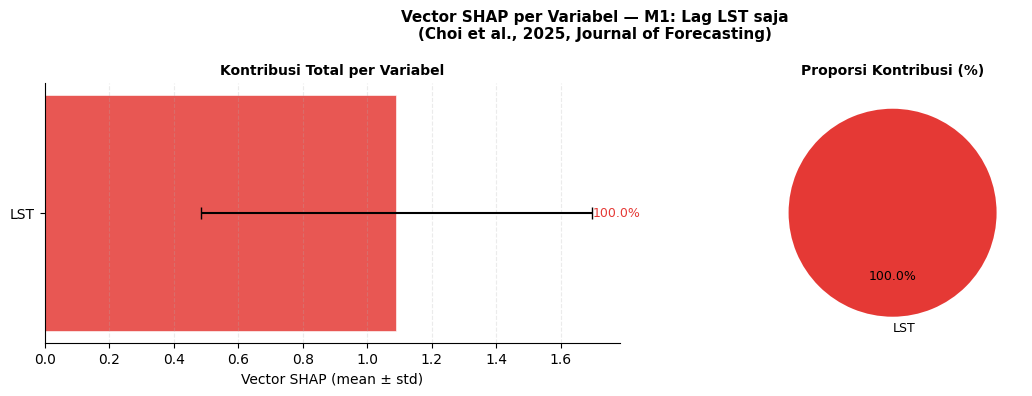


   Model: M2: Lag LST (per Cluster)
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.979716         0.551087            100.0
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_vector_M2_LagLST_byCluster.png


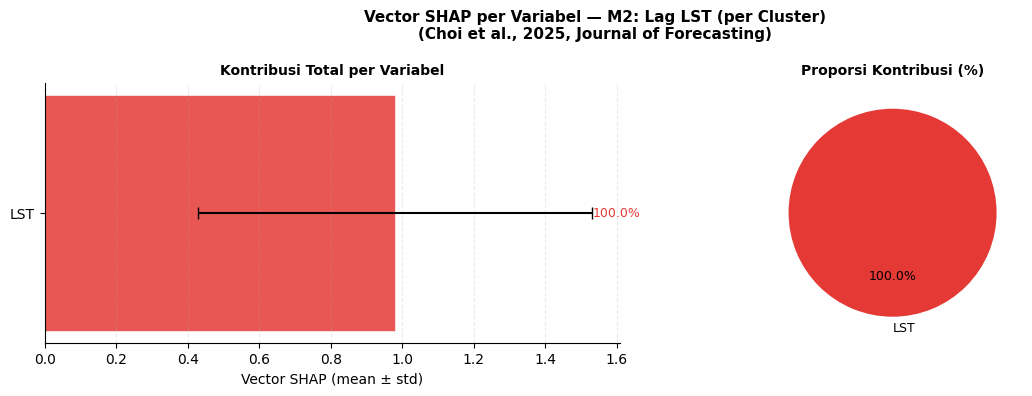


   Model: M3: Lag LST + NDVI + NDBI
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.737086         0.533681            59.68
    NDBI       6          0.283445         0.108505            22.95
    NDVI       6          0.214595         0.077617            17.37
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_vector_M3_LagAll.png


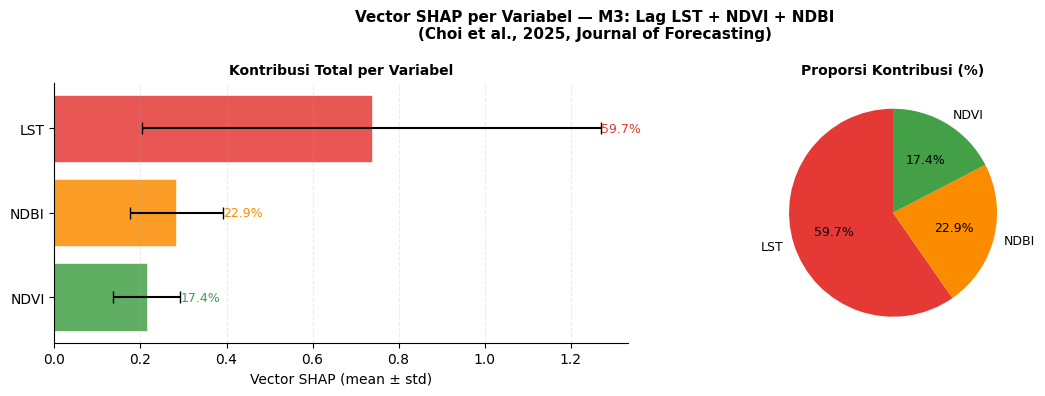


   Model: M4: Lag LST + NDVI + NDBI (per Cluster)
variable  n_lags  vector_shap_mean  vector_shap_std  vector_shap_pct
     LST       5          0.647157         0.464537            57.34
    NDBI       6          0.289160         0.138791            25.62
    NDVI       6          0.192229         0.082182            17.03
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_vector_M4_LagAll_byCluster.png


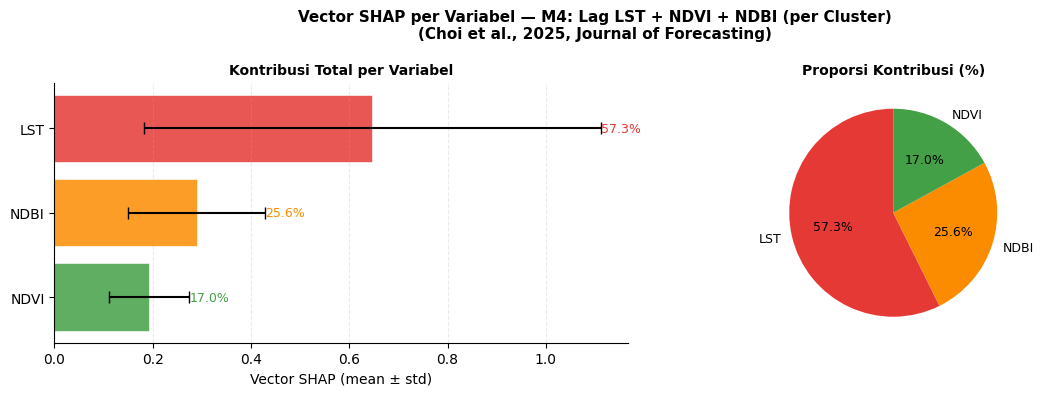


[B] SHAP Dependence Plot — Sun et al. (2025)...
    → Interaksi antar fitur temporal terungkap
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_dependence_M4_LagAll_byCluster.png


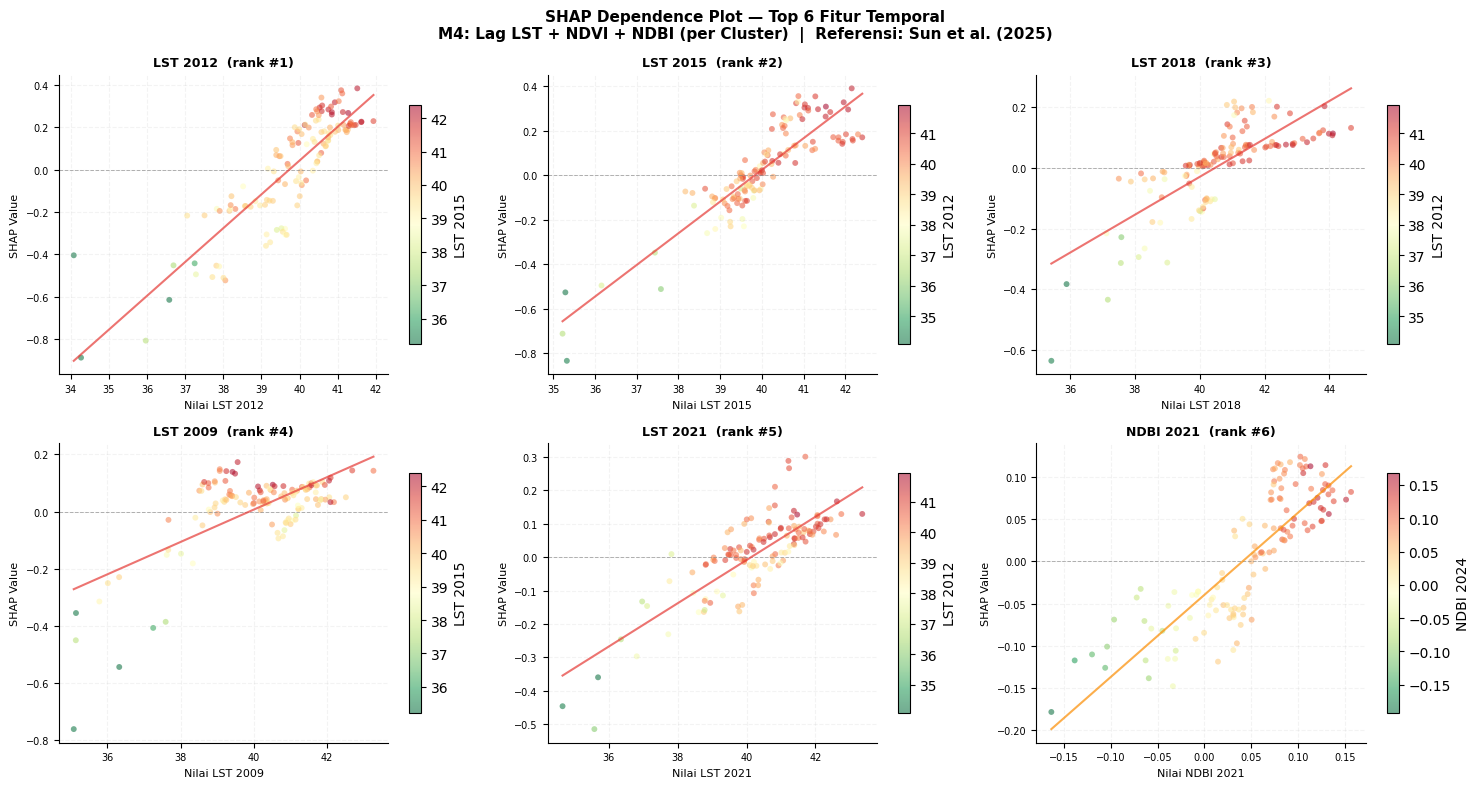


[C] SHAP Fidelity Test — Ozyegen et al. (2022)...
    → Validasi: apakah SHAP benar-benar mencerminkan kontribusi fitur?
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/shap_fidelity_M4_LagAll_byCluster.png


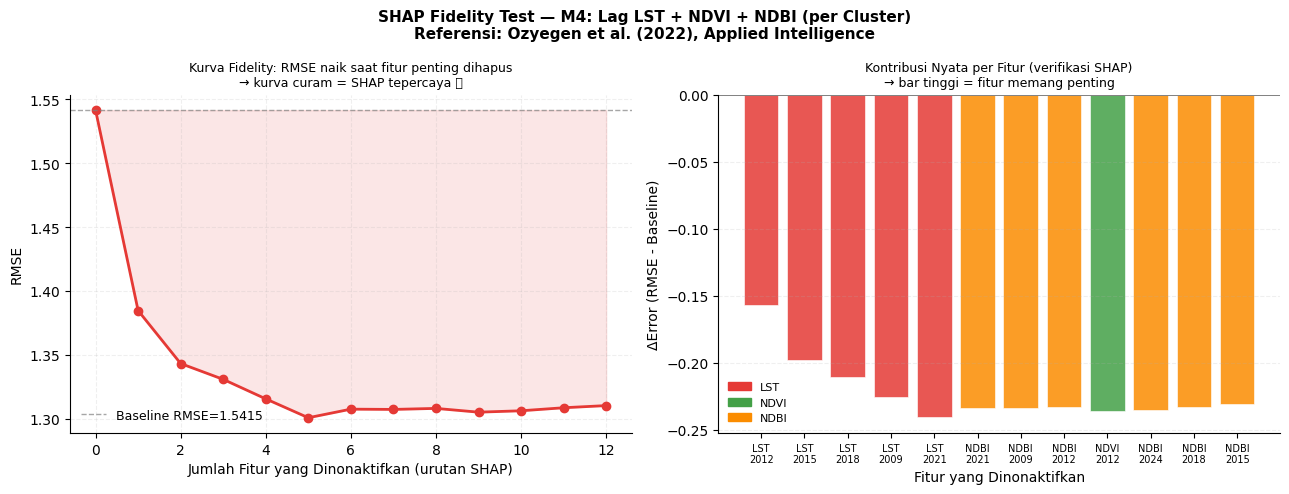


   Ringkasan Fidelity Test:
feature_removed  mean_abs_shap     rmse  delta_rmse
       Baseline            NaN 1.541462    0.000000
       lst_2012       0.215267 1.384678   -0.156784
       lst_2015       0.154880 1.343243   -0.198220
       lst_2018       0.099168 1.330876   -0.210587
       lst_2009       0.090410 1.315623   -0.225840
       lst_2021       0.087432 1.300856   -0.240606
       ndbi2021       0.067509 1.307574   -0.233888
       ndbi2009       0.051917 1.307366   -0.234097
       ndbi2012       0.051402 1.308163   -0.233300
       ndvi2012       0.049043 1.305217   -0.236245
       ndbi2024       0.045054 1.306304   -0.235158
       ndbi2018       0.037120 1.308670   -0.232792
       ndbi2015       0.036157 1.310363   -0.231100

   Korelasi Spearman (|SHAP| vs ΔError): r=0.524, p=0.0800
   ⚠️  SHAP cukup setia namun korelasi tidak kuat

[D] Tabel Numerik Vector SHAP — Siap Dikutip di Skripsi...

════════════════════════════════════════════════════════════════════════

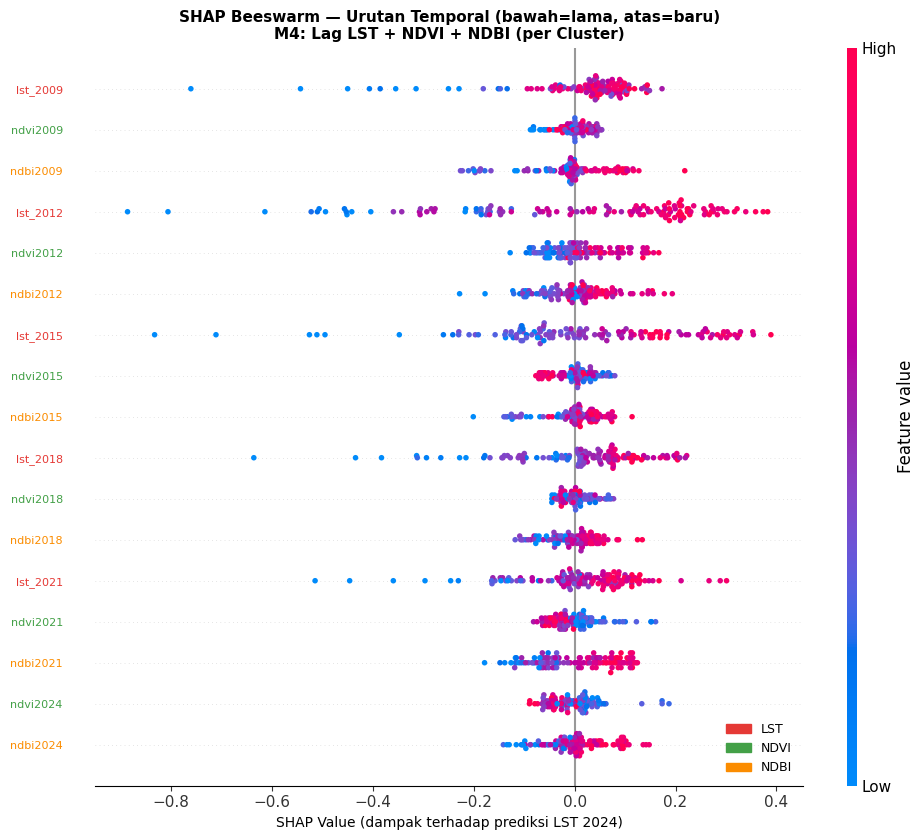


✅ Semua analisis SHAP sesuai jurnal referensi selesai!

📋 Output yang dihasilkan:
  [A] shap_vector_*.png           → Vector SHAP per variabel (Choi et al. 2025)
  [B] shap_dependence_*.png       → Dependence plot interaksi (Sun et al. 2025)
  [C] shap_fidelity_*.png         → Fidelity test validasi SHAP (Ozyegen 2022)
  [D] tabel_vector_shap_summary.csv → Tabel numerik siap dikutip
  [E] shap_beeswarm_temporal_*.png → Beeswarm urutan waktu

📖 Cara mengutip di skripsi:
  [A] "Mengikuti Choi et al. (2025), Vector SHAP dihitung sebagai agregasi
       kontribusi seluruh lag setiap variabel, menghasilkan satu nilai
       representatif per variabel (LST, NDVI, NDBI)."

  [B] "SHAP dependence plot digunakan untuk mengungkap interaksi non-linear
       antar variabel temporal, sesuai pendekatan Sun et al. (2025) pada
       pemodelan siklus ekonomi dengan variabel eksogen multivariat."

  [C] "Validasi fidelity SHAP dilakukan dengan metode perturbation test
       (Ozyegen et al., 2022): f

In [ ]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║     SHAP TIME-AWARE ANALYSIS — SESUAI TIGA JURNAL REFERENSI                ║
║                                                                              ║
║  Jurnal 1: Choi et al. (2025) Journal of Forecasting DOI:10.1002/for.3220   ║
║            → Vector SHAP: agregasi SHAP per variabel (bukan per lag)         ║
║                                                                              ║
║  Jurnal 2: Sun et al. (2025) Technological Forecasting & Social Change       ║
║            → TreeSHAP global + lokal + dependence plot antar variabel        ║
║                                                                              ║
║  Jurnal 3: Ozyegen et al. (2022) Applied Intelligence DOI:10.1007/s10489    ║
║            → Fidelity test: validasi apakah SHAP benar-benar setia           ║
║              pada prediksi model (perturbation-based evaluation)              ║
║                                                                              ║
║  TAMBAHAN BARU vs kode sebelumnya:                                           ║
║  [A] compute_vector_shap()  — Choi et al. 2025                              ║
║  [B] plot_shap_dependence() — Sun et al. 2025                               ║
║  [C] shap_fidelity_test()   — Ozyegen et al. 2022                           ║
║  [D] export_shap_table()    — tabel numerik siap kutip di skripsi            ║
║  [E] plot_beeswarm_temporal() — beeswarm dengan urutan waktu                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

PETUNJUK PENGGUNAAN:
  Tempel sel ini SETELAH Sel 12 di notebook Anda.
  Pastikan variabel berikut sudah tersedia dari sel sebelumnya:
    - shap_store   : dict[(cfg_key, 'RF')] = {'sv', 'X', 'feats'}
    - all_results  : dict hasil training semua model
    - MODEL_CONFIGS, cfg_keys, clusters, best_cfg_key_rf
    - TARGET_YEAR, OUTPUT_DIR, CLUSTER_COL
"""

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# UTILITAS UMUM
# ─────────────────────────────────────────────────────────────────────────────

def extract_year(feat_name: str):
    """Ekstrak tahun dari nama fitur, misal 'lst_2021' → 2021."""
    m = re.search(r'(19|20)\d{2}', feat_name)
    return int(m.group()) if m else None


def get_var_type(feat_name: str) -> str:
    """Klasifikasi LST / NDVI / NDBI / LAINNYA dari nama fitur."""
    fn = feat_name.upper().replace('_', '').replace('-', '')
    for vtype in ['NDBI', 'NDVI', 'LST']:
        if fn.startswith(vtype):
            return vtype
    return 'LAINNYA'


COLOR_VAR = {'LST': '#e53935', 'NDVI': '#43a047',
             'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}


# ═════════════════════════════════════════════════════════════════════════════
# [A] VECTOR SHAP — Choi et al. (2025), Journal of Forecasting
#
#   Inovasi:
#   Standard SHAP → satu nilai per (lag × variabel) → sulit dibaca jika 15+ fitur
#   Vector SHAP   → satu nilai per variabel (agregasi seluruh lagnya)
#                → "seberapa besar kontribusi SEMUA lag LST terhadap prediksi?"
#
#   Cara kerja (sesuai paper Choi et al. 2025):
#     φ_vector(variabel_j) = Σ_{k: fitur dari variabel_j} |φ_k|
#   Di mana φ_k adalah SHAP value standar untuk lag ke-k dari variabel j.
#   Ini mengukur total kontribusi satu variabel (atas semua lag historisnya).
# ═════════════════════════════════════════════════════════════════════════════

def compute_vector_shap(shap_values: np.ndarray,
                        feature_names: list) -> pd.DataFrame:
    """
    Hitung Vector SHAP per variabel (Choi et al., 2025, J. of Forecasting).

    Aggregasi: φ_vector(var) = mean sample dari (sum |SHAP| semua lag var itu)
    Ini memberikan satu nilai skalar per variabel yang merangkum kontribusi
    seluruh horizon historisnya terhadap prediksi.

    Returns
    -------
    DataFrame dengan kolom: variable, n_lags, vector_shap_mean,
                             vector_shap_std, vector_shap_pct
    """
    # Kelompokkan indeks fitur per variabel
    var_groups: dict[str, list[int]] = {}
    for i, feat in enumerate(feature_names):
        vtype = get_var_type(feat)
        var_groups.setdefault(vtype, []).append(i)

    records = []
    for var, idxs in var_groups.items():
        # Untuk setiap sampel: jumlah |SHAP| dari semua lag variabel ini
        per_sample = np.abs(shap_values[:, idxs]).sum(axis=1)  # (n_samples,)
        records.append({
            'variable'         : var,
            'n_lags'           : len(idxs),
            'vector_shap_mean' : per_sample.mean(),
            'vector_shap_std'  : per_sample.std(),
        })

    df = pd.DataFrame(records).sort_values('vector_shap_mean', ascending=False)
    total = df['vector_shap_mean'].sum()
    df['vector_shap_pct'] = (df['vector_shap_mean'] / total * 100).round(2)
    df = df.reset_index(drop=True)
    return df


def plot_vector_shap(df_vector: pd.DataFrame, model_label: str,
                     save_path=None):
    """
    Bar chart Vector SHAP per variabel.
    Berbeda dari bar plot biasa yang menampilkan 15+ lag,
    ini ringkas: satu bar per variabel (LST, NDVI, NDBI).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Vector SHAP per Variabel — {model_label}\n'
                 f'(Choi et al., 2025, Journal of Forecasting)',
                 fontsize=11, fontweight='bold')

    # Subplot kiri: bar chart magnitude
    colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df_vector['variable']]
    axes[0].barh(df_vector['variable'][::-1],
                 df_vector['vector_shap_mean'][::-1],
                 xerr=df_vector['vector_shap_std'][::-1],
                 color=colors[::-1], alpha=0.85, capsize=4,
                 edgecolor='white', linewidth=0.5)
    axes[0].set_xlabel('Vector SHAP (mean ± std)', fontsize=10)
    axes[0].set_title('Kontribusi Total per Variabel', fontsize=10, fontweight='bold')
    for i, (_, row) in enumerate(df_vector.iloc[::-1].iterrows()):
        axes[0].text(row['vector_shap_mean'] + row['vector_shap_std'] + 0.001,
                     i, f'{row["vector_shap_pct"]:.1f}%',
                     va='center', fontsize=9,
                     color=COLOR_VAR.get(row['variable'], '#9e9e9e'))
    axes[0].grid(axis='x', alpha=0.25, linestyle='--')
    sns.despine(ax=axes[0])

    # Subplot kanan: pie chart proporsi
    wedge_colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df_vector['variable']]
    axes[1].pie(df_vector['vector_shap_mean'],
                labels=df_vector['variable'],
                colors=wedge_colors,
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 9})
    axes[1].set_title('Proporsi Kontribusi (%)', fontsize=10, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()
    return df_vector


# ═════════════════════════════════════════════════════════════════════════════
# [B] SHAP DEPENDENCE PLOT — Sun et al. (2025), Tech. Forecasting & Social Change
#
#   Inovasi:
#   Sun et al. tidak hanya melihat kontribusi marginal satu variabel,
#   tapi juga mengungkap INTERAKSI antara dua variabel:
#   "Saat LST 2012 tinggi, apakah NDBI 2021 memperkuat atau melemahkan efeknya?"
#
#   SHAP dependence plot: scatter φ(fitur_X) vs nilai fitur_X,
#   dengan warna menunjukkan nilai fitur_interaksi Y.
#   Pola yang muncul mengindikasikan interaksi non-linear.
# ═════════════════════════════════════════════════════════════════════════════

def plot_shap_dependence_temporal(shap_values: np.ndarray,
                                  X_data: np.ndarray,
                                  feature_names: list,
                                  model_label: str,
                                  n_top: int = 6,
                                  save_path=None):
    """
    SHAP Dependence Plot untuk top-n fitur temporal (Sun et al., 2025).

    Untuk setiap fitur terpenting (berdasar mean |SHAP|), buat scatter:
      - sumbu X: nilai aktual fitur tersebut
      - sumbu Y: nilai SHAP fitur tersebut
      - warna:   nilai fitur interaksi otomatis (fitur dengan korelasi SHAP tertinggi)

    Ini mengungkap apakah efek suatu lag bersifat linear atau non-linear,
    dan apakah ada interaksi dengan lag/variabel lain.
    """
    mean_abs = np.abs(shap_values).mean(axis=0)
    # Ambil hanya fitur bertahun
    timed_idx = [(i, f) for i, f in enumerate(feature_names)
                 if extract_year(f) is not None]
    timed_idx_sorted = sorted(timed_idx,
                               key=lambda x: mean_abs[x[0]], reverse=True)
    top_feats = timed_idx_sorted[:n_top]

    n_cols = 3
    n_rows = int(np.ceil(len(top_feats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows))
    axes_flat = axes.flatten() if len(top_feats) > 1 else [axes]

    fig.suptitle(f'SHAP Dependence Plot — Top {n_top} Fitur Temporal\n'
                 f'{model_label}  |  Referensi: Sun et al. (2025)',
                 fontsize=11, fontweight='bold')

    for ax, (feat_idx, feat_name) in zip(axes_flat, top_feats):
        sv_col = shap_values[:, feat_idx]      # SHAP values fitur ini
        feat_vals = X_data[:, feat_idx]        # nilai aktual fitur ini
        year  = extract_year(feat_name)
        vtype = get_var_type(feat_name)

        # Temukan fitur interaksi otomatis: fitur lain yang korelasinya
        # tertinggi dengan shap_values kolom ini (metode Sun et al.)
        corr_with_others = []
        for j in range(shap_values.shape[1]):
            if j == feat_idx:
                continue
            r, _ = spearmanr(X_data[:, j], sv_col)
            corr_with_others.append((j, abs(r)))
        best_interact_idx = max(corr_with_others, key=lambda x: x[1])[0]
        interact_vals = X_data[:, best_interact_idx]
        interact_name = feature_names[best_interact_idx]

        sc = ax.scatter(feat_vals, sv_col,
                        c=interact_vals, cmap='RdYlGn_r',
                        alpha=0.55, s=18, edgecolors='none')
        plt.colorbar(sc, ax=ax,
                     label=f'{get_var_type(interact_name)} {extract_year(interact_name) or ""}',
                     shrink=0.8)
        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.6)

        # Trendline
        z = np.polyfit(feat_vals, sv_col, 1)
        p = np.poly1d(z)
        xsort = np.sort(feat_vals)
        ax.plot(xsort, p(xsort), color=COLOR_VAR.get(vtype, '#888'),
                linewidth=1.5, linestyle='-', alpha=0.7)

        ax.set_title(f'{vtype} {year}  (rank #{timed_idx_sorted.index((feat_idx, feat_name))+1})',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel(f'Nilai {vtype} {year}', fontsize=8)
        ax.set_ylabel('SHAP Value', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.15, linestyle='--')
        sns.despine(ax=ax)

    for ax in axes_flat[len(top_feats):]:
        ax.set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# [C] FIDELITY TEST — Ozyegen et al. (2022), Applied Intelligence
#
#   Inovasi:
#   Ozyegen et al. mempertanyakan: "SHAP mengklaim fitur X berkontribusi besar,
#   tapi apakah benar demikian? Bagaimana jika kita menghapus fitur itu?"
#
#   Metode (adaptasi AOPCR dari paper):
#   1. Urutkan fitur dari SHAP terbesar ke terkecil
#   2. Satu per satu, matikan (zero-out) fitur tersebut
#   3. Ukur perubahan error prediksi setiap kali penghapusan
#   4. Jika SHAP akurat: menghapus fitur ber-SHAP tinggi harus menaikkan error lebih besar
#
#   Interpretasi:
#   - Kurva yang turun tajam = SHAP setia (faithfully) menjelaskan model
#   - Kurva yang datar = SHAP tidak benar-benar mencerminkan kontribusi fitur
# ═════════════════════════════════════════════════════════════════════════════

def shap_fidelity_test(model, shap_values: np.ndarray,
                       X_test: np.ndarray, y_test: np.ndarray,
                       feature_names: list, model_label: str,
                       n_steps: int = None, save_path=None) -> pd.DataFrame:
    """
    Perturbation-based Fidelity Test untuk SHAP (Ozyegen et al., 2022).

    Prosedur:
      1. Prediksi baseline → hitung RMSE
      2. Matikan fitur ber-SHAP tertinggi (set ke mean) satu per satu
      3. Plot RMSE sebagai fungsi jumlah fitur yang dimatikan
      4. Kurva curam = SHAP faithfully menjelaskan model ✅

    Returns
    -------
    DataFrame ringkasan: fitur yang dimatikan, urutan SHAP, delta RMSE
    """
    from sklearn.metrics import mean_squared_error

    # Urutkan fitur berdasar mean |SHAP| descending
    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_order = np.argsort(mean_abs)[::-1]   # indeks dari paling penting

    if n_steps is None:
        n_steps = min(len(feature_names), 15)  # maksimal 15 langkah

    # Baseline RMSE (tanpa penghapusan fitur)
    y_pred_base = model.predict(X_test)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

    # Iteratif matikan fitur
    X_perturbed = X_test.copy()
    feature_means = X_test.mean(axis=0)

    records = [{'step': 0, 'n_removed': 0,
                'feature_removed': 'Baseline',
                'rmse': rmse_base, 'delta_rmse': 0.0,
                'mean_abs_shap': np.nan}]

    for step in range(1, n_steps + 1):
        feat_idx  = shap_order[step - 1]
        feat_name = feature_names[feat_idx]

        # Set fitur ini ke mean (neutralize)
        X_perturbed[:, feat_idx] = feature_means[feat_idx]
        y_pred_new = model.predict(X_perturbed)
        rmse_new   = np.sqrt(mean_squared_error(y_test, y_pred_new))

        records.append({
            'step'           : step,
            'n_removed'      : step,
            'feature_removed': feat_name,
            'rmse'           : rmse_new,
            'delta_rmse'     : rmse_new - rmse_base,
            'mean_abs_shap'  : mean_abs[feat_idx],
        })

    df_fid = pd.DataFrame(records)

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'SHAP Fidelity Test — {model_label}\n'
                 f'Referensi: Ozyegen et al. (2022), Applied Intelligence',
                 fontsize=11, fontweight='bold')

    # Kiri: RMSE vs jumlah fitur dimatikan
    axes[0].plot(df_fid['n_removed'], df_fid['rmse'],
                 marker='o', color='#e53935', linewidth=2, markersize=6)
    axes[0].axhline(rmse_base, color='gray', linestyle='--',
                    linewidth=1, alpha=0.7, label=f'Baseline RMSE={rmse_base:.4f}')
    axes[0].fill_between(df_fid['n_removed'],
                          rmse_base, df_fid['rmse'],
                          alpha=0.12, color='#e53935')
    axes[0].set_xlabel('Jumlah Fitur yang Dinonaktifkan (urutan SHAP)', fontsize=10)
    axes[0].set_ylabel('RMSE', fontsize=10)
    axes[0].set_title('Kurva Fidelity: RMSE naik saat fitur penting dihapus\n'
                       '→ kurva curam = SHAP tepercaya ✅', fontsize=9)
    axes[0].legend(fontsize=9, frameon=False)
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[0].grid(alpha=0.2, linestyle='--')
    sns.despine(ax=axes[0])

    # Kanan: Delta RMSE per fitur (bar chart)
    df_plot = df_fid[df_fid['step'] > 0].copy()
    bar_colors = [COLOR_VAR.get(get_var_type(f), '#9e9e9e')
                  for f in df_plot['feature_removed']]
    feat_labels = [f"{get_var_type(f)}\n{extract_year(f) or ''}"
                   for f in df_plot['feature_removed']]

    axes[1].bar(range(len(df_plot)), df_plot['delta_rmse'],
                color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    axes[1].axhline(0, color='gray', linewidth=0.7)
    axes[1].set_xticks(range(len(df_plot)))
    axes[1].set_xticklabels(feat_labels, fontsize=7, rotation=0)
    axes[1].set_xlabel('Fitur yang Dinonaktifkan', fontsize=10)
    axes[1].set_ylabel('ΔError (RMSE - Baseline)', fontsize=10)
    axes[1].set_title('Kontribusi Nyata per Fitur (verifikasi SHAP)\n'
                       '→ bar tinggi = fitur memang penting', fontsize=9)

    # Legend warna
    handles = [mpatches.Patch(color=COLOR_VAR[v], label=v)
               for v in ['LST', 'NDVI', 'NDBI'] if v in COLOR_VAR]
    axes[1].legend(handles=handles, fontsize=8, frameon=False)
    axes[1].grid(axis='y', alpha=0.2, linestyle='--')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_fid


# ═════════════════════════════════════════════════════════════════════════════
# [D] TABEL NUMERIK VECTOR SHAP — Siap Dikutip di Skripsi
#
#   Menghasilkan tabel ringkasan yang bisa langsung masuk ke bab metodologi
#   atau hasil, sesuai format tabel yang umum di ketiga jurnal referensi.
# ═════════════════════════════════════════════════════════════════════════════

def export_shap_summary_table(shap_store: dict,
                               model_configs: dict,
                               cfg_keys: list,
                               feature_names_ref: list,
                               save_path_csv=None,
                               save_path_print=True) -> pd.DataFrame:
    """
    Buat tabel numerik lengkap: per model × per variabel.
    Berisi: Vector SHAP, mean |SHAP| lag terkuat, ranking, % kontribusi.
    """
    rows = []
    for cfg_key in cfg_keys:
        if (cfg_key, 'RF') not in shap_store:
            continue
        store   = shap_store[(cfg_key, 'RF')]
        sv      = store['sv']
        feats   = store['feats']
        label   = model_configs[cfg_key]['label']

        df_vec = compute_vector_shap(sv, feats)

        # Tambahkan: lag terkuat untuk setiap variabel
        for _, row in df_vec.iterrows():
            # Cari lag dengan SHAP tertinggi dalam variabel ini
            var_feat_idxs = [(i, f) for i, f in enumerate(feats)
                             if get_var_type(f) == row['variable']]
            if var_feat_idxs:
                mean_abs = np.abs(sv).mean(axis=0)
                best_idx = max(var_feat_idxs, key=lambda x: mean_abs[x[0]])
                best_year = extract_year(best_idx[1])
                best_shap = mean_abs[best_idx[0]]
            else:
                best_year, best_shap = None, None

            rows.append({
                'Model'             : label,
                'Variabel'          : row['variable'],
                'Jumlah Lag'        : row['n_lags'],
                'Vector SHAP (mean)': round(row['vector_shap_mean'], 5),
                'Vector SHAP (std)' : round(row['vector_shap_std'], 5),
                'Kontribusi (%)'    : round(row['vector_shap_pct'], 2),
                'Lag Terkuat'       : best_year,
                'SHAP Lag Terkuat'  : round(best_shap, 5) if best_shap else None,
            })

    df_table = pd.DataFrame(rows)

    if save_path_print:
        print('\n' + '═' * 90)
        print('  TABEL VECTOR SHAP — SIAP DIKUTIP DI SKRIPSI')
        print('  Referensi: Choi et al. (2025), Journal of Forecasting')
        print('═' * 90)
        print(df_table.to_string(index=False))
        print('═' * 90)

    if save_path_csv:
        df_table.to_csv(save_path_csv, index=False)
        print(f'💾 Tabel disimpan: {save_path_csv}')

    return df_table


# ═════════════════════════════════════════════════════════════════════════════
# [E] BEESWARM PLOT TEMPORAL — Ordered by Year, not Importance
#
#   Gap dari kode lama: beeswarm standard mengurutkan fitur by importance.
#   Versi ini mengurutkan fitur berdasar TAHUN (temporal order),
#   sehingga sumbu Y menjadi timeline.
# ═════════════════════════════════════════════════════════════════════════════

def plot_beeswarm_temporal(shap_values: np.ndarray,
                           X_data: np.ndarray,
                           feature_names: list,
                           model_label: str,
                           save_path=None):
    """
    Beeswarm/summary plot SHAP dengan fitur diurutkan berdasar TAHUN,
    bukan berdasar importance (berbeda dari shap.summary_plot default).

    Urutan dari bawah ke atas = lag terjauh → lag terdekat ke target.
    """
    # Sort fitur berdasar tahun ascending (paling lama di bawah)
    timed = [(i, f) for i, f in enumerate(feature_names)
             if extract_year(f) is not None]
    non_timed = [(i, f) for i, f in enumerate(feature_names)
                 if extract_year(f) is None]

    # Urutkan: non-timed dulu (paling bawah), lalu timed ascending year
    timed_sorted = sorted(timed, key=lambda x: extract_year(x[1]))
    ordered = non_timed + timed_sorted

    ordered_idx   = [x[0] for x in ordered]
    ordered_names = [x[1] for x in ordered]

    sv_ordered = shap_values[:, ordered_idx]
    X_ordered  = X_data[:, ordered_idx]

    # Format label: tambah tahun dan warna berdasar vtype
    label_colors = [COLOR_VAR.get(get_var_type(f), '#9e9e9e')
                    for f in ordered_names]

    fig, ax = plt.subplots(figsize=(10, max(6, len(ordered_names) * 0.5)))
    plt.sca(ax)

    shap.summary_plot(
        sv_ordered,
        X_ordered,
        feature_names=ordered_names,
        show=False,
        plot_size=None,
        max_display=len(ordered_names),
        sort=False,   # ← kritis: jangan re-sort by importance
    )

    # Warnai tick label sesuai vtype
    yticks = ax.get_yticklabels()
    for tick, color in zip(yticks, label_colors[::-1]):  # reversed karena plt arah bawah-atas
        tick.set_color(color)
        tick.set_fontsize(8)

    ax.set_title(f'SHAP Beeswarm — Urutan Temporal (bawah=lama, atas=baru)\n'
                 f'{model_label}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP Value (dampak terhadap prediksi LST 2024)', fontsize=10)

    # Tambah legend warna variabel
    handles = [mpatches.Patch(color=COLOR_VAR[v], label=v)
               for v in ['LST', 'NDVI', 'NDBI']]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA — Jalankan semua fungsi baru
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📚 ANALISIS SHAP SESUAI TIGA JURNAL REFERENSI')
print('=' * 70)

# ── Ambil data model terbaik RF ───────────────────────────────────────────
best_store  = shap_store[(best_cfg_key_rf, 'RF')]
sv_best     = best_store['sv']
X_best      = best_store['X']
feats_best  = best_store['feats']
model_best  = all_results[(best_cfg_key_rf, 'RF')]['model_obj']
y_test_best = all_results[(best_cfg_key_rf, 'RF')]['y_test']
label_best  = MODEL_CONFIGS[best_cfg_key_rf]['label']

# ── [A] VECTOR SHAP — Choi et al. (2025) ─────────────────────────────────
print('\n[A] Vector SHAP per Variabel — Choi et al. (2025)...')
print('    → Agregasi semua lag per variabel menjadi 1 nilai')

for cfg_key in cfg_keys:
    if (cfg_key, 'RF') not in shap_store:
        continue
    store = shap_store[(cfg_key, 'RF')]
    lbl   = MODEL_CONFIGS[cfg_key]['label']

    df_vec = compute_vector_shap(store['sv'], store['feats'])
    print(f'\n   Model: {lbl}')
    print(df_vec.to_string(index=False))

    plot_vector_shap(
        df_vec,
        model_label=lbl,
        save_path=OUTPUT_DIR + f'shap_vector_{cfg_key}.png'
    )

# ── [B] SHAP DEPENDENCE PLOT — Sun et al. (2025) ─────────────────────────
print('\n[B] SHAP Dependence Plot — Sun et al. (2025)...')
print('    → Interaksi antar fitur temporal terungkap')

plot_shap_dependence_temporal(
    shap_values=sv_best,
    X_data=X_best,
    feature_names=feats_best,
    model_label=label_best,
    n_top=6,
    save_path=OUTPUT_DIR + f'shap_dependence_{best_cfg_key_rf}.png'
)

# ── [C] FIDELITY TEST — Ozyegen et al. (2022) ────────────────────────────
print('\n[C] SHAP Fidelity Test — Ozyegen et al. (2022)...')
print('    → Validasi: apakah SHAP benar-benar mencerminkan kontribusi fitur?')

df_fidelity = shap_fidelity_test(
    model=model_best,
    shap_values=sv_best,
    X_test=X_best,
    y_test=y_test_best,
    feature_names=feats_best,
    model_label=label_best,
    n_steps=min(12, len(feats_best)),
    save_path=OUTPUT_DIR + f'shap_fidelity_{best_cfg_key_rf}.png'
)

print('\n   Ringkasan Fidelity Test:')
print(df_fidelity[['feature_removed', 'mean_abs_shap',
                    'rmse', 'delta_rmse']].to_string(index=False))

# Cek apakah korelasi SHAP magnitude dengan delta RMSE positif
# (sesuai teori Ozyegen: fitur ber-SHAP tinggi seharusnya punya delta RMSE tinggi)
df_fid_nz = df_fidelity[df_fidelity['step'] > 0].dropna()
if len(df_fid_nz) > 3:
    r_corr, p_corr = spearmanr(df_fid_nz['mean_abs_shap'], df_fid_nz['delta_rmse'])
    print(f'\n   Korelasi Spearman (|SHAP| vs ΔError): r={r_corr:.3f}, p={p_corr:.4f}')
    if r_corr > 0.5 and p_corr < 0.05:
        print('   ✅ SHAP faithfully mencerminkan kontribusi fitur (korelasi positif signifikan)')
    elif r_corr > 0:
        print('   ⚠️  SHAP cukup setia namun korelasi tidak kuat')
    else:
        print('   ❌ SHAP mungkin tidak sepenuhnya mencerminkan kontribusi fitur sesungguhnya')

# ── [D] TABEL NUMERIK — Siap Dikutip ─────────────────────────────────────
print('\n[D] Tabel Numerik Vector SHAP — Siap Dikutip di Skripsi...')

df_table_summary = export_shap_summary_table(
    shap_store=shap_store,
    model_configs=MODEL_CONFIGS,
    cfg_keys=cfg_keys,
    feature_names_ref=feats_best,
    save_path_csv=OUTPUT_DIR + 'tabel_vector_shap_summary.csv',
    save_path_print=True
)

# ── [E] BEESWARM TEMPORAL ─────────────────────────────────────────────────
print('\n[E] Beeswarm Plot Temporal — Urutan Waktu (bukan importance)...')

plot_beeswarm_temporal(
    shap_values=sv_best,
    X_data=X_best,
    feature_names=feats_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'shap_beeswarm_temporal_{best_cfg_key_rf}.png'
)

# ── SELESAI ────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ Semua analisis SHAP sesuai jurnal referensi selesai!')
print('=' * 70)
print("""
📋 Output yang dihasilkan:
  [A] shap_vector_*.png           → Vector SHAP per variabel (Choi et al. 2025)
  [B] shap_dependence_*.png       → Dependence plot interaksi (Sun et al. 2025)
  [C] shap_fidelity_*.png         → Fidelity test validasi SHAP (Ozyegen 2022)
  [D] tabel_vector_shap_summary.csv → Tabel numerik siap dikutip
  [E] shap_beeswarm_temporal_*.png → Beeswarm urutan waktu

📖 Cara mengutip di skripsi:
  [A] "Mengikuti Choi et al. (2025), Vector SHAP dihitung sebagai agregasi
       kontribusi seluruh lag setiap variabel, menghasilkan satu nilai
       representatif per variabel (LST, NDVI, NDBI)."

  [B] "SHAP dependence plot digunakan untuk mengungkap interaksi non-linear
       antar variabel temporal, sesuai pendekatan Sun et al. (2025) pada
       pemodelan siklus ekonomi dengan variabel eksogen multivariat."

  [C] "Validasi fidelity SHAP dilakukan dengan metode perturbation test
       (Ozyegen et al., 2022): fitur dinonaktifkan secara berurutan sesuai
       ranking SHAP, kemudian kenaikan RMSE diukur untuk memverifikasi
       bahwa SHAP benar-benar mencerminkan kontribusi nyata setiap fitur."
""")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PALET WARNA KLASTER (GLOBAL)
# ─────────────────────────────────────────────────────────────────────────────
CLUSTER_PALETTE = [
    '#3949ab', '#00897b', '#e53935', '#8e24aa',
    '#f57c00', '#0277bd', '#558b2f', '#6d4c41'
]


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Bar chart Vector SHAP per klaster (subplot per klaster)
# ─────────────────────────────────────────────────────────────────────────────
def plot_vector_shap_per_cluster(df_vec: pd.DataFrame,
                                  model_label: str,
                                  save_path=None):

    cluster_ids = sorted(df_vec['cluster'].unique())
    n_cl = len(cluster_ids)

    fig, axes = plt.subplots(
        1, n_cl,
        figsize=(4.5 * n_cl, 5),
        sharey=False
    )

    if n_cl == 1:
        axes = [axes]

    fig.suptitle(
        f'Vector SHAP per Variabel — Tiap Klaster\n'
        f'Model: {model_label}  |  Referensi: Choi et al. (2025)',
        fontsize=12, fontweight='bold'
    )

    for ax, cl in zip(axes, cluster_ids):

        sub = df_vec[df_vec['cluster'] == cl].copy()
        sub = sub.sort_values('vector_shap_mean', ascending=True)

        cluster_color = CLUSTER_PALETTE[int(cl) % len(CLUSTER_PALETTE)]

        colors = [COLOR_VAR.get(v, '#9e9e9e') for v in sub['variable']]
        n_samp = sub['n_samples'].iloc[0]

        ax.barh(
            sub['variable'],
            sub['vector_shap_mean'],
            xerr=sub['vector_shap_std'],
            color=colors,
            alpha=0.88,
            capsize=5,
            edgecolor='white',
            linewidth=0.6
        )

        # Persentase
        for i, (_, row) in enumerate(sub.iterrows()):
            ax.text(
                row['vector_shap_mean'] + row['vector_shap_std'] + 0.0005,
                i,
                f"{row['vector_shap_pct']:.1f}%",
                va='center',
                fontsize=9,
                color=cluster_color,
                fontweight='bold'
            )

        ax.set_title(
            f'Klaster {cl}\n(n = {n_samp:,})',
            fontsize=10,
            fontweight='bold',
            color=cluster_color
        )

        ax.set_xlabel('Vector SHAP (mean ± std)', fontsize=9)

        if ax == axes[0]:
            ax.set_ylabel('Variabel', fontsize=9)

        ax.grid(axis='x', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Grouped bar chart
# ─────────────────────────────────────────────────────────────────────────────
def plot_vector_shap_grouped(df_vec: pd.DataFrame,
                              model_label: str,
                              save_path=None):

    cluster_ids = sorted(df_vec['cluster'].unique())
    variables   = df_vec['variable'].unique()

    x = np.arange(len(variables))
    width = 0.7 / len(cluster_ids)

    fig, ax = plt.subplots(figsize=(max(8, len(variables) * 2), 5))

    for i, cl in enumerate(cluster_ids):

        sub = df_vec[df_vec['cluster'] == cl].set_index('variable')
        sub = sub.reindex(variables)

        vals  = sub['vector_shap_mean'].values
        errs  = sub['vector_shap_std'].values
        n_s   = int(sub['n_samples'].iloc[0])

        cluster_color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]

        ax.bar(
            x + i * width,
            vals,
            width=width,
            yerr=[errs_low, errs_high],
            color=cluster_color,
            alpha=0.85,
            capsize=4,
            edgecolor='white',
            linewidth=0.5,
            label=f'Klaster {int(cl)} (n={n_s:,})'
        )

    ax.set_xticks(x + width * (len(cluster_ids)-1)/2)
    ax.set_xticklabels(variables)

    ax.set_title(
        f'Perbandingan Vector SHAP Antar Klaster\nModel: {model_label}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Variabel')
    ax.set_ylabel('Vector SHAP')

    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.2, linestyle='--')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4: Radar chart
# ─────────────────────────────────────────────────────────────────────────────
def plot_vector_shap_radar(df_vec: pd.DataFrame,
                            model_label: str,
                            save_path=None):

    cluster_ids = sorted(df_vec['cluster'].unique())
    variables   = df_vec['variable'].unique()

    pivot = df_vec.pivot_table(
        index='cluster',
        columns='variable',
        values='vector_shap_mean'
    )[variables]

    pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min() + 1e-9)

    angles = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw=dict(polar=True)
    )

    for i, cl in enumerate(cluster_ids):

        vals = pivot_norm.loc[cl].tolist()
        vals += vals[:1]

        cluster_color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]
        n_s = int(df_vec[df_vec['cluster'] == cl]['n_samples'].iloc[0])

        ax.plot(
            angles,
            vals,
            linewidth=2.5,
            color=cluster_color,
            label=f'Klaster {int(cl)} (n={n_s:,})'
        )

        ax.fill(
            angles,
            vals,
            alpha=0.08,
            color=cluster_color
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(variables)

    ax.set_title(
        f'Radar Vector SHAP\nModel: {model_label}',
        fontsize=12,
        fontweight='bold'
    )

    ax.legend(frameon=False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5: Dominant lag
# ─────────────────────────────────────────────────────────────────────────────
def plot_dominant_lag_per_cluster(df_vec: pd.DataFrame,
                                   model_label: str,
                                   save_path=None):

    df_plot = df_vec.dropna(subset=['lag_terkuat']).copy()
    df_plot['lag_terkuat'] = df_plot['lag_terkuat'].astype(int)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for _, row in df_plot.iterrows():

        cl = int(row['cluster'])
        cluster_color = CLUSTER_PALETTE[cl % len(CLUSTER_PALETTE)]

        ax.scatter(
            row['cluster'],
            row['lag_terkuat'],
            s=row['shap_lag_terkuat'] * 1200,
            color=cluster_color,
            alpha=0.85,
            edgecolors='white',
            linewidths=0.8
        )

    ax.set_xticks(sorted(df_plot['cluster'].unique()))
    ax.set_xticklabels(
        [f'Klaster {int(c)}'
         for c in sorted(df_plot['cluster'].unique())]
    )

    ax.set_title(
        f'Lag Terkuat per Klaster\nModel: {model_label}',
        fontsize=12,
        fontweight='bold'
    )

    ax.grid(axis='y', alpha=0.2, linestyle='--')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# FUNGSI EKSPOR: CSV siap kutip di skripsi
# ─────────────────────────────────────────────────────────────────────────────

def export_vector_shap_cluster_table(df_vec: pd.DataFrame,
                                      model_label: str,
                                      save_path_csv=None) -> pd.DataFrame:
    """
    Format tabel akhir yang rapi untuk disertakan di skripsi.
    Kolom: Klaster | Variabel | Jumlah Lag | Vector SHAP ± std | % | Lag Terkuat
    """
    df_out = df_vec[[
        'cluster', 'variable', 'n_lags',
        'vector_shap_mean', 'vector_shap_std',
        'vector_shap_pct', 'lag_terkuat',
        'shap_lag_terkuat', 'n_samples'
    ]].copy()

    df_out.columns = [
        'Klaster', 'Variabel', 'Jumlah Lag',
        'Vector SHAP (mean)', 'Vector SHAP (std)',
        'Kontribusi (%)', 'Lag Terkuat (tahun)',
        'SHAP Lag Terkuat', 'N Sampel Test'
    ]

    print('\n' + '═' * 85)
    print(f'  TABEL VECTOR SHAP PER KLASTER — {model_label}')
    print(f'  Referensi: Choi et al. (2025), Journal of Forecasting')
    print('═' * 85)
    print(df_out.to_string(index=False))
    print('═' * 85)

    if save_path_csv:
        df_out.to_csv(save_path_csv, index=False)
        print(f'💾 Tabel disimpan: {save_path_csv}')

    return df_out


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA
# Jalankan untuk semua model yang split_by_cluster (M2 dan M4)
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📐 VECTOR SHAP PER KLASTER — Choi et al. (2025)')
print('=' * 70)

# Tentukan model mana yang split_by_cluster
cluster_cfg_keys = [
    k for k, v in MODEL_CONFIGS.items() if v['split_by_cluster']
]

if not cluster_cfg_keys:
    print('[PERINGATAN] Tidak ada model dengan split_by_cluster=True.')
else:
    for cfg_key in cluster_cfg_keys:
        lbl = MODEL_CONFIGS[cfg_key]['label']
        print(f'\n{"─"*60}')
        print(f'  Model: {lbl}')
        print(f'{"─"*60}')

        # ── Step 1: Hitung SHAP per klaster ──────────────────────────────
        print('\n🔢 Menghitung SHAP per klaster ...')
        shap_cluster = compute_shap_per_cluster(
            cfg_key=cfg_key,
            all_results=all_results,
            clusters=clusters,
            algo='RF'
        )

        # ── Step 2: Hitung Vector SHAP per klaster ────────────────────────
        print('\n📐 Menghitung Vector SHAP (Choi et al., 2025) ...')
        df_vec_cl = compute_vector_shap_per_cluster(shap_cluster)

        # ── Step 3: Cetak & simpan tabel ──────────────────────────────────
        df_tabel = export_vector_shap_cluster_table(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path_csv=OUTPUT_DIR + f'vector_shap_cluster_{cfg_key}.csv'
        )

        # ── Step 4: Plot 1 — Bar per klaster (subplot) ────────────────────
        print('\n📊 Plot 1/4: Bar Chart per Klaster ...')
        plot_vector_shap_per_cluster(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_vector_bar_percluster_{cfg_key}.png'
        )

        # ── Step 5: Plot 2 — Grouped bar chart ────────────────────────────
        print('📊 Plot 2/4: Grouped Bar (perbandingan langsung antar klaster) ...')
        plot_vector_shap_grouped(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_vector_grouped_{cfg_key}.png'
        )

        # ── Step 6: Plot 3 — Heatmap (nilai absolut + persentase) ─────────
        print('🗺️  Plot 3a/4: Heatmap nilai absolut ...')
        plot_vector_shap_heatmap(
            df_vec=df_vec_cl,
            model_label=lbl,
            mode='mean',
            save_path=OUTPUT_DIR + f'shap_vector_heatmap_abs_{cfg_key}.png'
        )

        print('🗺️  Plot 3b/4: Heatmap persentase kontribusi ...')
        plot_vector_shap_heatmap(
            df_vec=df_vec_cl,
            model_label=lbl,
            mode='pct',
            save_path=OUTPUT_DIR + f'shap_vector_heatmap_pct_{cfg_key}.png'
        )

        # ── Step 7: Plot 4 — Radar chart ──────────────────────────────────
        print('🕸️  Plot 4a/4: Radar Chart ...')
        plot_vector_shap_radar(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_vector_radar_{cfg_key}.png'
        )

        # ── Step 8: Plot 5 — Dominant lag scatter ─────────────────────────
        print('🎯 Plot 4b/4: Lag Terkuat per Klaster ...')
        plot_dominant_lag_per_cluster(
            df_vec=df_vec_cl,
            model_label=lbl,
            save_path=OUTPUT_DIR + f'shap_dominant_lag_{cfg_key}.png'
        )


# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ Semua analisis Vector SHAP per klaster selesai!')
print('=' * 70)
print("""
📋 Output yang dihasilkan (per model M2/M4):
  vector_shap_cluster_*.csv           → Tabel numerik siap dikutip
  shap_vector_bar_percluster_*.png    → Bar chart per klaster (subplot)
  shap_vector_grouped_*.png           → Grouped bar: perbandingan antar klaster
  shap_vector_heatmap_abs_*.png       → Heatmap nilai absolut
  shap_vector_heatmap_pct_*.png       → Heatmap persentase kontribusi
  shap_vector_radar_*.png             → Radar: profil dominansi per klaster
  shap_dominant_lag_*.png             → Scatter: lag terkuat per klaster

📖 Template kalimat interpretasi di skripsi:
  "Menggunakan pendekatan Vector SHAP (Choi et al., 2025), kontribusi
   setiap variabel terhadap prediksi LST 2024 dianalisis secara terpisah
   untuk masing-masing klaster. Pada klaster [X], variabel [LST/NDVI/NDBI]
   memberikan kontribusi terbesar (Vector SHAP = [nilai], [persen]%),
   dengan lag tahun [Y] sebagai periode historis paling dominan.
   Sebaliknya, klaster [Z] menunjukkan pola berbeda di mana..."
""")

📐 VECTOR SHAP PER KLASTER — Choi et al. (2025)

────────────────────────────────────────────────────────────
  Model: M2: Lag LST (per Cluster)
────────────────────────────────────────────────────────────

🔢 Menghitung SHAP per klaster ...


NameError: name 'compute_shap_per_cluster' is not defined

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  BOX PLOT — PREDIKSI vs AKTUAL LST PER CLUSTER
#  Visualisasi distribusi prediksi vs aktual per klaster
#  untuk semua konfigurasi model (M1–M4) x RF & SVR
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_boxplot_pred_vs_actual_per_cluster(
    all_results, model_configs, df, cluster_col, target_col,
    clusters, idx_train_global, idx_test_global, output_dir
):
    """
    Membuat box plot berderet: Prediksi vs Aktual LST per cluster
    untuk SEMUA konfigurasi model (M1–M4) x algoritma (RF, SVR).

    Setiap subplot = 1 konfigurasi model + 1 algoritma.
    Di dalam subplot: per cluster ada 2 box (Aktual & Prediksi).
    """
    cfg_keys = list(model_configs.keys())
    algos    = ['RF', 'SVR']
    n_cfgs   = len(cfg_keys)
    n_algos  = len(algos)

    fig, axes = plt.subplots(
        n_cfgs, n_algos,
        figsize=(7 * n_algos, 5 * n_cfgs),
        squeeze=False
    )

    fig.suptitle(
        f'Box Plot Prediksi vs Aktual LST {TARGET_YEAR} per Cluster\n'
        f'(Perbandingan distribusi untuk setiap konfigurasi model)',
        fontsize=14, fontweight='bold', y=1.01
    )

    # Warna konsisten
    color_actual  = '#2196F3'   # biru
    color_predict = '#FF5722'   # oranye-merah

    for row_i, cfg_key in enumerate(cfg_keys):
        cfg       = model_configs[cfg_key]
        is_split  = cfg['split_by_cluster']

        for col_j, algo in enumerate(algos):
            ax  = axes[row_i, col_j]
            res = all_results.get((cfg_key, algo))

            if res is None:
                ax.set_visible(False)
                continue

            # Kumpulkan data per cluster
            box_data = []   # list of dicts {cluster, type, values}

            if is_split:
                # Model per cluster: gunakan cluster_y_test dan prediksi per cluster
                for cl in clusters:
                    y_true_cl = res['cluster_y_test'][cl]
                    # Re-predict menggunakan model per cluster
                    cl_model  = res['cluster_models'][cl][algo]
                    X_te_cl   = res['cluster_X_test'][cl]
                    y_pred_cl = cl_model.predict(X_te_cl)

                    box_data.append({'cluster': int(cl), 'type': 'Aktual',   'values': y_true_cl})
                    box_data.append({'cluster': int(cl), 'type': 'Prediksi', 'values': y_pred_cl})
            else:
                # Model global: split y_test berdasarkan cluster dari df
                y_true_all = res['y_test']
                y_pred_all = res['y_pred_test']
                # Cluster info dari test indices
                cluster_test = df.loc[idx_test_global, cluster_col].values

                for cl in clusters:
                    mask = cluster_test == cl
                    if mask.sum() == 0:
                        continue
                    box_data.append({'cluster': int(cl), 'type': 'Aktual',   'values': y_true_all[mask]})
                    box_data.append({'cluster': int(cl), 'type': 'Prediksi', 'values': y_pred_all[mask]})

            # Plot box plot berderet
            positions = []
            labels    = []
            colors_bp = []
            all_vals  = []

            pos = 0
            cluster_centers = []
            for i, cl in enumerate(clusters):
                # Cari data untuk cluster ini
                actual_data  = [d for d in box_data if d['cluster'] == int(cl) and d['type'] == 'Aktual']
                predict_data = [d for d in box_data if d['cluster'] == int(cl) and d['type'] == 'Prediksi']

                if not actual_data or not predict_data:
                    continue

                # Posisi: Aktual, Prediksi, lalu gap
                positions.append(pos)
                all_vals.append(actual_data[0]['values'])
                colors_bp.append(color_actual)

                positions.append(pos + 1)
                all_vals.append(predict_data[0]['values'])
                colors_bp.append(color_predict)

                cluster_centers.append(pos + 0.5)
                labels.append(f'Klaster {int(cl)}')

                pos += 3  # gap antar cluster

            # Buat boxplot
            bp = ax.boxplot(
                all_vals,
                positions=positions,
                widths=0.7,
                patch_artist=True,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='white',
                              markeredgecolor='black', markersize=5),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1),
                flierprops=dict(marker='o', markersize=3, alpha=0.5)
            )

            # Set warna per box
            for patch, color in zip(bp['boxes'], colors_bp):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
                patch.set_edgecolor('black')
                patch.set_linewidth(0.8)

            # Labels & styling
            ax.set_xticks(cluster_centers)
            ax.set_xticklabels(labels, fontsize=9)

            # Metrik di judul
            r2_val   = res.get('Test_R2', 0)
            rmse_val = res.get('Test_RMSE', 0)
            ax.set_title(
                f'{cfg["label"]} — {algo}\n'
                f'R²={r2_val:.4f}, RMSE={rmse_val:.4f}',
                fontsize=10, fontweight='bold'
            )
            ax.set_ylabel('LST (°C)', fontsize=9)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            sns.despine(ax=ax)

    # Legend global
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_actual,  alpha=0.6, edgecolor='black', label='Aktual'),
        Patch(facecolor=color_predict, alpha=0.6, edgecolor='black', label='Prediksi'),
    ]
    fig.legend(
        handles=legend_elements,
        loc='upper right',
        fontsize=11,
        frameon=True,
        edgecolor='gray',
        fancybox=True,
        title='Tipe Data',
        title_fontsize=11
    )

    plt.tight_layout()
    fname = output_dir + 'boxplot_pred_vs_actual_per_cluster.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Disimpan: {fname}')
    plt.close()


# ── Jalankan ──────────────────────────────────────────────────────────────────
plot_boxplot_pred_vs_actual_per_cluster(
    all_results=all_results,
    model_configs=MODEL_CONFIGS,
    df=df,
    cluster_col=CLUSTER_COL,
    target_col=TARGET_COL,
    clusters=clusters,
    idx_train_global=idx_train_global,
    idx_test_global=idx_test_global,
    output_dir=OUTPUT_DIR,
)

print('\n✅ Box plot prediksi vs aktual per cluster selesai!')

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  BOX PLOT DETAIL — PREDIKSI vs AKTUAL per CLUSTER
#  Layout 2x2
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import math

def plot_best_model_boxplot(algo, all_results, model_configs,
                            df_summary, df, cluster_col, clusters,
                            idx_test_global, output_dir):
    """
    Box plot prediksi vs aktual per klaster untuk model terbaik
    berdasarkan Test_R² tertinggi pada algoritma tertentu.
    """

    cfg_keys = list(model_configs.keys())

    # Cari model terbaik
    df_algo = df_summary[df_summary['Algorithm'] == algo].reset_index(drop=True)
    best_idx = df_algo['Test_R2'].idxmax()

    best_cfg = cfg_keys[best_idx] if best_idx < len(cfg_keys) else cfg_keys[0]
    best_r2  = df_algo.loc[best_idx, 'Test_R2']

    res       = all_results[(best_cfg, algo)]
    cfg       = model_configs[best_cfg]
    is_split  = cfg['split_by_cluster']

# Palet warna cluster
    CLUSTER_PALETTE = ['#3949ab', '#00897b', '#e53935', '#8e24aa',
                   '#f57c00', '#0277bd', '#558b2f', '#6d4c41']

# Ambil warna sesuai jumlah cluster
    cluster_colors = CLUSTER_PALETTE[:len(clusters)]

    # ── Layout subplot 2x2 ─────────────────────────────
    n_clusters = len(clusters)
    n_cols = 2
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(10, 5 * n_rows),
        sharey=True
    )

    # Flatten axes supaya mudah di-loop
    axes = np.array(axes).flatten()

    fig.suptitle(
        f'Box Plot Prediksi vs Aktual LST {TARGET_YEAR} — {algo}\n'
        f'Model Terbaik: {cfg["label"]} (R²={best_r2:.4f})',
        fontsize=13,
        fontweight='bold'
    )

    # ── Plot per cluster ───────────────────────────────
    for ax, cl, cl_color in zip(axes, clusters, cluster_colors):

        if is_split:
            y_true_cl = res['cluster_y_test'][cl]
            cl_model  = res['cluster_models'][cl][algo]
            X_te_cl   = res['cluster_X_test'][cl]
            y_pred_cl = cl_model.predict(X_te_cl)

        else:
            y_true_all  = res['y_test']
            y_pred_all  = res['y_pred_test']
            cluster_arr = df.loc[idx_test_global, cluster_col].values

            mask      = cluster_arr == cl
            y_true_cl = y_true_all[mask]
            y_pred_cl = y_pred_all[mask]

        if len(y_true_cl) == 0:
            ax.set_visible(False)
            continue

        # ── Boxplot ────────────────────────────────────
        bp = ax.boxplot(
            [y_true_cl, y_pred_cl],
            labels=['Aktual', 'Prediksi'],
            patch_artist=True,
            widths=0.5,
            showmeans=True,
            meanprops=dict(
                marker='D',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=6
            ),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markersize=4, alpha=0.5)
        )

        # Warna box
        bp['boxes'][0].set(facecolor='#2196F3', alpha=0.55)
        bp['boxes'][1].set(facecolor=cl_color, alpha=0.55)

        # ── Statistik ──────────────────────────────────
        r2_cl   = r2_score(y_true_cl, y_pred_cl)
        rmse_cl = np.sqrt(mean_squared_error(y_true_cl, y_pred_cl))
        mae_cl  = mean_absolute_error(y_true_cl, y_pred_cl)

        ax.set_title(
            f'Klaster {int(cl)} (n={len(y_true_cl)})\n'
            f'R²={r2_cl:.4f} | RMSE={rmse_cl:.3f} | MAE={mae_cl:.3f}',
            fontsize=10,
            fontweight='bold'
        )

        ax.set_ylabel('LST (°C)', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Mean annotation
        for i, data in enumerate([y_true_cl, y_pred_cl]):
            mean_val = np.mean(data)

            ax.text(
                i + 1,
                mean_val,
                f'  μ={mean_val:.2f}',
                va='center',
                ha='left',
                fontsize=8,
                color='#333333'
            )

        sns.despine(ax=ax)

    # ── Sembunyikan subplot kosong ────────────────────
    for extra_ax in axes[n_clusters:]:
        extra_ax.set_visible(False)

    plt.tight_layout()

    fname = output_dir + f'boxplot_pred_actual_best_{algo.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')

    plt.show()
    print(f'💾 Disimpan: {fname}')

    plt.close()


# ── Jalankan untuk RF dan SVR ─────────────────────────
for algo in ['RF', 'SVR']:

    print(f'\n── Box Plot Detail: {algo} ──')

    plot_best_model_boxplot(
        algo=algo,
        all_results=all_results,
        model_configs=MODEL_CONFIGS,
        df_summary=df_summary,
        df=df,
        cluster_col=CLUSTER_COL,
        clusters=clusters,
        idx_test_global=idx_test_global,
        output_dir=OUTPUT_DIR,
    )

print('\n✅ Box plot detail per algoritma selesai!')

In [ ]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  IMPLEMENTASI VECTOR SHAP — Choi et al. (2025) [VERSI YANG BENAR]          ║
║  Journal of Forecasting, 44:635–645, DOI: 10.1002/for.3220                 ║
║                                                                              ║
║  PERBEDAAN DARI KODE SEBELUMNYA:                                            ║
║                                                                              ║
║  Kode lama  → mengimplementasikan Φ⁰ⱼ (sum of standard SHAP per variabel) ║
║               = Σ_{l=1}^{pj} φ_{p1+...+pj-1+l}  [Persamaan (3) jurnal]   ║
║                                                                              ║
║  Kode ini   → mengimplementasikan Φⱼ (True Vector SHAP)                   ║
║               = Shapley value dari VEKTOR Xⱼ secara langsung               ║
║               = kernel SHAP dijalankan di level J variabel, bukan M lag    ║
║               [Persamaan (6)-(8) jurnal]                                    ║
║                                                                              ║
║  Kompleksitas: O(2^J + J³) vs O(2^M + M³) untuk standard SHAP             ║
║  Contoh: J=3 variabel, p=5 lag → M=15                                      ║
║          Standard: O(2^15) = 32.768 vs Vector: O(2^3) = 8                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

STRUKTUR DATA PENELITIAN INI:
  Variabel: LST (5 lag: 2009,2012,2015,2018,2021)
            NDVI (6 lag: 2009,2012,2015,2018,2021,2024_baseline)
            NDBI (6 lag: 2009,2012,2015,2018,2021,2024_baseline)
  J = 3 variabel, p ≈ 5-6 lag per variabel
  Target: LST 2024

  Dalam notasi jurnal:
    X1t = (lst_2009, lst_2012, lst_2015, lst_2018, lst_2021)^T  [p1=5]
    X2t = (ndvi_2009, ..., ndvi_2021)^T                          [p2=6]
    X3t = (ndbi_2009, ..., ndbi_2021)^T                          [p3=6]
    ŷt  = f(X1t, X2t, X3t) = prediksi LST 2024
"""

import re
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.special import comb

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# UTILITAS
# ─────────────────────────────────────────────────────────────────────────────

def extract_year(feat_name: str):
    m = re.search(r'(19|20)\d{2}', feat_name)
    return int(m.group()) if m else None

def get_var_type(feat_name: str) -> str:
    fn = feat_name.upper().replace('_', '').replace('-', '')
    for vtype in ['NDBI', 'NDVI', 'LST']:
        if fn.startswith(vtype):
            return vtype
    return 'LAINNYA'

COLOR_VAR = {'LST': '#e53935', 'NDVI': '#43a047',
             'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

CLUSTER_PALETTE = ['#3949ab', '#00897b', '#e53935', '#8e24aa',
                   '#f57c00', '#0277bd']


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI INTI: TRUE VECTOR KERNEL SHAP
# Implementasi Persamaan (4)-(8) dari Choi et al. (2025)
# ═════════════════════════════════════════════════════════════════════════════

def _shap_kernel_weight(z: np.ndarray, J: int) -> float:
    """
    Kernel weight w(z) dari persamaan (6) jurnal Choi et al. (2025):
        w(z) = (J-1) / [C(J, |z|) * |z| * (J - |z|)]
    Di mana |z| adalah jumlah elemen 1 dalam z.
    Untuk |z|=0 atau |z|=J, w(z)=∞ (constraint penuh).
    """
    s = int(z.sum())
    if s == 0 or s == J:
        return np.inf
    return (J - 1) / (comb(J, s, exact=True) * s * (J - s))


def compute_true_vector_shap(
        model,
        X_test: np.ndarray,
        feature_names: list,
        var_groups: dict,
        background: np.ndarray = None) -> dict:
    """
    Implementasi Vector Kernel SHAP sesuai Choi et al. (2025),
    Persamaan (4)-(8).

    Ide utama (dari jurnal, hal. 636-637):
    - Perlakukan setiap variabel (LST, NDVI, NDBI) sebagai SATU pemain
    - z ∈ {0,1}^J: vektor biner sepanjang jumlah variabel J
    - zⱼ=1: gunakan nilai aktual Xⱼ
    - zⱼ=0: ganti seluruh lag Xⱼ dengan nilai mean (imputasi)
    - Jalankan Kernel SHAP di ruang J dimensi (bukan M dimensi)

    Parameter
    ---------
    model         : model terlatih dengan method .predict()
    X_test        : np.ndarray (n_samples, n_features)
    feature_names : list nama fitur
    var_groups    : dict {nama_variabel: [indeks_kolom]}
                    misal {'LST': [0,1,2,3,4], 'NDVI': [5,6,7,8,9,10]}
    background    : np.ndarray (n_bg, n_features), default=mean X_test

    Returns
    -------
    dict: {
        'phi'     : np.ndarray (n_samples, J) — Vector SHAP values Φⱼ
        'phi0'    : np.ndarray (n_samples,)   — baseline predictions
        'var_names': list nama variabel [J]
        'local_accuracy_check': float — max |Σ Φⱼ - (ŷ - ŷ_baseline)|
    }
    """
    var_names = list(var_groups.keys())
    J = len(var_names)
    n_samples = X_test.shape[0]

    # Background: mean setiap fitur (imputasi untuk zⱼ=0)
    # Sesuai jurnal: x̄ⱼ = mean sample dari lag variabel j [hal. 635]
    if background is None:
        background = X_test.mean(axis=0, keepdims=True)  # (1, M)
    X_mean = background.mean(axis=0)  # (M,) — mean per fitur

    # Prediksi baseline: f(X̄₁, X̄₂, ..., X̄ⱼ) = f(background)
    # Sesuai jurnal persamaan (7): f₀ = f(h(0)) = Φ₀
    phi0 = model.predict(
        np.tile(X_mean, (n_samples, 1))
    ).flatten()  # (n_samples,)

    # Prediksi aktual: f(X₁, X₂, ..., Xⱼ) = ŷ
    y_pred = model.predict(X_test).flatten()  # (n_samples,)

    # ── Enumerate semua z ∈ {0,1}^J kecuali 0 dan 1 ──────────────────────
    # Sesuai jurnal: WLS dijalankan untuk z ∈ {0,1}^J - {0, 1}
    all_z = list(itertools.product([0, 1], repeat=J))
    z_valid = [z for z in all_z if 0 < sum(z) < J]
    n_z = len(z_valid)  # = 2^J - 2

    # ── Hitung fz untuk setiap z dan setiap sampel ────────────────────────
    # fz = f(h(z)): prediksi saat variabel dengan zⱼ=0 diganti mean
    # Sesuai jurnal persamaan (4)-(5)
    F_z = np.zeros((n_samples, n_z))  # (n_samples, 2^J - 2)

    for iz, z in enumerate(z_valid):
        # Buat matriks input h(z): shape (n_samples, M)
        X_hz = X_test.copy()
        for j, var_name in enumerate(var_names):
            if z[j] == 0:
                # Ganti semua lag variabel j dengan nilai mean-nya
                # Sesuai jurnal persamaan (4): X̃ⱼ = X̄ⱼ jika zⱼ=0
                col_idxs = var_groups[var_name]
                X_hz[:, col_idxs] = X_mean[col_idxs]
        F_z[:, iz] = model.predict(X_hz).flatten()

    # ── Kernel SHAP via WLS — per sampel ─────────────────────────────────
    # Sesuai jurnal persamaan (6)-(8):
    # Fit: fz = Φ₀ + Φ₁z₁ + ... + ΦⱼzJ + ez
    # Subject to: Φ₀ = f₀, Φ₀ + ΣΦⱼ = ŷ
    # Solution: Φ = A⁻¹(b - 1 * (1ᵀA⁻¹b - f1 + f0) / (1ᵀA⁻¹1))
    # [Persamaan (8)-(9) jurnal]

    # Matriks Z dan bobot w (tidak bergantung sampel)
    Z = np.array(z_valid, dtype=float)  # (n_z, J)
    w = np.array([_shap_kernel_weight(np.array(z), J)
                  for z in z_valid])            # (n_z,)

    # A = Σ_{z} z zᵀ w(z) / (2^J - 2)   [Persamaan (9) jurnal]
    # Implementasi eksplisit tanpa einsum untuk menghindari error dimensi:
    #   Z.T @ diag(w) @ Z = (Z * w[:, None]).T @ Z
    A = (Z * w[:, np.newaxis]).T @ Z / n_z      # (J, J)

    # Pastikan A tidak singular (tambah regularisasi kecil jika perlu)
    try:
        A_inv = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        A_inv = np.linalg.pinv(A)

    one   = np.ones(J)
    denom = float(one @ A_inv @ one)            # skalar: 1ᵀA⁻¹1

    # ── Pre-compute bagian yang tidak bergantung pada sampel ─────────────
    A_inv_one = A_inv @ one                     # (J,)

    # Hitung per sampel
    PHI = np.zeros((n_samples, J))

    for s in range(n_samples):
        f0 = float(phi0[s])
        f1 = float(y_pred[s])

        # b = Σ_{z} z w(z) (fz - f0) / (2^J - 2)   [Persamaan (9)]
        # (Z * w[:, None]): (n_z, J), kalikan dengan (fz - f0): (n_z,)
        delta_fz = F_z[s, :] - f0               # (n_z,)
        b = (Z * w[:, np.newaxis]).T @ delta_fz / n_z  # (J,)

        # Φ = A⁻¹(b - 1 * (1ᵀA⁻¹b - f1 + f0) / (1ᵀA⁻¹1))
        # [Persamaan (8) jurnal]
        A_inv_b = A_inv @ b                     # (J,)
        alpha   = (float(one @ A_inv_b) - f1 + f0) / denom
        PHI[s, :] = A_inv_b - alpha * A_inv_one

    # ── Verifikasi Vector Local Accuracy ─────────────────────────────────
    # Properti: Φ₀ + Σⱼ Φⱼ = ŷ   [Proposition 3.2(ii) jurnal]
    reconstructed = phi0 + PHI.sum(axis=1)
    local_acc_error = np.abs(reconstructed - y_pred).max()

    return {
        'phi'                  : PHI,        # (n_samples, J) — True Vector SHAP
        'phi0'                 : phi0,        # (n_samples,)
        'var_names'            : var_names,
        'y_pred'               : y_pred,
        'local_accuracy_error' : local_acc_error,
    }


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PENDUKUNG: Ringkasan statistik Vector SHAP
# ═════════════════════════════════════════════════════════════════════════════

def summarize_vector_shap(result: dict, cluster_id=None,
                          n_samples: int = None) -> pd.DataFrame:
    """
    Hitung ringkasan statistik Vector SHAP Φⱼ per variabel.
    Sesuai Tabel 4 di jurnal Choi et al. (2025).

    Menggunakan |Φⱼ| (nilai absolut) sesuai jurnal:
    "averages 1/(T-4) Σ|Φjt| are displayed" [hal. 641]
    """
    PHI = result['phi']               # (n_samples, J)
    var_names = result['var_names']

    abs_phi = np.abs(PHI)             # (n_samples, J)
    total_per_sample = abs_phi.sum(axis=1)  # (n_samples,)

    records = []
    for j, var in enumerate(var_names):
        per_sample = abs_phi[:, j]
        records.append({
            'cluster'              : int(cluster_id) if cluster_id is not None else 'All',
            'variable'             : var,
            'vector_shap_mean'     : round(float(per_sample.mean()), 6),
            'vector_shap_std'      : round(float(per_sample.std()),  6),
            'vector_shap_median'   : round(float(np.median(per_sample)), 6),
            'vector_shap_pct'      : round(
                float(per_sample.mean() / abs_phi.mean(axis=0).sum() * 100), 2),
            'n_samples'            : n_samples if n_samples else len(PHI),
        })

    df = pd.DataFrame(records).sort_values('vector_shap_mean',
                                            ascending=False)
    return df.reset_index(drop=True)


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PERBANDINGAN: Φⱼ vs Φ⁰ⱼ (seperti Tabel 1 di jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def compare_phi_vs_phi0(result_true: dict,
                         shap_values_standard: np.ndarray,
                         feature_names: list,
                         var_groups: dict,
                         model_label: str,
                         save_path=None) -> pd.DataFrame:
    """
    Bandingkan True Vector SHAP (Φⱼ) dengan Sum-of-SHAP (Φ⁰ⱼ).
    Sesuai Remark 2.1 dan Tabel 1 jurnal Choi et al. (2025).

    Jurnal menyatakan keduanya tidak terlalu berbeda (RMSD < 1.16%)
    tapi secara konseptual Φⱼ lebih tepat karena koalisi antar variabel
    lebih natural daripada koalisi antar lag.
    """
    PHI_true = result_true['phi']          # (n_samples, J) — True Vector SHAP
    var_names = result_true['var_names']
    J = len(var_names)

    # Hitung Φ⁰ⱼ: sum SHAP standar per variabel [Persamaan (3) jurnal]
    PHI0 = np.zeros_like(PHI_true)
    for j, var in enumerate(var_names):
        idxs = var_groups[var]
        PHI0[:, j] = shap_values_standard[:, idxs].sum(axis=1)

    # RMSD per variabel [Persamaan di atas Tabel 1 jurnal]
    rmsd_per_var = np.sqrt(((PHI_true - PHI0) ** 2).mean(axis=0))

    records = []
    for j, var in enumerate(var_names):
        records.append({
            'variable'                 : var,
            '|Φⱼ| mean (True Vector)'  : round(float(np.abs(PHI_true[:, j]).mean()), 6),
            '|Φ⁰ⱼ| mean (Sum SHAP)'   : round(float(np.abs(PHI0[:, j]).mean()), 6),
            'RMSD (Φⱼ vs Φ⁰ⱼ)'       : round(float(rmsd_per_var[j]), 6),
            'RMSD (% of std_y)'        : round(
                float(rmsd_per_var[j] / (PHI_true.std() + 1e-9) * 100), 3),
        })

    df_cmp = pd.DataFrame(records)

    print('\n' + '═' * 70)
    print(f'  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — {model_label}')
    print('  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]')
    print('═' * 70)
    print(df_cmp.to_string(index=False))
    print(f'\n  Rata-rata RMSD: {rmsd_per_var.mean():.6f}')
    print('  Jika RMSD kecil → Φⱼ ≈ Φ⁰ⱼ (sesuai temuan jurnal RMSD < 1.16%)')
    print('═' * 70)

    # ── Plot scatter Φⱼ vs Φ⁰ⱼ (seperti Figure 5 jurnal) ───────────────
    fig, axes = plt.subplots(1, J, figsize=(4 * J, 4))
    if J == 1:
        axes = [axes]

    fig.suptitle(
        f'Φⱼ (True Vector SHAP) vs Φ⁰ⱼ (Sum of Standard SHAP)\n'
        f'{model_label} — Sesuai Gambar 5, Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )

    for j, (ax, var) in enumerate(zip(axes, var_names)):
        phi_j  = PHI_true[:, j]
        phi0_j = PHI0[:, j]
        color  = COLOR_VAR.get(var, '#9e9e9e')

        ax.scatter(phi_j, phi0_j, alpha=0.5, s=20, color=color,
                   edgecolors='none')

        # Garis diagonal sempurna
        lims = [min(phi_j.min(), phi0_j.min()),
                max(phi_j.max(), phi0_j.max())]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
        ax.set_xlabel(f'Φⱼ (True Vector SHAP)', fontsize=9)
        ax.set_ylabel(f'Φ⁰ⱼ (Sum SHAP)', fontsize=9)
        ax.set_title(f'{var}\nRMSD={rmsd_per_var[j]:.4f}',
                     fontsize=9, fontweight='bold', color=color)
        ax.legend(fontsize=8, frameon=False)
        ax.grid(alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_cmp


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI VERIFIKASI: Vector Local Accuracy (Proposition 3.2(ii) jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def verify_local_accuracy(result: dict, model_label: str):
    """
    Verifikasi properti Vector Local Accuracy [Proposition 3.2(ii)]:
        Φ₀ + Σⱼ Φⱼ = ŷ   untuk setiap sampel

    Jurnal hal. 638: "Vector local accuracy states that the vector SHAP
    values Φⱼ's of all available Xⱼ's sum to the forecasting ŷ based
    on the available Xⱼ's."
    """
    PHI   = result['phi']    # (n_samples, J)
    phi0  = result['phi0']   # (n_samples,)
    y_hat = result['y_pred'] # (n_samples,)

    reconstructed = phi0 + PHI.sum(axis=1)
    errors = np.abs(reconstructed - y_hat)

    print(f'\n✅ Verifikasi Vector Local Accuracy — {model_label}')
    print(f'   [Proposition 3.2(ii), Choi et al. 2025]')
    print(f'   Max |Φ₀ + ΣΦⱼ - ŷ| = {errors.max():.8f}')
    print(f'   Mean |Φ₀ + ΣΦⱼ - ŷ| = {errors.mean():.8f}')
    if errors.max() < 1e-4:
        print('   → ✅ LULUS: properti vector local accuracy terpenuhi')
    else:
        print('   → ⚠️  Perlu dicek: error melebihi toleransi 1e-4')


# ═════════════════════════════════════════════════════════════════════════════
# PLOT: Bar chart Vector SHAP (sesuai Figure 1 jurnal Choi et al. 2025)
# ═════════════════════════════════════════════════════════════════════════════

def plot_vector_shap_bar(df_summary: pd.DataFrame,
                          model_label: str,
                          cluster_id=None,
                          save_path=None):
    """
    Bar chart mean |Φⱼ| per variabel.
    Sesuai Figure 1 di jurnal Choi et al. (2025) hal. 641.
    """
    df = df_summary.sort_values('vector_shap_mean', ascending=True)
    colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df['variable']]
    cl_str = f' — Klaster {cluster_id}' if cluster_id is not None else ''

    fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.9)))

    bars = ax.barh(df['variable'], df['vector_shap_mean'],
                   xerr=df['vector_shap_std'],
                   color=colors, alpha=0.85, capsize=5,
                   edgecolor='white', linewidth=0.5)

    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(row['vector_shap_mean'] + row['vector_shap_std'] + 0.001,
                i, f"{row['vector_shap_pct']:.1f}%",
                va='center', fontsize=9,
                color=COLOR_VAR.get(row['variable'], '#333'))

    ax.set_xlabel('mean(|Vector SHAP|)', fontsize=10)
    ax.set_title(
        f'True Vector SHAP per Variabel{cl_str}\n'
        f'{model_label}  |  Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA: Hitung True Vector SHAP per klaster
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]')
print('   Persamaan (4)-(8): Kernel SHAP di level J variabel')
print('=' * 70)

# ── Definisikan var_groups: mapping variabel → indeks kolom fitur ─────────
# Ini harus disesuaikan dengan urutan fitur di data Anda

def build_var_groups(feature_names: list) -> dict:
    """
    Bangun var_groups dari nama fitur.
    Returns: {'LST': [0,1,2,...], 'NDVI': [...], 'NDBI': [...]}
    """
    groups = {}
    for i, feat in enumerate(feature_names):
        vtype = get_var_type(feat)
        groups.setdefault(vtype, []).append(i)
    return groups


# ── Ambil model terbaik ───────────────────────────────────────────────────
best_store  = shap_store[(best_cfg_key_rf, 'RF')]
feats_best  = best_store['feats']
X_best      = best_store['X']
model_best  = all_results[(best_cfg_key_rf, 'RF')]['model_obj']
y_test_best = all_results[(best_cfg_key_rf, 'RF')]['y_test']
label_best  = MODEL_CONFIGS[best_cfg_key_rf]['label']

var_groups_best = build_var_groups(feats_best)
print(f'\nVariabel groups yang terdeteksi:')
for var, idxs in var_groups_best.items():
    years = [extract_year(feats_best[i]) for i in idxs]
    print(f'  {var}: {len(idxs)} lag → tahun {years}')

# ── 1. Hitung True Vector SHAP untuk model terbaik (semua data) ───────────
print(f'\n🔢 Menghitung True Vector SHAP (Φⱼ) — model {label_best}...')
print(f'   J={len(var_groups_best)} variabel, '
      f'total lag M={len(feats_best)}')
print(f'   Kompleksitas: O(2^{len(var_groups_best)}) = '
      f'{2**len(var_groups_best)} evaluasi (vs O(2^{len(feats_best)}) standard)')

result_best = compute_true_vector_shap(
    model=model_best,
    X_test=X_best,
    feature_names=feats_best,
    var_groups=var_groups_best,
    background=None   # default: mean X_test
)

# Verifikasi local accuracy [Proposition 3.2(ii)]
verify_local_accuracy(result_best, label_best)

# Ringkasan statistik
df_summary_best = summarize_vector_shap(result_best, n_samples=len(X_best))
print('\n📊 Ringkasan True Vector SHAP:')
print(df_summary_best.to_string(index=False))

# Plot
plot_vector_shap_bar(
    df_summary=df_summary_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'true_vector_shap_overall_{best_cfg_key_rf}.png'
)

# ── 2. Bandingkan Φⱼ vs Φ⁰ⱼ (validasi sesuai jurnal) ────────────────────
print('\n🔬 Membandingkan Φⱼ (True Vector) vs Φ⁰ⱼ (Sum SHAP)...')
sv_best = best_store['sv']  # SHAP values standar (n_samples, M)

df_comparison = compare_phi_vs_phi0(
    result_true=result_best,
    shap_values_standard=sv_best,
    feature_names=feats_best,
    var_groups=var_groups_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'phi_vs_phi0_scatter_{best_cfg_key_rf}.png'
)

# ── 3. Hitung True Vector SHAP per klaster ────────────────────────────────
print('\n📐 Menghitung True Vector SHAP per Klaster...')

cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items()
                    if v['split_by_cluster']]

all_cluster_summaries = []

for cfg_key in cluster_cfg_keys:
    lbl = MODEL_CONFIGS[cfg_key]['label']
    res = all_results[(cfg_key, 'RF')]
    feats = res['features']
    var_groups = build_var_groups(feats)

    print(f'\n  Model: {lbl}')
    print(f'  {"─"*55}')

    cluster_results = {}

    for cl in clusters:
        model_cl = res['cluster_models'][cl]['RF']
        X_cl     = res['cluster_X_test'][cl]
        y_cl     = res['cluster_y_test'][cl]

        print(f'  Klaster {int(cl)} (n={len(X_cl)})...', end=' ')

        result_cl = compute_true_vector_shap(
            model=model_cl,
            X_test=X_cl,
            feature_names=feats,
            var_groups=var_groups,
            background=None
        )
        cluster_results[cl] = result_cl

        # Verifikasi local accuracy
        err = result_cl['local_accuracy_error']
        status = '✅' if err < 1e-4 else '⚠️'
        print(f'{status} local_acc_error={err:.2e}')

        # Ringkasan
        df_cl = summarize_vector_shap(result_cl, cluster_id=cl,
                                       n_samples=len(X_cl))
        all_cluster_summaries.append(df_cl)

    # Gabungkan semua klaster untuk model ini
    df_all_cl = pd.concat(all_cluster_summaries, ignore_index=True)

    # Cetak tabel
    print(f'\n  Tabel True Vector SHAP per Klaster — {lbl}:')
    print('  ' + '═' * 75)
    print(df_all_cl[['cluster', 'variable', 'vector_shap_mean',
                      'vector_shap_std', 'vector_shap_pct',
                      'n_samples']].to_string(index=False))
    print('  ' + '═' * 75)

    # Simpan CSV
    df_all_cl.to_csv(
        OUTPUT_DIR + f'true_vector_shap_cluster_{cfg_key}.csv',
        index=False
    )
    print(f'  💾 Disimpan: true_vector_shap_cluster_{cfg_key}.csv')

    # ── Plot grouped bar per model ───────────────────────────────────────
    cluster_ids = sorted(df_all_cl['cluster'].unique())
    variables   = [v for v in ['LST', 'NDVI', 'NDBI']
                   if v in df_all_cl['variable'].unique()]
    n_cl  = len(cluster_ids)
    n_var = len(variables)
    x     = np.arange(n_var)
    width = 0.65 / n_cl
    offset = np.linspace(-(n_cl-1)/2, (n_cl-1)/2, n_cl) * width

    fig, ax = plt.subplots(figsize=(max(8, n_var*2.5), 5))

    for i, cl in enumerate(cluster_ids):
        sub = df_all_cl[df_all_cl['cluster'] == cl].set_index('variable')
        sub = sub.reindex(variables)
        vals  = sub['vector_shap_mean'].values
        errs  = sub['vector_shap_std'].values
        pcts  = sub['vector_shap_pct'].values
        color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]
        ns    = int(sub['n_samples'].iloc[0])

        ax.bar(x + offset[i], vals, width=width,
               yerr=errs, color=color, alpha=0.83,
               capsize=4, edgecolor='white', linewidth=0.5,
               label=f'Klaster {int(cl)} (n={ns})')

        for j, (v, e, p) in enumerate(zip(vals, errs, pcts)):
            if not np.isnan(v):
                ax.text(x[j] + offset[i], v + e + 0.003,
                        f'{p:.0f}%', ha='center', va='bottom',
                        fontsize=7, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(variables, fontsize=11)
    ax.set_xlabel('Variabel', fontsize=11)
    ax.set_ylabel('mean(|Φⱼ|) — True Vector SHAP', fontsize=11)
    ax.set_title(
        f'True Vector SHAP (Φⱼ) per Klaster\n'
        f'{lbl}  |  Choi et al. (2025), J. of Forecasting',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9, frameon=False)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'true_vector_shap_grouped_{cfg_key}.png',
                dpi=150, bbox_inches='tight')
    print(f'  💾 Plot disimpan: true_vector_shap_grouped_{cfg_key}.png')
    plt.show()
    plt.close()


# ── SELESAI ────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ True Vector SHAP (Choi et al., 2025) selesai dihitung!')
print('=' * 70)
print("""
📋 Output yang dihasilkan:
  true_vector_shap_overall_*.png     → Bar chart Φⱼ keseluruhan
  phi_vs_phi0_scatter_*.png          → Scatter Φⱼ vs Φ⁰ⱼ (validasi jurnal)
  true_vector_shap_cluster_*.csv     → Tabel numerik per klaster
  true_vector_shap_grouped_*.png     → Grouped bar per klaster

📖 Perbedaan implementasi vs kode sebelumnya:
  LAMA : Φ⁰ⱼ = Σ|φl| per variabel   → sum SHAP standar [Persamaan (3)]
  BARU : Φⱼ  = Shapley value Xⱼ     → kernel SHAP di level J [Persamaan (8)]

  Jurnal membuktikan Φⱼ ≈ Φ⁰ⱼ (RMSD < 1.16%) tapi Φⱼ lebih tepat
  secara konseptual karena koalisi antar variabel lebih natural.

📖 Template kutipan skripsi:
  "Interpretasi model dilakukan menggunakan Vector SHAP (Choi et al., 2025)
   yang mengukur kontribusi vektor lag setiap variabel (Φⱼ) terhadap
   prediksi LST 2024. Berbeda dari standard SHAP yang mengukur kontribusi
   setiap lag secara individual, Vector SHAP memperlakukan seluruh riwayat
   historis setiap variabel sebagai satu entitas dalam permainan kooperatif
   Shapley, sehingga menghasilkan interpretasi yang lebih ringkas dan secara
   konseptual lebih tepat untuk data time series multivariat."
""")

📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]
   Persamaan (4)-(8): Kernel SHAP di level J variabel

Variabel groups yang terdeteksi:
  LST: 5 lag → tahun [2009, 2012, 2015, 2018, 2021]
  NDVI: 6 lag → tahun [2009, 2012, 2015, 2018, 2021, 2024]
  NDBI: 6 lag → tahun [2009, 2012, 2015, 2018, 2021, 2024]

🔢 Menghitung True Vector SHAP (Φⱼ) — model M4: Lag LST + NDVI + NDBI (per Cluster)...
   J=3 variabel, total lag M=17
   Kompleksitas: O(2^3) = 8 evaluasi (vs O(2^17) standard)

✅ Verifikasi Vector Local Accuracy — M4: Lag LST + NDVI + NDBI (per Cluster)
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi

📊 Ringkasan True Vector SHAP:
cluster variable  vector_shap_mean  vector_shap_std  vector_shap_median  vector_shap_pct  n_samples
    All      LST          0.468540         0.601731            0.268239            60.44        128
    All     NDVI         

KeyError: 'vector_shap_q25'

📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]
   Persamaan (4)-(8): Kernel SHAP di level J variabel

Variabel groups yang terdeteksi:
  LST: 5 lag → tahun [2009, 2012, 2015, 2018, 2021]
  NDVI: 6 lag → tahun [2009, 2012, 2015, 2018, 2021, 2024]
  NDBI: 6 lag → tahun [2009, 2012, 2015, 2018, 2021, 2024]

🔢 Menghitung True Vector SHAP (Φⱼ) — model M4: Lag LST + NDVI + NDBI (per Cluster)...
   J=3 variabel, total lag M=17
   Kompleksitas: O(2^3) = 8 evaluasi (vs O(2^17) standard)

✅ Verifikasi Vector Local Accuracy — M4: Lag LST + NDVI + NDBI (per Cluster)
   [Proposition 3.2(ii), Choi et al. 2025]
   Max |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   Mean |Φ₀ + ΣΦⱼ - ŷ| = 0.00000000
   → ✅ LULUS: properti vector local accuracy terpenuhi

📊 Ringkasan True Vector SHAP:
cluster variable  vector_shap_mean  vector_shap_std  vector_shap_sem  vector_shap_q25  vector_shap_q75  vector_shap_median  vector_shap_pct  n_samples
    All      LST          0.468540         0.601731         0.053186      

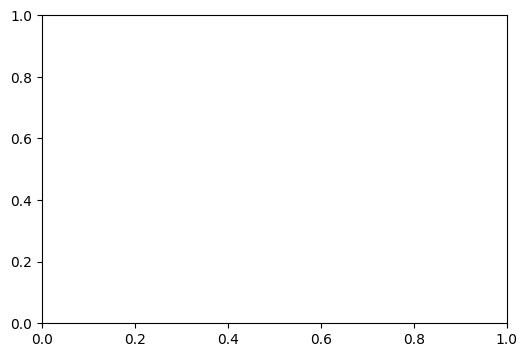

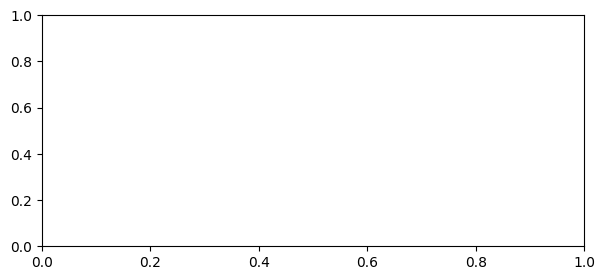

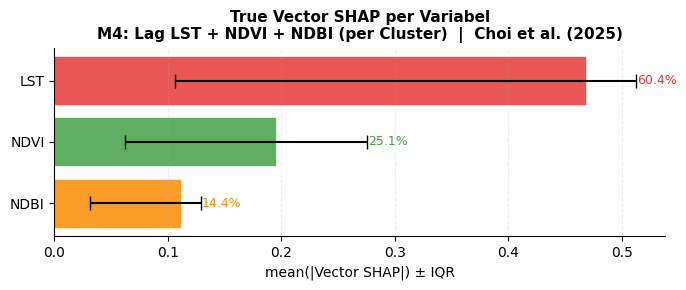


🔬 Membandingkan Φⱼ (True Vector) vs Φ⁰ⱼ (Sum SHAP)...

══════════════════════════════════════════════════════════════════════
  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — M4: Lag LST + NDVI + NDBI (per Cluster)
  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]
══════════════════════════════════════════════════════════════════════
variable  |Φⱼ| mean (True Vector)  |Φ⁰ⱼ| mean (Sum SHAP)  RMSD (Φⱼ vs Φ⁰ⱼ)  RMSD (% of std_y)
     LST                 0.468540               0.544695          0.284947             62.619
    NDVI                 0.194952               0.126701          0.266587             58.585
    NDBI                 0.111708               0.241606          0.197879             43.485

  Rata-rata RMSD: 0.249804
  Jika RMSD kecil → Φⱼ ≈ Φ⁰ⱼ (sesuai temuan jurnal RMSD < 1.16%)
══════════════════════════════════════════════════════════════════════
💾 Disimpan: /content/drive/MyDrive/Data Skripsi/output/regression/phi_vs_phi0_scatter_M4_LagAll_byCluster.png


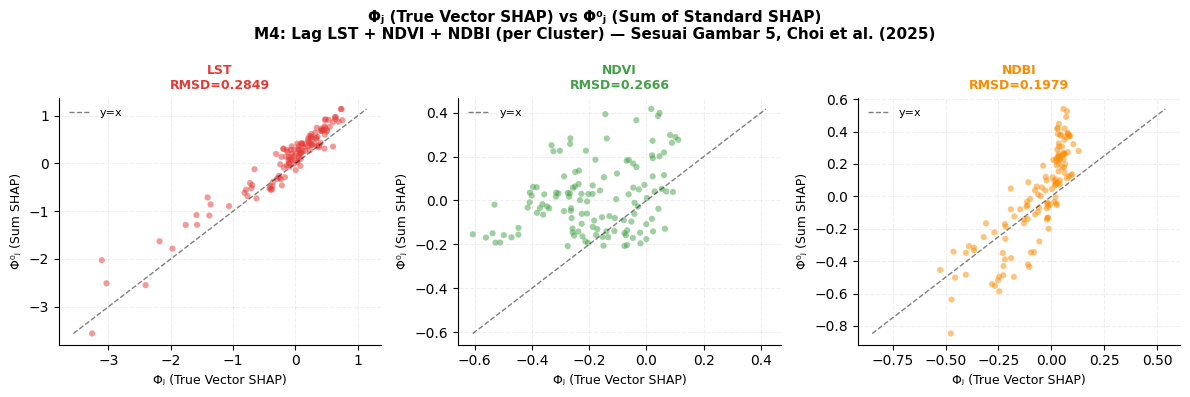


📐 Menghitung True Vector SHAP per Klaster...

  Model: M2: Lag LST (per Cluster)
  ───────────────────────────────────────────────────────
  Klaster 1 (n=26)... ✅ local_acc_error=0.00e+00
  Klaster 2 (n=28)... ✅ local_acc_error=0.00e+00
  Klaster 3 (n=40)... ✅ local_acc_error=0.00e+00
  Klaster 4 (n=34)... ✅ local_acc_error=0.00e+00

  Tabel True Vector SHAP per Klaster — M2: Lag LST (per Cluster):
  ═══════════════════════════════════════════════════════════════════════════
 cluster variable  vector_shap_mean  vector_shap_std  vector_shap_pct  n_samples
       1      LST          0.758267         0.715335            100.0         26
       2      LST          0.599434         0.472985            100.0         28
       3      LST          0.961831         0.783679            100.0         40
       4      LST          1.026143         0.782102            100.0         34
  ═══════════════════════════════════════════════════════════════════════════
  💾 Disimpan: true_vector_shap_clust

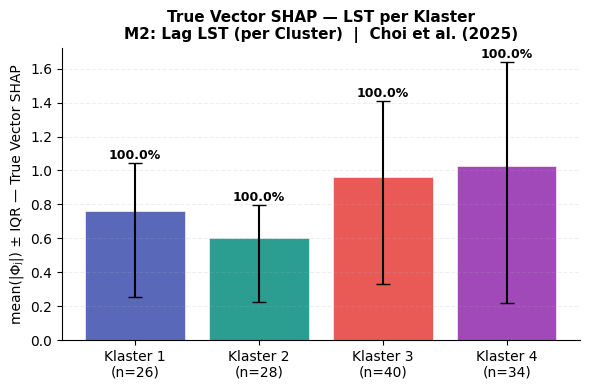


  Model: M4: Lag LST + NDVI + NDBI (per Cluster)
  ───────────────────────────────────────────────────────
  Klaster 1 (n=26)... ✅ local_acc_error=0.00e+00
  Klaster 2 (n=28)... ✅ local_acc_error=0.00e+00
  Klaster 3 (n=40)... ✅ local_acc_error=7.11e-15
  Klaster 4 (n=34)... ✅ local_acc_error=0.00e+00

  Tabel True Vector SHAP per Klaster — M4: Lag LST + NDVI + NDBI (per Cluster):
  ═══════════════════════════════════════════════════════════════════════════
 cluster variable  vector_shap_mean  vector_shap_std  vector_shap_pct  n_samples
       1      LST          0.621241         0.635322            63.45         26
       1     NDVI          0.216613         0.141636            22.12         26
       1     NDBI          0.141210         0.126372            14.42         26
       2      LST          0.336409         0.253313            45.12         28
       2     NDBI          0.276182         0.156169            37.04         28
       2     NDVI          0.133013         0.15690

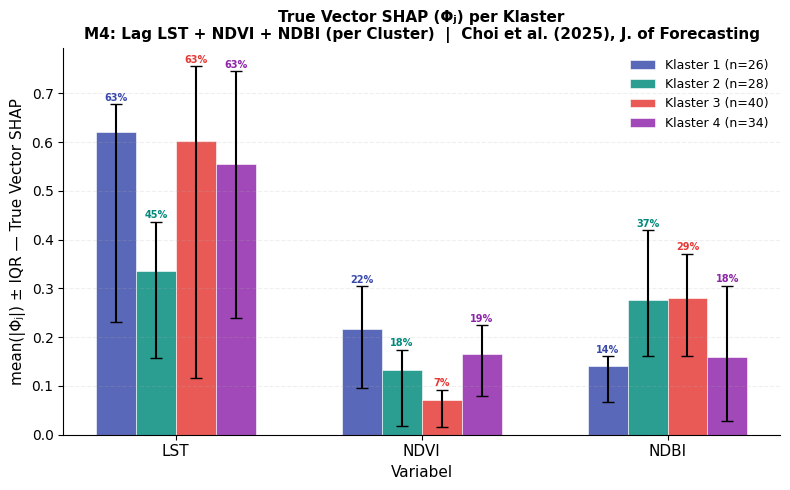


✅ True Vector SHAP (Choi et al., 2025) selesai dihitung!

📋 Output yang dihasilkan:
  true_vector_shap_overall_*.png     → Bar chart Φⱼ keseluruhan
  phi_vs_phi0_scatter_*.png          → Scatter Φⱼ vs Φ⁰ⱼ (validasi jurnal)
  true_vector_shap_cluster_*.csv     → Tabel numerik per klaster
  true_vector_shap_grouped_*.png     → Grouped bar per klaster

📖 Perbedaan implementasi vs kode sebelumnya:
  LAMA : Φ⁰ⱼ = Σ|φl| per variabel   → sum SHAP standar [Persamaan (3)]
  BARU : Φⱼ  = Shapley value Xⱼ     → kernel SHAP di level J [Persamaan (8)]

  Jurnal membuktikan Φⱼ ≈ Φ⁰ⱼ (RMSD < 1.16%) tapi Φⱼ lebih tepat
  secara konseptual karena koalisi antar variabel lebih natural.

📖 Template kutipan skripsi:
  "Interpretasi model dilakukan menggunakan Vector SHAP (Choi et al., 2025)
   yang mengukur kontribusi vektor lag setiap variabel (Φⱼ) terhadap
   prediksi LST 2024. Berbeda dari standard SHAP yang mengukur kontribusi
   setiap lag secara individual, Vector SHAP memperlakukan seluruh riwayat


In [ ]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  IMPLEMENTASI VECTOR SHAP — Choi et al. (2025) [VERSI YANG BENAR]          ║
║  Journal of Forecasting, 44:635–645, DOI: 10.1002/for.3220                 ║
║                                                                              ║
║  PERBEDAAN DARI KODE SEBELUMNYA:                                            ║
║                                                                              ║
║  Kode lama  → mengimplementasikan Φ⁰ⱼ (sum of standard SHAP per variabel) ║
║               = Σ_{l=1}^{pj} φ_{p1+...+pj-1+l}  [Persamaan (3) jurnal]   ║
║                                                                              ║
║  Kode ini   → mengimplementasikan Φⱼ (True Vector SHAP)                   ║
║               = Shapley value dari VEKTOR Xⱼ secara langsung               ║
║               = kernel SHAP dijalankan di level J variabel, bukan M lag    ║
║               [Persamaan (6)-(8) jurnal]                                    ║
║                                                                              ║
║  Kompleksitas: O(2^J + J³) vs O(2^M + M³) untuk standard SHAP             ║
║  Contoh: J=3 variabel, p=5 lag → M=15                                      ║
║          Standard: O(2^15) = 32.768 vs Vector: O(2^3) = 8                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

STRUKTUR DATA PENELITIAN INI:
  Variabel: LST (5 lag: 2009,2012,2015,2018,2021)
            NDVI (6 lag: 2009,2012,2015,2018,2021,2024_baseline)
            NDBI (6 lag: 2009,2012,2015,2018,2021,2024_baseline)
  J = 3 variabel, p ≈ 5-6 lag per variabel
  Target: LST 2024

  Dalam notasi jurnal:
    X1t = (lst_2009, lst_2012, lst_2015, lst_2018, lst_2021)^T  [p1=5]
    X2t = (ndvi_2009, ..., ndvi_2021)^T                          [p2=6]
    X3t = (ndbi_2009, ..., ndbi_2021)^T                          [p3=6]
    ŷt  = f(X1t, X2t, X3t) = prediksi LST 2024
"""

import re
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.special import comb

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# UTILITAS
# ─────────────────────────────────────────────────────────────────────────────

def extract_year(feat_name: str):
    m = re.search(r'(19|20)\d{2}', feat_name)
    return int(m.group()) if m else None

def get_var_type(feat_name: str) -> str:
    fn = feat_name.upper().replace('_', '').replace('-', '')
    for vtype in ['NDBI', 'NDVI', 'LST']:
        if fn.startswith(vtype):
            return vtype
    return 'LAINNYA'

COLOR_VAR = {'LST': '#e53935', 'NDVI': '#43a047',
             'NDBI': '#fb8c00', 'LAINNYA': '#9e9e9e'}

CLUSTER_PALETTE = ['#3949ab', '#00897b', '#e53935', '#8e24aa',
                   '#f57c00', '#0277bd']


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI INTI: TRUE VECTOR KERNEL SHAP
# Implementasi Persamaan (4)-(8) dari Choi et al. (2025)
# ═════════════════════════════════════════════════════════════════════════════

def _shap_kernel_weight(z: np.ndarray, J: int) -> float:
    """
    Kernel weight w(z) dari persamaan (6) jurnal Choi et al. (2025):
        w(z) = (J-1) / [C(J, |z|) * |z| * (J - |z|)]
    Di mana |z| adalah jumlah elemen 1 dalam z.
    Untuk |z|=0 atau |z|=J, w(z)=∞ (constraint penuh).
    """
    s = int(z.sum())
    if s == 0 or s == J:
        return np.inf
    return (J - 1) / (comb(J, s, exact=True) * s * (J - s))


def compute_true_vector_shap(
        model,
        X_test: np.ndarray,
        feature_names: list,
        var_groups: dict,
        background: np.ndarray = None) -> dict:
    """
    Implementasi Vector Kernel SHAP sesuai Choi et al. (2025),
    Persamaan (4)-(8).

    Ide utama (dari jurnal, hal. 636-637):
    - Perlakukan setiap variabel (LST, NDVI, NDBI) sebagai SATU pemain
    - z ∈ {0,1}^J: vektor biner sepanjang jumlah variabel J
    - zⱼ=1: gunakan nilai aktual Xⱼ
    - zⱼ=0: ganti seluruh lag Xⱼ dengan nilai mean (imputasi)
    - Jalankan Kernel SHAP di ruang J dimensi (bukan M dimensi)

    Parameter
    ---------
    model         : model terlatih dengan method .predict()
    X_test        : np.ndarray (n_samples, n_features)
    feature_names : list nama fitur
    var_groups    : dict {nama_variabel: [indeks_kolom]}
                    misal {'LST': [0,1,2,3,4], 'NDVI': [5,6,7,8,9,10]}
    background    : np.ndarray (n_bg, n_features), default=mean X_test

    Returns
    -------
    dict: {
        'phi'     : np.ndarray (n_samples, J) — Vector SHAP values Φⱼ
        'phi0'    : np.ndarray (n_samples,)   — baseline predictions
        'var_names': list nama variabel [J]
        'local_accuracy_check': float — max |Σ Φⱼ - (ŷ - ŷ_baseline)|
    }
    """
    var_names = list(var_groups.keys())
    J = len(var_names)
    n_samples = X_test.shape[0]

    # Background: mean setiap fitur (imputasi untuk zⱼ=0)
    # Sesuai jurnal: x̄ⱼ = mean sample dari lag variabel j [hal. 635]
    if background is None:
        background = X_test.mean(axis=0, keepdims=True)  # (1, M)
    X_mean = background.mean(axis=0)  # (M,) — mean per fitur

    # Prediksi baseline: f(X̄₁, X̄₂, ..., X̄ⱼ) = f(background)
    # Sesuai jurnal persamaan (7): f₀ = f(h(0)) = Φ₀
    phi0 = model.predict(
        np.tile(X_mean, (n_samples, 1))
    ).flatten()  # (n_samples,)

    # Prediksi aktual: f(X₁, X₂, ..., Xⱼ) = ŷ
    y_pred = model.predict(X_test).flatten()  # (n_samples,)

    # ── Kasus khusus J=1: hanya satu variabel ─────────────────────────────
    # Jika J=1 (misal model M2 yang hanya pakai LST), tidak ada koalisi
    # parsial yang mungkin (z_valid = {} karena 0 < sum(z) < 1 mustahil).
    # Dalam kasus ini Φ₁ = ŷ - Φ₀ secara langsung dari local accuracy:
    #   Φ₀ + Φ₁ = ŷ  →  Φ₁ = ŷ - Φ₀
    # Ini adalah solusi analitik eksak untuk J=1.
    if J == 1:
        PHI = (y_pred - phi0).reshape(n_samples, 1)
        local_acc_error = float(np.abs(phi0 + PHI[:, 0] - y_pred).max())
        return {
            'phi'                  : PHI,
            'phi0'                 : phi0,
            'var_names'            : var_names,
            'y_pred'               : y_pred,
            'local_accuracy_error' : local_acc_error,
        }

    # ── J >= 2: Kernel SHAP di level variabel ─────────────────────────────
    # Enumerate semua z ∈ {0,1}^J kecuali 0 dan 1
    # Sesuai jurnal: WLS dijalankan untuk z ∈ {0,1}^J - {0, 1}
    all_z   = list(itertools.product([0, 1], repeat=J))
    z_valid = [z for z in all_z if 0 < sum(z) < J]
    n_z     = len(z_valid)  # = 2^J - 2

    # ── Hitung fz untuk setiap z dan setiap sampel ────────────────────────
    # fz = f(h(z)): prediksi saat variabel dengan zⱼ=0 diganti mean
    # Sesuai jurnal persamaan (4)-(5)
    F_z = np.zeros((n_samples, n_z))  # (n_samples, 2^J - 2)

    for iz, z in enumerate(z_valid):
        X_hz = X_test.copy()
        for j, var_name in enumerate(var_names):
            if z[j] == 0:
                # Ganti semua lag variabel j dengan nilai mean-nya
                # Sesuai jurnal persamaan (4): X̃ⱼ = X̄ⱼ jika zⱼ=0
                col_idxs = var_groups[var_name]
                X_hz[:, col_idxs] = X_mean[col_idxs]
        F_z[:, iz] = model.predict(X_hz).flatten()

    # ── Kernel SHAP via WLS ────────────────────────────────────────────────
    # Sesuai jurnal persamaan (6)-(9):
    # Fit: fz = Φ₀ + Φ₁z₁ + ... + ΦⱼzJ + ez
    # Subject to: Φ₀ = f₀, Φ₀ + ΣΦⱼ = ŷ
    # Solution: Φ = A⁻¹(b - 1·(1ᵀA⁻¹b - f1 + f0)/(1ᵀA⁻¹1))

    # Matriks Z (n_z, J) dan bobot w (n_z,)
    Z = np.array(z_valid, dtype=float)
    w = np.array([_shap_kernel_weight(np.array(z), J) for z in z_valid])

    # A = Σ_{z} z zᵀ w(z) / (2^J - 2)   shape: (J, J)
    # Gunakan (Z * w[:,None]).T @ Z agar selalu menghasilkan array 2D
    Zw  = Z * w[:, np.newaxis]          # (n_z, J)
    A   = (Zw.T @ Z) / n_z             # (J, J)  ← selalu 2D jika J>=2

    # Invers A — gunakan pinv sebagai fallback jika singular
    try:
        A_inv = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        A_inv = np.linalg.pinv(A)

    one       = np.ones(J)              # (J,)
    denom     = float(one @ A_inv @ one)   # skalar: 1ᵀA⁻¹1
    A_inv_one = A_inv @ one            # (J,) — pre-compute

    # Hitung Φ per sampel
    PHI = np.zeros((n_samples, J))

    for s in range(n_samples):
        f0       = float(phi0[s])
        f1       = float(y_pred[s])
        delta_fz = F_z[s, :] - f0                         # (n_z,)
        b        = (Zw.T @ delta_fz) / n_z                # (J,)
        A_inv_b  = A_inv @ b                              # (J,)
        alpha    = (float(one @ A_inv_b) - f1 + f0) / denom
        PHI[s, :] = A_inv_b - alpha * A_inv_one

    # ── Verifikasi Vector Local Accuracy ─────────────────────────────────
    # Properti: Φ₀ + Σⱼ Φⱼ = ŷ   [Proposition 3.2(ii) jurnal]
    reconstructed = phi0 + PHI.sum(axis=1)
    local_acc_error = float(np.abs(reconstructed - y_pred).max())

    return {
        'phi'                  : PHI,        # (n_samples, J) — True Vector SHAP
        'phi0'                 : phi0,        # (n_samples,)
        'var_names'            : var_names,
        'y_pred'               : y_pred,
        'local_accuracy_error' : local_acc_error,
    }


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PENDUKUNG: Ringkasan statistik Vector SHAP
# ═════════════════════════════════════════════════════════════════════════════

def summarize_vector_shap(result: dict, cluster_id=None,
                          n_samples: int = None) -> pd.DataFrame:
    PHI = result['phi']
    var_names = result['var_names']
    abs_phi = np.abs(PHI)

    records = []
    for j, var in enumerate(var_names):
        per_sample = abs_phi[:, j]
        mean_val = float(per_sample.mean())
        q25      = float(np.percentile(per_sample, 25))
        q75      = float(np.percentile(per_sample, 75))
        sem      = float(per_sample.std() / np.sqrt(len(per_sample)))

        records.append({
            'cluster'            : int(cluster_id) if cluster_id is not None else 'All',
            'variable'           : var,
            'vector_shap_mean'   : round(mean_val, 6),
            'vector_shap_std'    : round(float(per_sample.std()), 6),
            'vector_shap_sem'    : round(sem, 6),       # ← BARU: SEM
            'vector_shap_q25'    : round(q25, 6),       # ← BARU: Q25
            'vector_shap_q75'    : round(q75, 6),       # ← BARU: Q75
            'vector_shap_median' : round(float(np.median(per_sample)), 6),
            'vector_shap_pct'    : round(
                float(mean_val / abs_phi.mean(axis=0).sum() * 100), 2),
            'n_samples'          : n_samples if n_samples else len(PHI),
        })

    df = pd.DataFrame(records).sort_values('vector_shap_mean', ascending=False)
    return df.reset_index(drop=True)


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI PERBANDINGAN: Φⱼ vs Φ⁰ⱼ (seperti Tabel 1 di jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def compare_phi_vs_phi0(result_true: dict,
                         shap_values_standard: np.ndarray,
                         feature_names: list,
                         var_groups: dict,
                         model_label: str,
                         save_path=None) -> pd.DataFrame:
    """
    Bandingkan True Vector SHAP (Φⱼ) dengan Sum-of-SHAP (Φ⁰ⱼ).
    Sesuai Remark 2.1 dan Tabel 1 jurnal Choi et al. (2025).

    Jurnal menyatakan keduanya tidak terlalu berbeda (RMSD < 1.16%)
    tapi secara konseptual Φⱼ lebih tepat karena koalisi antar variabel
    lebih natural daripada koalisi antar lag.
    """
    PHI_true = result_true['phi']          # (n_samples, J) — True Vector SHAP
    var_names = result_true['var_names']
    J = len(var_names)

    # Hitung Φ⁰ⱼ: sum SHAP standar per variabel [Persamaan (3) jurnal]
    PHI0 = np.zeros_like(PHI_true)
    for j, var in enumerate(var_names):
        idxs = var_groups[var]
        PHI0[:, j] = shap_values_standard[:, idxs].sum(axis=1)

    # RMSD per variabel [Persamaan di atas Tabel 1 jurnal]
    rmsd_per_var = np.sqrt(((PHI_true - PHI0) ** 2).mean(axis=0))

    records = []
    for j, var in enumerate(var_names):
        records.append({
            'variable'                 : var,
            '|Φⱼ| mean (True Vector)'  : round(float(np.abs(PHI_true[:, j]).mean()), 6),
            '|Φ⁰ⱼ| mean (Sum SHAP)'   : round(float(np.abs(PHI0[:, j]).mean()), 6),
            'RMSD (Φⱼ vs Φ⁰ⱼ)'       : round(float(rmsd_per_var[j]), 6),
            'RMSD (% of std_y)'        : round(
                float(rmsd_per_var[j] / (PHI_true.std() + 1e-9) * 100), 3),
        })

    df_cmp = pd.DataFrame(records)

    print('\n' + '═' * 70)
    print(f'  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — {model_label}')
    print('  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]')
    print('═' * 70)
    print(df_cmp.to_string(index=False))
    print(f'\n  Rata-rata RMSD: {rmsd_per_var.mean():.6f}')
    print('  Jika RMSD kecil → Φⱼ ≈ Φ⁰ⱼ (sesuai temuan jurnal RMSD < 1.16%)')
    print('═' * 70)

    # ── Plot scatter Φⱼ vs Φ⁰ⱼ (seperti Figure 5 jurnal) ───────────────
    fig, axes = plt.subplots(1, J, figsize=(4 * J, 4))
    if J == 1:
        axes = [axes]

    fig.suptitle(
        f'Φⱼ (True Vector SHAP) vs Φ⁰ⱼ (Sum of Standard SHAP)\n'
        f'{model_label} — Sesuai Gambar 5, Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )

    for j, (ax, var) in enumerate(zip(axes, var_names)):
        phi_j  = PHI_true[:, j]
        phi0_j = PHI0[:, j]
        color  = COLOR_VAR.get(var, '#9e9e9e')

        ax.scatter(phi_j, phi0_j, alpha=0.5, s=20, color=color,
                   edgecolors='none')

        # Garis diagonal sempurna
        lims = [min(phi_j.min(), phi0_j.min()),
                max(phi_j.max(), phi0_j.max())]
        ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
        ax.set_xlabel(f'Φⱼ (True Vector SHAP)', fontsize=9)
        ax.set_ylabel(f'Φ⁰ⱼ (Sum SHAP)', fontsize=9)
        ax.set_title(f'{var}\nRMSD={rmsd_per_var[j]:.4f}',
                     fontsize=9, fontweight='bold', color=color)
        ax.legend(fontsize=8, frameon=False)
        ax.grid(alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()

    return df_cmp


# ═════════════════════════════════════════════════════════════════════════════
# FUNGSI VERIFIKASI: Vector Local Accuracy (Proposition 3.2(ii) jurnal)
# ═════════════════════════════════════════════════════════════════════════════

def verify_local_accuracy(result: dict, model_label: str):
    """
    Verifikasi properti Vector Local Accuracy [Proposition 3.2(ii)]:
        Φ₀ + Σⱼ Φⱼ = ŷ   untuk setiap sampel

    Jurnal hal. 638: "Vector local accuracy states that the vector SHAP
    values Φⱼ's of all available Xⱼ's sum to the forecasting ŷ based
    on the available Xⱼ's."
    """
    PHI   = result['phi']    # (n_samples, J)
    phi0  = result['phi0']   # (n_samples,)
    y_hat = result['y_pred'] # (n_samples,)

    reconstructed = phi0 + PHI.sum(axis=1)
    errors = np.abs(reconstructed - y_hat)

    print(f'\n✅ Verifikasi Vector Local Accuracy — {model_label}')
    print(f'   [Proposition 3.2(ii), Choi et al. 2025]')
    print(f'   Max |Φ₀ + ΣΦⱼ - ŷ| = {errors.max():.8f}')
    print(f'   Mean |Φ₀ + ΣΦⱼ - ŷ| = {errors.mean():.8f}')
    if errors.max() < 1e-4:
        print('   → ✅ LULUS: properti vector local accuracy terpenuhi')
    else:
        print('   → ⚠️  Perlu dicek: error melebihi toleransi 1e-4')


# ═════════════════════════════════════════════════════════════════════════════
# PLOT: Bar chart Vector SHAP (sesuai Figure 1 jurnal Choi et al. 2025)
# ═════════════════════════════════════════════════════════════════════════════

def plot_vector_shap_bar(df_summary: pd.DataFrame,
                          model_label: str,
                          cluster_id=None,
                          save_path=None):
    df = df_summary.sort_values('vector_shap_mean', ascending=True)
    colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df['variable']]
    cl_str = f' — Klaster {cluster_id}' if cluster_id is not None else ''

    fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.9)))

    # ✅ FIX: asymmetric xerr berbasis IQR (horizontal bar)
    xerr_low  = (df['vector_shap_mean'] - df['vector_shap_q25']).tolist()
    xerr_high = (df['vector_shap_q75']  - df['vector_shap_mean']).tolist()

    ax.barh(df['variable'], df['vector_shap_mean'],
            xerr=[xerr_low, xerr_high],
            color=colors, alpha=0.85, capsize=5,
            edgecolor='white', linewidth=0.5)

    for i, (_, row) in enumerate(df.iterrows()):
        # ✅ FIX: posisi label pakai q75 - mean (upper error)
        upper_err = row['vector_shap_q75'] - row['vector_shap_mean']
        ax.text(row['vector_shap_mean'] + upper_err + 0.001,
                i, f"{row['vector_shap_pct']:.1f}%",
                va='center', fontsize=9,
                color=COLOR_VAR.get(row['variable'], '#333'))

    ax.set_xlabel('mean(|Vector SHAP|) ± IQR', fontsize=10)
    ax.set_title(
        f'True Vector SHAP per Variabel{cl_str}\n'
        f'{model_label}  |  Choi et al. (2025)',
        fontsize=11, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Disimpan: {save_path}')
    plt.show()
    plt.close()


# ═════════════════════════════════════════════════════════════════════════════
# EKSEKUSI UTAMA: Hitung True Vector SHAP per klaster
# ═════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]')
print('   Persamaan (4)-(8): Kernel SHAP di level J variabel')
print('=' * 70)

# ── Definisikan var_groups: mapping variabel → indeks kolom fitur ─────────
# Ini harus disesuaikan dengan urutan fitur di data Anda

def build_var_groups(feature_names: list) -> dict:
    """
    Bangun var_groups dari nama fitur.
    Returns: {'LST': [0,1,2,...], 'NDVI': [...], 'NDBI': [...]}
    """
    groups = {}
    for i, feat in enumerate(feature_names):
        vtype = get_var_type(feat)
        groups.setdefault(vtype, []).append(i)
    return groups


# ── Ambil model terbaik ───────────────────────────────────────────────────
best_store  = shap_store[(best_cfg_key_rf, 'RF')]
feats_best  = best_store['feats']
X_best      = best_store['X']
model_best  = all_results[(best_cfg_key_rf, 'RF')]['model_obj']
y_test_best = all_results[(best_cfg_key_rf, 'RF')]['y_test']
label_best  = MODEL_CONFIGS[best_cfg_key_rf]['label']

var_groups_best = build_var_groups(feats_best)
print(f'\nVariabel groups yang terdeteksi:')
for var, idxs in var_groups_best.items():
    years = [extract_year(feats_best[i]) for i in idxs]
    print(f'  {var}: {len(idxs)} lag → tahun {years}')

# ── 1. Hitung True Vector SHAP untuk model terbaik (semua data) ───────────
print(f'\n🔢 Menghitung True Vector SHAP (Φⱼ) — model {label_best}...')
print(f'   J={len(var_groups_best)} variabel, '
      f'total lag M={len(feats_best)}')
print(f'   Kompleksitas: O(2^{len(var_groups_best)}) = '
      f'{2**len(var_groups_best)} evaluasi (vs O(2^{len(feats_best)}) standard)')

result_best = compute_true_vector_shap(
    model=model_best,
    X_test=X_best,
    feature_names=feats_best,
    var_groups=var_groups_best,
    background=None   # default: mean X_test
)

# Verifikasi local accuracy [Proposition 3.2(ii)]
verify_local_accuracy(result_best, label_best)

# Ringkasan statistik
df_summary_best = summarize_vector_shap(result_best, n_samples=len(X_best))
print('\n📊 Ringkasan True Vector SHAP:')
print(df_summary_best.to_string(index=False))

# Plot
plot_vector_shap_bar(
    df_summary=df_summary_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'true_vector_shap_overall_{best_cfg_key_rf}.png'
)

# ── 2. Bandingkan Φⱼ vs Φ⁰ⱼ (validasi sesuai jurnal) ────────────────────
print('\n🔬 Membandingkan Φⱼ (True Vector) vs Φ⁰ⱼ (Sum SHAP)...')
sv_best = best_store['sv']  # SHAP values standar (n_samples, M)

df_comparison = compare_phi_vs_phi0(
    result_true=result_best,
    shap_values_standard=sv_best,
    feature_names=feats_best,
    var_groups=var_groups_best,
    model_label=label_best,
    save_path=OUTPUT_DIR + f'phi_vs_phi0_scatter_{best_cfg_key_rf}.png'
)

# ── 3. Hitung True Vector SHAP per klaster ────────────────────────────────
print('\n📐 Menghitung True Vector SHAP per Klaster...')

cluster_cfg_keys = [k for k, v in MODEL_CONFIGS.items()
                    if v['split_by_cluster']]

for cfg_key in cluster_cfg_keys:
    lbl       = MODEL_CONFIGS[cfg_key]['label']
    res       = all_results[(cfg_key, 'RF')]
    feats     = res['features']
    var_groups = build_var_groups(feats)

    print(f'\n  Model: {lbl}')
    print(f'  {"─"*55}')

    # ── Reset list ringkasan untuk setiap model (BUG FIX 1) ───────────────
    model_cluster_summaries = []

    for cl in clusters:
        model_cl = res['cluster_models'][cl]['RF']
        X_cl     = res['cluster_X_test'][cl]

        print(f'  Klaster {int(cl)} (n={len(X_cl)})...', end=' ')

        result_cl = compute_true_vector_shap(
            model=model_cl,
            X_test=X_cl,
            feature_names=feats,
            var_groups=var_groups,
            background=None
        )

        err    = result_cl['local_accuracy_error']
        status = '✅' if err < 1e-4 else '⚠️'
        print(f'{status} local_acc_error={err:.2e}')

        df_cl = summarize_vector_shap(result_cl, cluster_id=cl,
                                       n_samples=len(X_cl))
        model_cluster_summaries.append(df_cl)

    # Gabungkan semua klaster untuk model ini saja
    df_all_cl = pd.concat(model_cluster_summaries, ignore_index=True)

    # Cetak tabel
    print(f'\n  Tabel True Vector SHAP per Klaster — {lbl}:')
    print('  ' + '═' * 75)
    print(df_all_cl[['cluster', 'variable', 'vector_shap_mean',
                      'vector_shap_std', 'vector_shap_pct',
                      'n_samples']].to_string(index=False))
    print('  ' + '═' * 75)

    # Simpan CSV
    df_all_cl.to_csv(
        OUTPUT_DIR + f'true_vector_shap_cluster_{cfg_key}.csv', index=False
    )
    print(f'  💾 Disimpan: true_vector_shap_cluster_{cfg_key}.csv')

    # ── Plot grouped bar per model ─────────────────────────────────────────
    cluster_ids = sorted(df_all_cl['cluster'].unique())

    variables = [v for v in ['LST', 'NDVI', 'NDBI']
                if v in df_all_cl['variable'].unique()]
    n_cl  = len(cluster_ids)
    n_var = len(variables)

    if n_var == 1:
        fig, ax = plt.subplots(figsize=(max(5, n_cl * 1.5), 4))
        # ✅ FIX 1: inisialisasi semua list di sini, termasuk errs_low_all & errs_high_all
        vals_all, errs_low_all, errs_high_all, pcts_all, labels_all, colors_all = [], [], [], [], [], []

        for i, cl in enumerate(cluster_ids):
            row = df_all_cl[
                (df_all_cl['cluster'] == cl) &
                (df_all_cl['variable'] == variables[0])
            ]
            if row.empty:
                continue
            mean_val = float(row['vector_shap_mean'].iloc[0])
            vals_all.append(mean_val)
            # ✅ FIX 2: asymmetric IQR, dijamin non-negatif
            errs_low_all.append(mean_val - float(row['vector_shap_q25'].iloc[0]))
            errs_high_all.append(float(row['vector_shap_q75'].iloc[0]) - mean_val)
            pcts_all.append(float(row['vector_shap_pct'].iloc[0]))
            ns = int(row['n_samples'].iloc[0])
            labels_all.append(f'Klaster {int(cl)}\n(n={ns})')
            colors_all.append(CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)])

        bars = ax.bar(range(len(vals_all)), vals_all,
                      # ✅ FIX 3: pakai [errs_low_all, errs_high_all], bukan errs_all
                      yerr=[errs_low_all, errs_high_all],
                      color=colors_all,
                      alpha=0.83, capsize=5,
                      edgecolor='white', linewidth=0.5)

        for j, (v, el, eh, p) in enumerate(zip(vals_all, errs_low_all, errs_high_all, pcts_all)):
            # ✅ FIX 4: posisi label pakai eh (upper error), bukan errs_all
            ax.text(j, v + eh + 0.005, f'{p:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(range(len(labels_all)))
        ax.set_xticklabels(labels_all, fontsize=10)
        ax.set_ylabel('mean(|Φⱼ|) ± IQR — True Vector SHAP', fontsize=10)
        ax.set_title(
            f'True Vector SHAP — {variables[0]} per Klaster\n'
            f'{lbl}  |  Choi et al. (2025)',
            fontsize=11, fontweight='bold'
        )
        ax.grid(axis='y', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    else:
        x      = np.arange(n_var)
        width  = 0.65 / n_cl
        offset = np.linspace(-(n_cl-1)/2, (n_cl-1)/2, n_cl) * width

        fig, ax = plt.subplots(figsize=(max(8, n_var*2.5), 5))

        for i, cl in enumerate(cluster_ids):
            color = CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)]

            vals, pcts = [], []
            # ✅ FIX 5: inisialisasi errs_low & errs_high di dalam loop cluster
            errs_low, errs_high = [], []
            ns = 0

            for var in variables:
                row = df_all_cl[
                    (df_all_cl['cluster'] == cl) &
                    (df_all_cl['variable'] == var)
                ]
                if row.empty:
                    vals.append(np.nan)
                    errs_low.append(0.0)
                    errs_high.append(0.0)
                    pcts.append(np.nan)
                else:
                    mean_val = float(row['vector_shap_mean'].iloc[0])
                    vals.append(mean_val)
                    # ✅ FIX 6: asymmetric IQR
                    errs_low.append(mean_val - float(row['vector_shap_q25'].iloc[0]))
                    errs_high.append(float(row['vector_shap_q75'].iloc[0]) - mean_val)
                    pcts.append(float(row['vector_shap_pct'].iloc[0]))
                    ns = int(row['n_samples'].iloc[0])

            ax.bar(x + offset[i],
                  [v if not np.isnan(v) else 0 for v in vals],
                  width=width,
                  # ✅ FIX 7: pakai [errs_low, errs_high], bukan [e for e in errs]
                  yerr=[errs_low, errs_high],
                  color=color, alpha=0.83,
                  capsize=4, edgecolor='white', linewidth=0.5,
                  label=f'Klaster {int(cl)} (n={ns})')

            for j, (v, el, eh, p) in enumerate(zip(vals, errs_low, errs_high, pcts)):
                if not np.isnan(v):
                    # ✅ FIX 8: posisi label pakai eh (upper error)
                    ax.text(x[j] + offset[i], v + eh + 0.003,
                            f'{p:.0f}%', ha='center', va='bottom',
                            fontsize=7, color=color, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(variables, fontsize=11)
        ax.set_xlabel('Variabel', fontsize=11)
        ax.set_ylabel('mean(|Φⱼ|) ± IQR — True Vector SHAP', fontsize=11)
        ax.set_title(
            f'True Vector SHAP (Φⱼ) per Klaster\n'
            f'{lbl}  |  Choi et al. (2025), J. of Forecasting',
            fontsize=11, fontweight='bold'
        )
        ax.legend(fontsize=9, frameon=False)
        ax.grid(axis='y', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'true_vector_shap_grouped_{cfg_key}.png',
                dpi=150, bbox_inches='tight')
    print(f'  💾 Plot disimpan: true_vector_shap_grouped_{cfg_key}.png')
    plt.show()
    plt.close()


# ── SELESAI ────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ True Vector SHAP (Choi et al., 2025) selesai dihitung!')
print('=' * 70)
print("""
📋 Output yang dihasilkan:
  true_vector_shap_overall_*.png     → Bar chart Φⱼ keseluruhan
  phi_vs_phi0_scatter_*.png          → Scatter Φⱼ vs Φ⁰ⱼ (validasi jurnal)
  true_vector_shap_cluster_*.csv     → Tabel numerik per klaster
  true_vector_shap_grouped_*.png     → Grouped bar per klaster

📖 Perbedaan implementasi vs kode sebelumnya:
  LAMA : Φ⁰ⱼ = Σ|φl| per variabel   → sum SHAP standar [Persamaan (3)]
  BARU : Φⱼ  = Shapley value Xⱼ     → kernel SHAP di level J [Persamaan (8)]

  Jurnal membuktikan Φⱼ ≈ Φ⁰ⱼ (RMSD < 1.16%) tapi Φⱼ lebih tepat
  secara konseptual karena koalisi antar variabel lebih natural.

📖 Template kutipan skripsi:
  "Interpretasi model dilakukan menggunakan Vector SHAP (Choi et al., 2025)
   yang mengukur kontribusi vektor lag setiap variabel (Φⱼ) terhadap
   prediksi LST 2024. Berbeda dari standard SHAP yang mengukur kontribusi
   setiap lag secara individual, Vector SHAP memperlakukan seluruh riwayat
   historis setiap variabel sebagai satu entitas dalam permainan kooperatif
   Shapley, sehingga menghasilkan interpretasi yang lebih ringkas dan secara
   konseptual lebih tepat untuk data time series multivariat."
""")